# **Komparasi EfficientNetV2-S dan ConvNeXt-Tiny untuk Klasifikasi Suara Pernapasan Normal dan Abnormal pada Dataset ICBHI 2017 Menggunakan Citra Log-Mel Spectrogram**
> task utama: 4 kelas & 2 kelas


# **Load Dataset**

In [ ]:
import os
import glob
from pathlib import Path

import torch
import pandas as pd
import kagglehub

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# 1. Download & setup dataset
download_path = kagglehub.dataset_download("vbookshelf/respiratory-sound-database")
print("Dataset diunduh ke:", download_path)

download_path = Path(download_path)
dataset_path = download_path / "respiratory_sound_database" / "Respiratory_Sound_Database"
audio_dir = dataset_path / "audio_and_txt_files"
meta_file = dataset_path / "patient_diagnosis.csv"

assert dataset_path.exists(), f"Folder dataset tidak ditemukan: {dataset_path}"
assert audio_dir.exists(), f"Folder audio_and_txt_files tidak ditemukan: {audio_dir}"
assert meta_file.exists(), f"File patient_diagnosis.csv tidak ditemukan: {meta_file}"

print("\nStruktur direktori utama:")
for item in sorted(dataset_path.iterdir()):
    print(" -", item.name)

# 2. Load diagnosis pasien
diagnosis_df = pd.read_csv(meta_file, header=None, names=["patient_id", "disease"])
diagnosis_df["patient_id"] = diagnosis_df["patient_id"].astype(int)

print("\nTotal pasien:", len(diagnosis_df))
print("\nDistribusi diagnosis pasien:")
print(diagnosis_df["disease"].value_counts())

# 3. Index file audio dan annotation
wav_paths = sorted(audio_dir.glob("*.wav"))
annotation_paths = sorted(audio_dir.glob("*.txt"))

annotation_map = {p.stem: p for p in annotation_paths}

print("\nTotal file wav:", len(wav_paths))
print("Contoh wav:", [p.name for p in wav_paths[:5]])

missing_annotations = [p.name for p in wav_paths if p.stem not in annotation_map]
print("\nJumlah wav tanpa anotasi txt:", len(missing_annotations))

if missing_annotations:
    print("Contoh wav tanpa anotasi:", missing_annotations[:5])

Device: cuda
Using Colab cache for faster access to the 'respiratory-sound-database' dataset.
Dataset diunduh ke: /kaggle/input/respiratory-sound-database

Struktur direktori utama:
 - audio_and_txt_files
 - filename_differences.txt
 - filename_format.txt
 - patient_diagnosis.csv

Total pasien: 126

Distribusi diagnosis pasien:
disease
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Bronchiolitis      6
Pneumonia          6
LRTI               2
Asthma             1
Name: count, dtype: int64

Total file wav: 920
Contoh wav: ['101_1b1_Al_sc_Meditron.wav', '101_1b1_Pr_sc_Meditron.wav', '102_1b1_Ar_sc_Meditron.wav', '103_2b2_Ar_mc_LittC2SE.wav', '104_1b1_Al_sc_Litt3200.wav']

Jumlah wav tanpa anotasi txt: 0


# **Segmentasi dan Labeling Berdasarkan File Anotasi**
> Ekstraksi data

In [ ]:
import os
import numpy as np
import pandas as pd
import soundfile as sf
import torch
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

def get_label_4class(crackle, wheeze):
    if crackle == 0 and wheeze == 0:
        return 0, "normal"
    elif crackle == 1 and wheeze == 0:
        return 1, "crackle"
    elif crackle == 0 and wheeze == 1:
        return 2, "wheeze"
    else:
        return 3, "both"

def get_label_2class(label_4class):
    return 0 if label_4class == 0 else 1

def parse_annotation(txt_path):
    segments = []
    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 4:
                continue

            start = float(parts[0])
            end = float(parts[1])
            crackle = int(float(parts[2]))
            wheeze = int(float(parts[3]))

            if end <= start:
                continue

            label_4class, label_name = get_label_4class(crackle, wheeze)
            label_2class = get_label_2class(label_4class)

            segments.append({
                "start_sec": start,
                "end_sec": end,
                "annot_duration_sec": end - start,
                "crackle": crackle,
                "wheeze": wheeze,
                "label_name": label_name,
                "label_4class": label_4class,
                "label_2class": label_2class,
            })
    return segments


SEGMENTED_DIR = "segmented_audio_precise"
os.makedirs(SEGMENTED_DIR, exist_ok=True)

MIN_SEC = 0.0
MIN_AMPL = 1e-4
TOL_DUR = 0.25
SAVE_WAV = True

meta_rows = []
silent_tagged = 0
empty_skipped = 0
time_mismatch_warn = 0
txt_missing = 0

diag_map = {}
if "patient_id" in diagnosis_df.columns and "disease" in diagnosis_df.columns:
    diag_map = dict(zip(diagnosis_df["patient_id"].astype(int), diagnosis_df["disease"].astype(str)))

print("Memotong audio sesuai anotasi")

for wav_path in tqdm(wav_paths, ncols=100):
    wav_file = os.path.basename(wav_path)
    stem = os.path.splitext(wav_file)[0]

    # UPDATED: Use annotation_map from previous cell instead of undefined txt_paths
    txt_path = annotation_map.get(stem, None)
    if txt_path is None or (not os.path.exists(txt_path)):
        txt_missing += 1
        continue

    segments = parse_annotation(txt_path)
    if len(segments) == 0:
        continue

    y, sr = sf.read(wav_path, always_2d=False)
    if isinstance(y, np.ndarray) and y.ndim > 1:
        y = y.mean(axis=1)
    y = y.astype(np.float32, copy=False)

    dur_audio = len(y) / float(sr)
    max_end = max(seg["end_sec"] for seg in segments)

    if abs(dur_audio - max_end) > TOL_DUR:
        time_mismatch_warn += 1
        if time_mismatch_warn <= 10:
            print(f"[PERINGATAN] {wav_file}: durasi audio {dur_audio:.3f}s vs max anotasi {max_end:.3f}s")

    patient_id_str = stem.split("_")[0]
    try:
        patient_id = int(patient_id_str)
    except ValueError:
        patient_id = -1

    disease = diag_map.get(patient_id, "") if patient_id != -1 else ""

    for i, seg in enumerate(segments):
        start = seg["start_sec"]
        end = seg["end_sec"]

        start_samp_raw = int(np.floor(start * sr))
        end_samp_raw = int(np.ceil(end * sr))

        start_samp = max(0, min(start_samp_raw, len(y)))
        end_samp = max(0, min(end_samp_raw, len(y)))

        was_clipped = int((start_samp != start_samp_raw) or (end_samp != end_samp_raw))

        if end_samp <= start_samp:
            empty_skipped += 1
            continue

        segment = y[start_samp:end_samp]

        if MIN_SEC > 0.0:
            min_len = int(MIN_SEC * sr)
            if len(segment) < min_len:
                segment = np.pad(segment, (0, min_len - len(segment)), mode="constant")

        max_amp = float(np.max(np.abs(segment))) if segment.size > 0 else 0.0
        is_silent = int(max_amp < MIN_AMPL)
        if is_silent:
            silent_tagged += 1

        cycle_id = f"{stem}_seg{i}"
        out_path = ""

        if SAVE_WAV:
            label_dir = os.path.join(SEGMENTED_DIR, seg["label_name"])
            os.makedirs(label_dir, exist_ok=True)
            out_path = os.path.join(label_dir, f"{cycle_id}.wav")
            sf.write(out_path, segment, sr)

        meta_rows.append({
            "cycle_id": cycle_id,
            "recording_id": stem,
            "wav_source": wav_path,
            "txt_source": txt_path,
            "file": out_path,
            "patient_id": patient_id,
            "disease": disease,
            "start_sec": float(start),
            "end_sec": float(end),
            "annot_duration_sec": float(seg["annot_duration_sec"]),
            "duration_sec": float(len(segment) / sr),
            "crackle": int(seg["crackle"]),
            "wheeze": int(seg["wheeze"]),
            "label_name": seg["label_name"],
            "label_4class": int(seg["label_4class"]),
            "label_2class": int(seg["label_2class"]),
            "sr_raw": int(sr),
            "max_amp": max_amp,
            "is_silent": is_silent,
            "was_clipped": was_clipped,
            "source": "original"
        })

meta_segments = pd.DataFrame(meta_rows)
meta_csv_path = os.path.join(SEGMENTED_DIR, "metadata_segments_precise.csv")
meta_segments.to_csv(meta_csv_path, index=False)

print("\nTotal segmen:", len(meta_segments))
print("Total silent tagged:", silent_tagged)

if len(meta_segments) > 0:
    print("\nDistribusi 4 kelas:")
    print(meta_segments["label_name"].value_counts())

    print("\nDistribusi 2 kelas:")
    print(meta_segments["label_2class"].value_counts())

print("\nRingkasan:")
print("Wav tanpa anotasi txt:", txt_missing)
print("Segmen kosong:", empty_skipped)
print("Mismatch durasi:", time_mismatch_warn)
print("\nMetadata tersimpan di:", meta_csv_path)

Memotong audio sesuai anotasi


  2%|█                                                             | 15/920 [00:01<01:27, 10.32it/s]

[PERINGATAN] 107_2b3_Al_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s
[PERINGATAN] 107_2b3_Ar_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s


  2%|█▏                                                            | 17/920 [00:01<01:30, 10.02it/s]

[PERINGATAN] 107_2b3_Ll_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s
[PERINGATAN] 107_2b3_Lr_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s


...

[PERINGATAN] 107_2b3_Tc_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.101s
[PERINGATAN] 107_2b4_Al_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.542s
[PERINGATAN] 107_2b4_Ar_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.542s


  2%|█▌                                                            | 23/920 [00:02<01:24, 10.57it/s]

[PERINGATAN] 107_2b4_Ll_mc_AKGC417L.wav: durasi audio 20.000s vs max anotasi 19.542s


100%|█████████████████████████████████████████████████████████████| 920/920 [01:19<00:00, 11.60it/s]



Total segmen: 6898
Total silent tagged: 0

Distribusi 4 kelas:
label_name
normal     3642
crackle    1864
wheeze      886
both        506
Name: count, dtype: int64

Distribusi 2 kelas:
label_2class
0    3642
1    3256
Name: count, dtype: int64

Ringkasan:
Wav tanpa anotasi txt: 0
Segmen kosong: 0
Mismatch durasi: 394

Metadata tersimpan di: segmented_audio_precise/metadata_segments_precise.csv


# **Distribusi Data Hasil Segmentasi dan labeling**

Jumlah total segmen: 6898
Jumlah pasien unik : 126

Distribusi 4 kelas:
label_name
normal     3642
crackle    1864
wheeze      886
both        506
Name: count, dtype: int64

Distribusi 2 kelas:
label_2class
normal      3642
abnormal    3256
Name: count, dtype: int64

Distribusi silent:
is_silent
non_silent    6898
Name: count, dtype: int64

Statistik durasi segmen:
count    6898.000000
mean        2.700537
std         1.172530
min         0.200023
25%         1.932018
50%         2.537029
75%         3.369025
max        16.163000
Name: duration_sec, dtype: float64


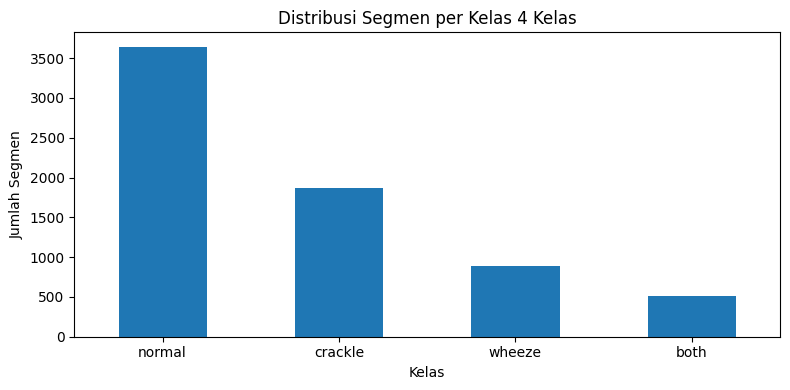

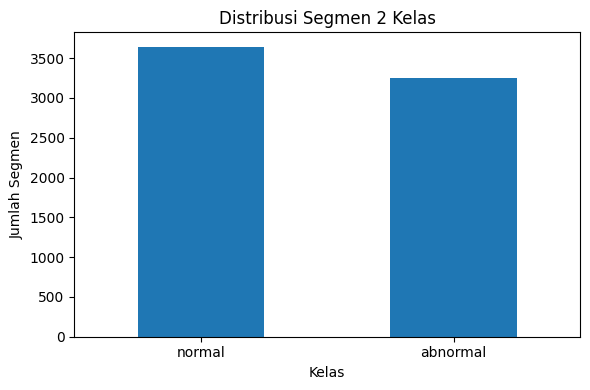

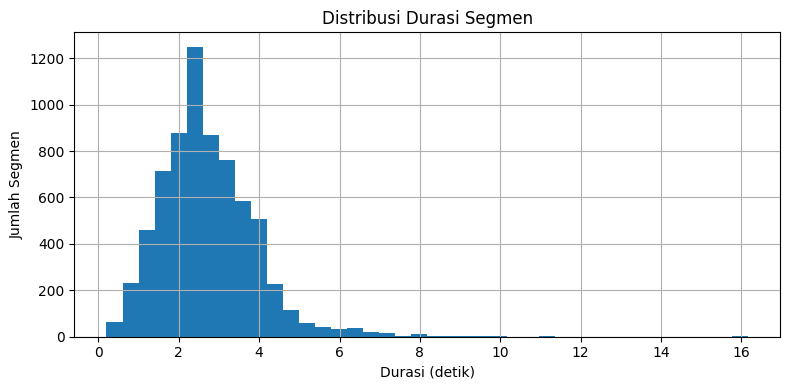

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

SEGMENTED_DIR = "segmented_audio_precise"
META_PATH = os.path.join(SEGMENTED_DIR, "metadata_segments_precise.csv")

meta = pd.read_csv(META_PATH)

print("Jumlah total segmen:", len(meta))
print("Jumlah pasien unik :", meta["patient_id"].nunique())

# Tentukan kolom label yang dipakai
label_col = "label_name" if "label_name" in meta.columns else "sound"

print("\nDistribusi 4 kelas:")
print(meta[label_col].value_counts())

if "label_2class" in meta.columns:
    print("\nDistribusi 2 kelas:")
    print(meta["label_2class"].map({0: "normal", 1: "abnormal"}).value_counts())

if "is_silent" in meta.columns:
    print("\nDistribusi silent:")
    print(meta["is_silent"].map({0: "non_silent", 1: "silent"}).value_counts())

print("\nStatistik durasi segmen:")
print(meta["duration_sec"].describe())

# Plot distribusi 4 kelas
plt.figure(figsize=(8, 4))
meta[label_col].value_counts().reindex(["normal", "crackle", "wheeze", "both"]).plot(kind="bar")
plt.title("Distribusi Segmen per Kelas 4 Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Segmen")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot distribusi 2 kelas
if "label_2class" in meta.columns:
    plt.figure(figsize=(6, 4))
    meta["label_2class"].map({0: "normal", 1: "abnormal"}).value_counts().reindex(["normal", "abnormal"]).plot(kind="bar")
    plt.title("Distribusi Segmen 2 Kelas")
    plt.xlabel("Kelas")
    plt.ylabel("Jumlah Segmen")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Histogram durasi
plt.figure(figsize=(8, 4))
meta["duration_sec"].hist(bins=40)
plt.title("Distribusi Durasi Segmen")
plt.xlabel("Durasi (detik)")
plt.ylabel("Jumlah Segmen")
plt.tight_layout()
plt.show()


CONTOH KELAS: NORMAL
Sumber      : segmented_audio_precise/normal/120_1b1_Ar_sc_Meditron_seg6.wav
Mode        : segment_file
Cycle ID    : 120_1b1_Ar_sc_Meditron_seg6
Kelas       : normal
Patient ID  : 120
Waktu segmen: 16.698s - 19.734s
SR          : 4000
Durasi      : 3.036 detik
Max amp     : 0.781921


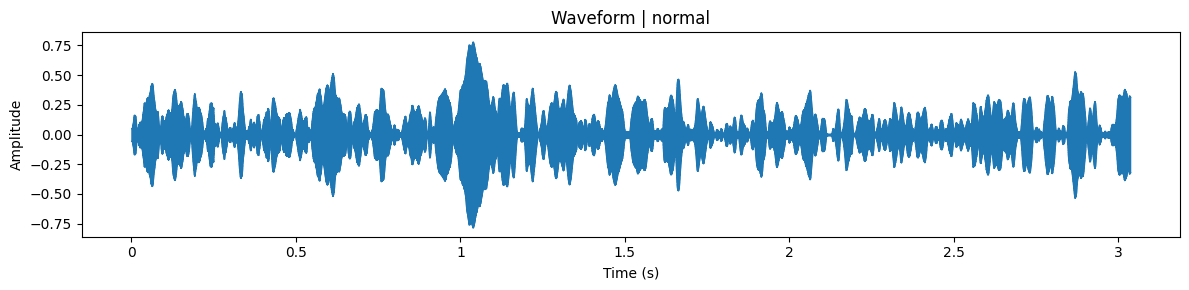

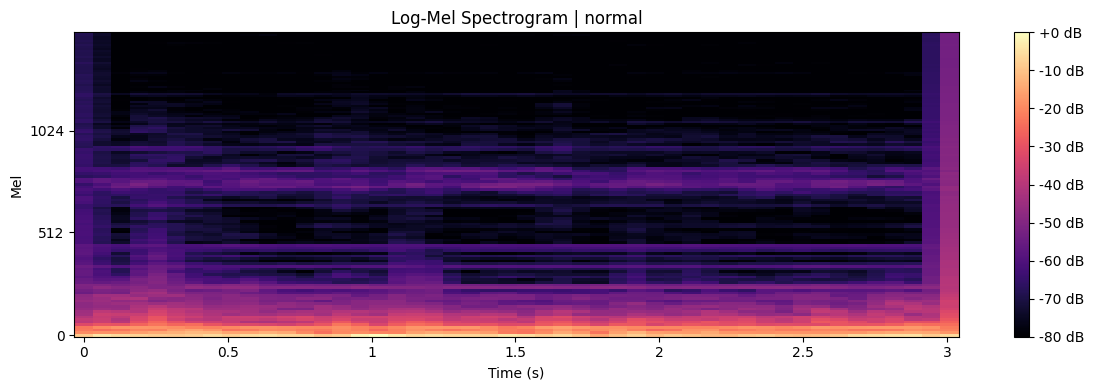


CONTOH KELAS: CRACKLE
Sumber      : segmented_audio_precise/crackle/130_2b2_Ar_mc_AKGC417L_seg2.wav
Mode        : segment_file
Cycle ID    : 130_2b2_Ar_mc_AKGC417L_seg2
Kelas       : crackle
Patient ID  : 130
Waktu segmen: 4.933s - 7.466s
SR          : 44100
Durasi      : 2.533 detik
Max amp     : 0.501038


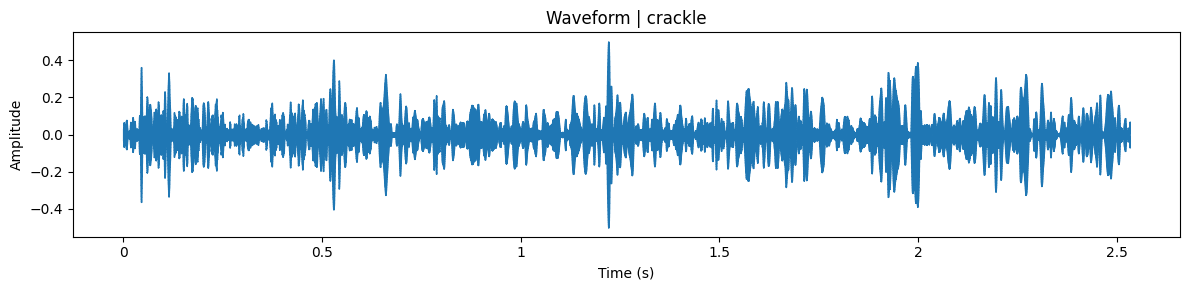

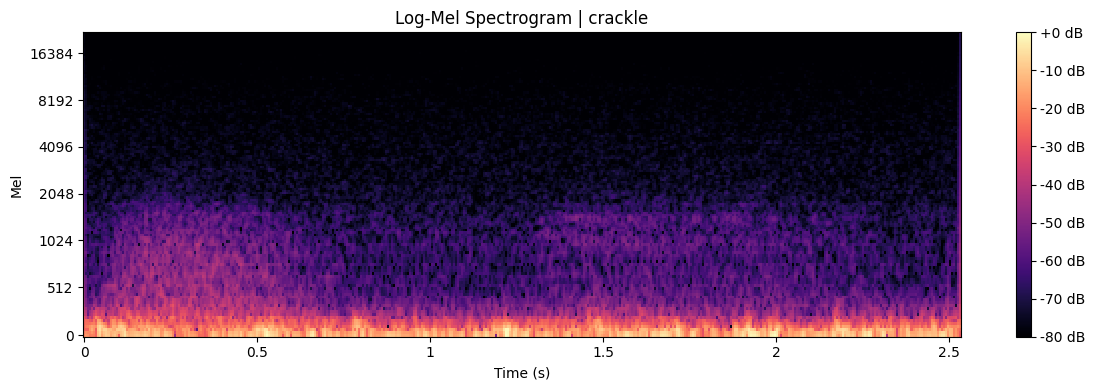


CONTOH KELAS: WHEEZE
Sumber      : segmented_audio_precise/wheeze/112_1p1_Ll_sc_Litt3200_seg3.wav
Mode        : segment_file
Cycle ID    : 112_1p1_Ll_sc_Litt3200_seg3
Kelas       : wheeze
Patient ID  : 112
Waktu segmen: 11.015s - 14.557s
SR          : 4000
Durasi      : 3.542 detik
Max amp     : 0.209106


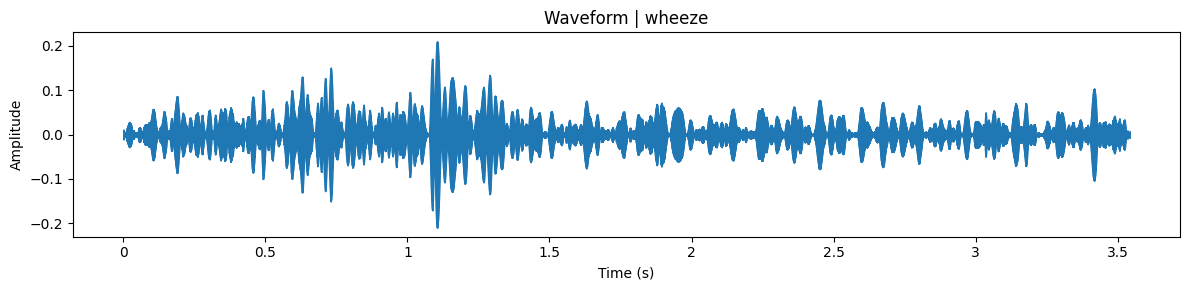

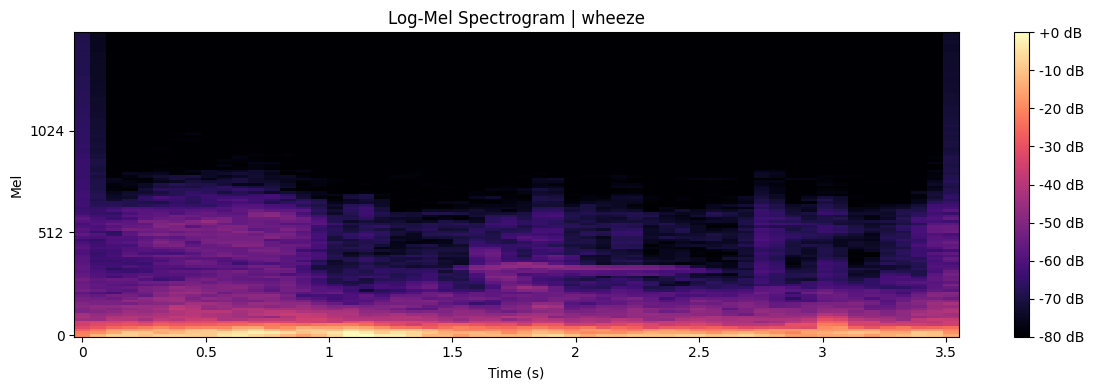


CONTOH KELAS: BOTH
Sumber      : segmented_audio_precise/both/151_3p2_Pr_mc_AKGC417L_seg0.wav
Mode        : segment_file
Cycle ID    : 151_3p2_Pr_mc_AKGC417L_seg0
Kelas       : both
Patient ID  : 151
Waktu segmen: 0.059s - 3.514s
SR          : 44100
Durasi      : 3.455 detik
Max amp     : 1.000000


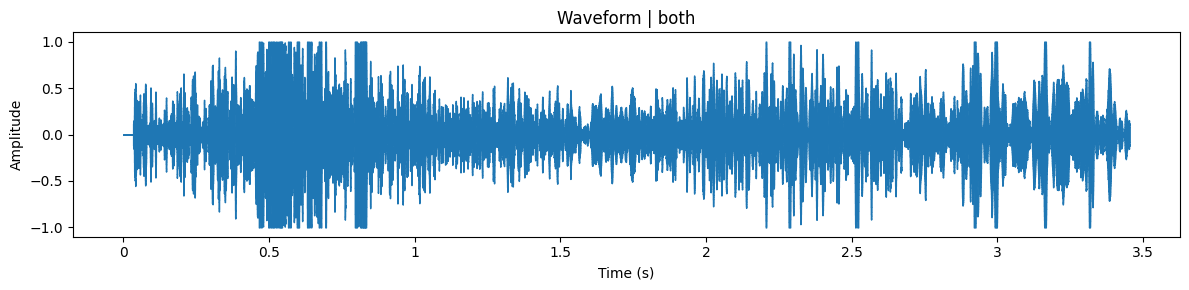

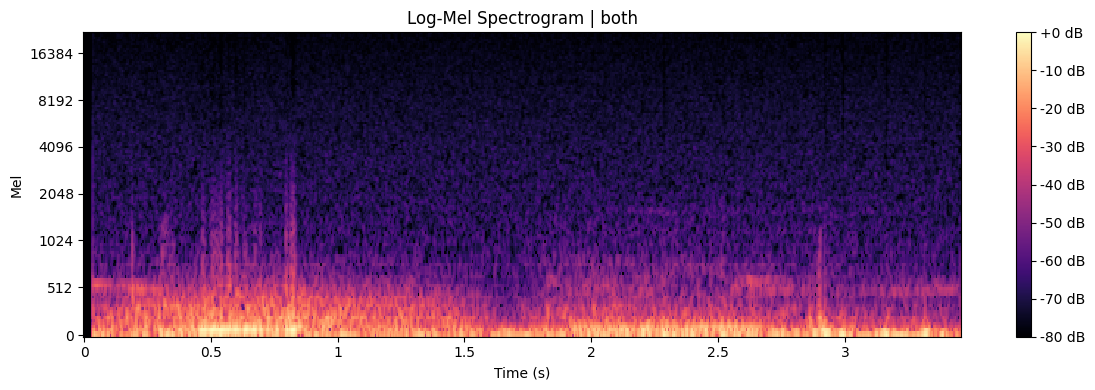

In [ ]:
import os
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# =========================
# Konfigurasi
# =========================
classes = ["normal", "crackle", "wheeze", "both"]
label_col = "label_name" if "label_name" in meta.columns else "sound"

# =========================
# Helper: load segmen dari metadata row
# Prioritas:
# 1) load dari file segmen hasil simpan
# 2) fallback slice langsung dari wav_source
# =========================
def load_segment_from_row(row):
    seg_path = str(row.get("file", ""))
    if seg_path and seg_path != "nan" and os.path.exists(seg_path):
        y, sr = librosa.load(seg_path, sr=None, mono=True)
        return y.astype(np.float32), sr, seg_path, "segment_file"

    wav_source = str(row.get("wav_source", ""))
    if (not wav_source) or wav_source == "nan" or (not os.path.exists(wav_source)):
        raise FileNotFoundError(f"wav_source tidak ditemukan: {wav_source}")

    start = float(row.get("start_sec", 0.0))
    end = float(row.get("end_sec", 0.0))
    if end <= start:
        raise ValueError(f"start/end tidak valid: start={start}, end={end}")

    y_full, sr = sf.read(wav_source, always_2d=False)
    if isinstance(y_full, np.ndarray) and y_full.ndim > 1:
        y_full = y_full.mean(axis=1)
    y_full = y_full.astype(np.float32, copy=False)

    start_samp = int(np.floor(start * sr))
    end_samp = int(np.ceil(end * sr))
    start_samp = max(0, min(start_samp, len(y_full)))
    end_samp = max(0, min(end_samp, len(y_full)))

    if end_samp <= start_samp:
        raise ValueError("Segment kosong setelah clamp indeks sample")

    y = y_full[start_samp:end_samp]
    return y, sr, wav_source, "sliced_from_raw"

# =========================
# Helper: tampilkan audio + waveform + log-mel
# =========================
def show_example_from_row(row, n_mels=128, n_fft=2048, hop_length=160, fmax=8000):
    label = row.get(label_col, "")
    patient_id = row.get("patient_id", "")
    cycle_id = row.get("cycle_id", "")
    start = row.get("start_sec", None)
    end = row.get("end_sec", None)

    try:
        y, sr, src, mode = load_segment_from_row(row)
    except Exception as e:
        print("[ERROR] gagal load segmen:", e)
        return

    dur = len(y) / sr if sr else 0.0
    max_amp = float(np.max(np.abs(y))) if len(y) > 0 else 0.0

    print(f"Sumber      : {src}")
    print(f"Mode        : {mode}")
    print(f"Cycle ID    : {cycle_id}")
    print(f"Kelas       : {label}")
    print(f"Patient ID  : {patient_id}")
    if start is not None and end is not None:
        print(f"Waktu segmen: {float(start):.3f}s - {float(end):.3f}s")
    print(f"SR          : {sr}")
    print(f"Durasi      : {dur:.3f} detik")
    print(f"Max amp     : {max_amp:.6f}")

    # Audio preview
    if len(y) == 0 or max_amp == 0:
        print("[INFO] sinyal kosong atau sangat lemah.")
    display(Audio(y, rate=sr, normalize=False))

    # Waveform
    plt.figure(figsize=(12, 3))
    if len(y) > 0:
        librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform | {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

    # Log-Mel Spectrogram
    if len(y) > 0:
        S = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            fmax=fmax,
            power=2.0
        )
        S_db = librosa.power_to_db(S + 1e-10, ref=np.max)
    else:
        S_db = np.zeros((n_mels, 1), dtype=np.float32)

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        S_db,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis="mel",
        fmax=fmax
    )
    plt.title(f"Log-Mel Spectrogram | {label}")
    plt.xlabel("Time (s)")
    plt.ylabel("Mel")
    plt.colorbar(format="%+2.0f dB")
    plt.tight_layout()
    plt.show()

# =========================
# Ambil 1 sampel per kelas
# Prioritas non-silent jika kolom tersedia
# =========================
for cls in classes:
    subset = meta[meta[label_col] == cls].copy()

    if len(subset) == 0:
        print(f"\nKelas '{cls}' tidak ditemukan di metadata.")
        continue

    if "is_silent" in subset.columns:
        non_silent_subset = subset[subset["is_silent"] == 0]
        if len(non_silent_subset) > 0:
            subset = non_silent_subset

    row = subset.sample(1, random_state=42).iloc[0]

    print("\n" + "=" * 90)
    print(f"CONTOH KELAS: {cls.upper()}")
    print("=" * 90)
    show_example_from_row(row, n_mels=128, n_fft=1024, hop_length=256, fmax=None)

# **Metadata 4 & 2 Kelas**

In [ ]:
import os
import pandas as pd

# =========================
# INPUT
# =========================
SEGMENTED_DIR = "segmented_audio_precise"
META_FILE = os.path.join(SEGMENTED_DIR, "metadata_segments_precise.csv")

assert os.path.exists(META_FILE), f"Metadata tidak ditemukan: {META_FILE}"

# =========================
# OUTPUT
# project baru 4 kelas + binary paralel
# =========================
OUT_DIR = "metadata_4class"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_PATH = os.path.join(OUT_DIR, "metadata_segments_4class_with_binary.csv")

# =========================
# LOAD METADATA
# =========================
meta = pd.read_csv(META_FILE).copy()

print("Memuat metadata dari:", META_FILE)
print("Total baris:", len(meta))

# =========================
# CEK KOLOM LABEL ASLI
# =========================
label_col = "label_name" if "label_name" in meta.columns else "sound"
assert label_col in meta.columns, "Kolom label tidak ditemukan. Harus ada 'label_name' atau 'sound'."

meta[label_col] = meta[label_col].astype(str).str.strip().str.lower()

print("\nDistribusi label awal:")
print(meta[label_col].value_counts())

# =========================
# FILTER LABEL VALID 4 KELAS
# =========================
valid_labels = ["normal", "crackle", "wheeze", "both"]
meta = meta[meta[label_col].isin(valid_labels)].reset_index(drop=True)

print("\nTotal baris setelah filter label valid:", len(meta))

# =========================
# BENTUK LABEL 4 KELAS
# =========================
# simpan nama 4 kelas standar
meta["label_name_4class"] = meta[label_col]

label4_to_idx = {
    "normal": 0,
    "crackle": 1,
    "wheeze": 2,
    "both": 3
}
meta["label_4class"] = meta["label_name_4class"].map(label4_to_idx).astype(int)

# =========================
# BENTUK LABEL 2 KELAS PARALEL
# =========================
meta["label_2class"] = meta["label_name_4class"].apply(lambda x: 0 if x == "normal" else 1).astype(int)
meta["label_name_2class"] = meta["label_2class"].map({0: "normal", 1: "abnormal"})

# =========================
# VALIDASI KOLOM DASAR
# =========================
required_cols = ["wav_source", "start_sec", "end_sec"]
missing_cols = [c for c in required_cols if c not in meta.columns]
if missing_cols:
    raise AssertionError(f"Kolom wajib tidak ada di metadata: {missing_cols}")

if "patient_id" in meta.columns:
    meta["patient_id"] = pd.to_numeric(meta["patient_id"], errors="coerce").fillna(-1).astype(int)

# optional cycle_id
if "cycle_id" not in meta.columns:
    meta["cycle_id"] = [f"cycle_{i}" for i in range(len(meta))]

# optional split placeholder
if "split" not in meta.columns:
    meta["split"] = "unsplit"

# =========================
# RINGKASAN
# =========================
print("\nDistribusi label 4 kelas:")
print(meta["label_name_4class"].value_counts())

print("\nDistribusi label 2 kelas:")
print(meta["label_name_2class"].value_counts())

if "patient_id" in meta.columns:
    print("\nDistribusi pasien unik per 2 kelas:")
    patient_bin = (
        meta.groupby("patient_id")["label_2class"]
        .agg(lambda x: 1 if (x == 1).any() else 0)
        .map({0: "normal", 1: "abnormal"})
    )
    print(patient_bin.value_counts())

    print("\nDistribusi pasien unik per 4 kelas dominan:")
    # ambil label pasien dominan berdasar prioritas:
    # both > wheeze > crackle > normal
    priority_map = {"normal": 0, "crackle": 1, "wheeze": 2, "both": 3}

    def patient_main_4class(x):
        labels = list(x.astype(str))
        labels_sorted = sorted(labels, key=lambda z: priority_map[z], reverse=True)
        return labels_sorted[0]

    patient_4class = (
        meta.groupby("patient_id")["label_name_4class"]
        .agg(patient_main_4class)
    )
    print(patient_4class.value_counts())

# =========================
# URUTAN KOLOM AGAR RAPI
# =========================
priority_cols = [
    "patient_id",
    "cycle_id",
    "wav_source",
    "start_sec",
    "end_sec",
    "label_4class",
    "label_name_4class",
    "label_2class",
    "label_name_2class",
    "split"
]

existing_priority_cols = [c for c in priority_cols if c in meta.columns]
other_cols = [c for c in meta.columns if c not in existing_priority_cols]
meta = meta[existing_priority_cols + other_cols]

# =========================
# SIMPAN
# =========================
meta.to_csv(OUT_PATH, index=False)

print("\nMetadata 4 kelas + 2 kelas paralel disimpan di:")
print(OUT_PATH)

Memuat metadata dari: segmented_audio_precise/metadata_segments_precise.csv
Total baris: 6898

Distribusi label awal:
label_name
normal     3642
crackle    1864
wheeze      886
both        506
Name: count, dtype: int64

Total baris setelah filter label valid: 6898

Distribusi label 4 kelas:
label_name_4class
normal     3642
crackle    1864
wheeze      886
both        506
Name: count, dtype: int64

Distribusi label 2 kelas:
label_name_2class
normal      3642
abnormal    3256
Name: count, dtype: int64

Distribusi pasien unik per 2 kelas:
label_2class
abnormal    92
normal      34
Name: count, dtype: int64

Distribusi pasien unik per 4 kelas dominan:
label_name_4class
both       35
normal     34
wheeze     29
crackle    28
Name: count, dtype: int64

Metadata 4 kelas + 2 kelas paralel disimpan di:
metadata_4class/metadata_segments_4class_with_binary.csv


# **Splitting Data**
> **60:40**

In [ ]:
# =============================================================================
# CELL 12 - SUBJECT-INDEPENDENT TRAIN/VAL/TEST SPLIT ICBHI 2017
# =============================================================================
import os
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

# ============================================================
# KONFIGURASI
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

SPLIT_RATIO = "60:40"
# Pilihan: "60:40" atau "80:20"

RANDOM_STATE = 42
VAL_RATIO_FROM_TRAIN = 0.20

CLASS_4_NAMES = ["normal", "crackle", "wheeze", "both"]
CLASS_4_INDEX = [0, 1, 2, 3]

assert SPLIT_RATIO in ("60:40", "80:20"), \
    "SPLIT_RATIO harus '60:40' atau '80:20'"

assert 0.0 < VAL_RATIO_FROM_TRAIN < 1.0, \
    "VAL_RATIO_FROM_TRAIN harus di antara 0 dan 1"

OUTER_TRAIN_R, TEST_R = (0.60, 0.40) if SPLIT_RATIO == "60:40" else (0.80, 0.20)
INNER_TRAIN_R = 1.0 - VAL_RATIO_FROM_TRAIN

HAS_VAL = True

META_4CLASS_DIR = "metadata_4class"
META_FILE = os.path.join(META_4CLASS_DIR, "metadata_segments_4class_with_binary.csv")
OUT_DIR = f"metadata_icbhi_subject_independent_{SPLIT_RATIO.replace(':', '_')}_val20"
os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 72)
print(f"  ICBHI 2017 | SUBJECT-INDEPENDENT SPLIT {SPLIT_RATIO} + VAL 20% OF TRAIN")
print("=" * 72)
print(f"  Outer train pool : {OUTER_TRAIN_R*100:.0f}%")
print(f"  Outer test       : {TEST_R*100:.0f}%")
print(f"  Inner train      : {INNER_TRAIN_R*100:.0f}% dari train pool")
print(f"  Inner val        : {VAL_RATIO_FROM_TRAIN*100:.0f}% dari train pool")
print(f"  Random state     : {RANDOM_STATE}")
print(f"  Output dir       : {OUT_DIR}/")
print("=" * 72)

# =========================
# 1. LOAD METADATA
# =========================
assert os.path.exists(META_FILE), f"Metadata tidak ditemukan: {META_FILE}"
meta = pd.read_csv(META_FILE).copy()

required_cols = [
    "patient_id",
    "label_4class",
    "label_name_4class",
    "label_2class",
    "label_name_2class",
    "wav_source",
    "start_sec",
    "end_sec",
]
missing = [c for c in required_cols if c not in meta.columns]
if missing:
    raise AssertionError(f"Kolom wajib tidak ada: {missing}")

meta["patient_id"] = meta["patient_id"].astype(int)
meta["label_4class"] = meta["label_4class"].astype(int)
meta["label_2class"] = meta["label_2class"].astype(int)
meta["label_name_4class"] = meta["label_name_4class"].astype(str).str.strip().str.lower()
meta["label_name_2class"] = meta["label_name_2class"].astype(str).str.strip().str.lower()

meta = meta[meta["patient_id"] != -1].reset_index(drop=True)
meta["row_uid"] = np.arange(len(meta), dtype=int)

N_TOTAL = len(meta)
N_PAT_TOTAL = meta["patient_id"].nunique()

print(f"\nTotal segmen : {N_TOTAL}")
print(f"Total pasien : {N_PAT_TOTAL}")

print(f"\nDistribusi 4 kelas segmen:")
print(meta["label_name_4class"].value_counts().reindex(CLASS_4_NAMES, fill_value=0))

print(f"\nDistribusi 2 kelas segmen:")
print(meta["label_name_2class"].value_counts().reindex(["normal", "abnormal"], fill_value=0))

# =========================
# 2. TABEL PASIEN UNTUK STRATIFY
# =========================
def dominant_label(series):
    s = pd.Series(series)
    mode_vals = s.mode()
    if len(mode_vals) > 0:
        return int(mode_vals.iloc[0])
    return int(s.iloc[0])

patient_tbl = (
    meta.groupby("patient_id")
    .agg(
        dominant_label_4class=("label_4class", dominant_label),
        dominant_label_2class=("label_2class", dominant_label),
        n_segments=("label_4class", "size"),
    )
    .reset_index()
)

def choose_stratify_info(ptbl: pd.DataFrame):
    vc4 = ptbl["dominant_label_4class"].value_counts()
    if len(vc4) >= 2 and vc4.min() >= 2:
        return ptbl["dominant_label_4class"].values, "dominant_label_4class"

    vc2 = ptbl["dominant_label_2class"].value_counts()
    if len(vc2) >= 2 and vc2.min() >= 2:
        return ptbl["dominant_label_2class"].values, "dominant_label_2class"

    return None, "none"

pat_ids = patient_tbl["patient_id"].values
outer_stratify_labels, outer_stratify_name = choose_stratify_info(patient_tbl)

print(f"\nOuter stratify berdasarkan: {outer_stratify_name}")
if outer_stratify_name == "dominant_label_4class":
    print(
        patient_tbl["dominant_label_4class"]
        .map(dict(enumerate(CLASS_4_NAMES)))
        .value_counts()
        .reindex(CLASS_4_NAMES, fill_value=0)
    )
elif outer_stratify_name == "dominant_label_2class":
    print(
        patient_tbl["dominant_label_2class"]
        .map({0: "normal", 1: "abnormal"})
        .value_counts()
        .reindex(["normal", "abnormal"], fill_value=0)
    )
else:
    print("  [INFO] Stratify dimatikan karena distribusi pasien terlalu kecil/tidak aman.")

# =========================
# 3. SPLIT OUTER TRAIN_POOL : TEST
# =========================
train_pool_pat, test_pat = train_test_split(
    pat_ids,
    train_size=OUTER_TRAIN_R,
    test_size=TEST_R,
    stratify=outer_stratify_labels,
    random_state=RANDOM_STATE,
    shuffle=True,
)

train_pool_tbl = patient_tbl[patient_tbl["patient_id"].isin(train_pool_pat)].reset_index(drop=True)
inner_stratify_labels, inner_stratify_name = choose_stratify_info(train_pool_tbl)

print(f"\nInner stratify berdasarkan: {inner_stratify_name}")

# =========================
# 4. SPLIT INNER TRAIN : VAL DARI TRAIN_POOL
# =========================
inner_pat_ids = train_pool_tbl["patient_id"].values

train_pat, val_pat = train_test_split(
    inner_pat_ids,
    train_size=INNER_TRAIN_R,
    test_size=VAL_RATIO_FROM_TRAIN,
    stratify=inner_stratify_labels,
    random_state=RANDOM_STATE,
    shuffle=True,
)

train_df = meta[meta["patient_id"].isin(train_pat)].copy().reset_index(drop=True)
val_df   = meta[meta["patient_id"].isin(val_pat)].copy().reset_index(drop=True)
test_df  = meta[meta["patient_id"].isin(test_pat)].copy().reset_index(drop=True)

# =========================
# 5. SANITY CHECK
# =========================
train_pat_set = set(train_df["patient_id"])
val_pat_set   = set(val_df["patient_id"])
test_pat_set  = set(test_df["patient_id"])

assert len(train_pat_set & val_pat_set) == 0, "Overlap pasien train-val!"
assert len(train_pat_set & test_pat_set) == 0, "Overlap pasien train-test!"
assert len(val_pat_set & test_pat_set) == 0, "Overlap pasien val-test!"

global_present_classes = set(meta["label_name_4class"].unique().tolist())

train_present = set(train_df["label_name_4class"].unique().tolist())
val_present   = set(val_df["label_name_4class"].unique().tolist())
test_present  = set(test_df["label_name_4class"].unique().tolist())

missing_train = sorted(global_present_classes - train_present)
missing_val   = sorted(global_present_classes - val_present)
missing_test  = sorted(global_present_classes - test_present)

print("\n[OK] Sanity check overlap lulus:")
print("  - tidak ada overlap pasien train-val-test")

if len(missing_train) > 0:
    raise AssertionError(f"Kelas hilang di train: {missing_train}. Coba ganti RANDOM_STATE.")
if len(missing_test) > 0:
    raise AssertionError(f"Kelas hilang di test: {missing_test}. Coba ganti RANDOM_STATE.")

if len(missing_val) > 0:
    print(f"  [WARN] Kelas hilang di val: {missing_val}")
    print("  Ini bisa terjadi jika jumlah pasien per kelas sangat sedikit.")
else:
    print("  - semua kelas global muncul di val")

print("  - semua kelas global muncul di train dan test")

# =========================
# 6. HELPER RINGKASAN
# =========================
def stats(df):
    if len(df) == 0:
        return {
            "n_segments": 0,
            "n_patients": 0,
            "class_counts": {k: 0 for k in CLASS_4_NAMES},
            "abn_seg_ratio": 0.0,
            "abn_pat_ratio": 0.0,
        }

    return {
        "n_segments": len(df),
        "n_patients": df["patient_id"].nunique(),
        "class_counts": (
            df["label_name_4class"]
            .value_counts()
            .reindex(CLASS_4_NAMES, fill_value=0)
            .to_dict()
        ),
        "abn_seg_ratio": float((df["label_2class"] == 1).mean()),
        "abn_pat_ratio": float(df.groupby("patient_id")["label_2class"].max().mean()),
    }

def print_info(name, df):
    st = stats(df)
    pct_seg = st["n_segments"] / N_TOTAL * 100
    pct_pat = st["n_patients"] / N_PAT_TOTAL * 100
    print(f"\n  {name:9s} | {st['n_segments']:5d} segmen ({pct_seg:.1f}%) | "
          f"{st['n_patients']:3d} pasien ({pct_pat:.1f}%)")
    print(f"            | 4 kelas : {st['class_counts']}")
    print(f"            | abn_seg : {st['abn_seg_ratio']:.4f} | abn_pat : {st['abn_pat_ratio']:.4f}")

# =========================
# 7. RINGKASAN SPLIT
# =========================
actual_train_seg = len(train_df) / N_TOTAL
actual_val_seg   = len(val_df) / N_TOTAL
actual_test_seg  = len(test_df) / N_TOTAL

actual_train_pat = train_df["patient_id"].nunique() / N_PAT_TOTAL
actual_val_pat   = val_df["patient_id"].nunique() / N_PAT_TOTAL
actual_test_pat  = test_df["patient_id"].nunique() / N_PAT_TOTAL

print(f"\n{'=' * 72}")
print(f"  HASIL SPLIT | OUTER {SPLIT_RATIO} + VAL 20% DARI TRAIN_POOL")
print(f"{'=' * 72}")
print(f"  Target outer patient ratio -> TrainPool:{OUTER_TRAIN_R*100:.0f}% | Test:{TEST_R*100:.0f}%")
print(f"  Aktual patient ratio total -> Train:{actual_train_pat*100:.1f}% | Val:{actual_val_pat*100:.1f}% | Test:{actual_test_pat*100:.1f}%")
print(f"  Aktual segment ratio total -> Train:{actual_train_seg*100:.1f}% | Val:{actual_val_seg*100:.1f}% | Test:{actual_test_seg*100:.1f}%")

print_info("TRAIN", train_df)
print_info("VAL", val_df)
print_info("TEST", test_df)

# =========================
# 8. TANDAI KOLOM SPLIT
# =========================
train_df["split"] = "train"
val_df["split"]   = "val"
test_df["split"]  = "test"

# =========================
# 9. SIMPAN FILE
# =========================
sfx = SPLIT_RATIO.replace(":", "_")

train_meta_path = os.path.join(OUT_DIR, f"metadata_train_{sfx}_4class.csv")
val_meta_path   = os.path.join(OUT_DIR, f"metadata_val_{sfx}_4class.csv")
test_meta_path  = os.path.join(OUT_DIR, f"metadata_test_{sfx}_4class.csv")

train_pat_path  = os.path.join(OUT_DIR, f"patients_train_{sfx}.csv")
val_pat_path    = os.path.join(OUT_DIR, f"patients_val_{sfx}.csv")
test_pat_path   = os.path.join(OUT_DIR, f"patients_test_{sfx}.csv")

summary_path    = os.path.join(OUT_DIR, f"split_summary_{sfx}.csv")
config_path     = os.path.join(OUT_DIR, f"split_config_{sfx}.txt")

train_df.to_csv(train_meta_path, index=False)
val_df.to_csv(val_meta_path, index=False)
test_df.to_csv(test_meta_path, index=False)

pd.DataFrame({"patient_id": sorted(pd.Series(train_pat).tolist())}).to_csv(
    train_pat_path, index=False
)
pd.DataFrame({"patient_id": sorted(pd.Series(val_pat).tolist())}).to_csv(
    val_pat_path, index=False
)
pd.DataFrame({"patient_id": sorted(pd.Series(test_pat).tolist())}).to_csv(
    test_pat_path, index=False
)

def count_class(df, c):
    return int((df["label_name_4class"] == c).sum())

summary = {
    "split_ratio_outer": SPLIT_RATIO,
    "reference": "Subject-independent patient-wise split inspired by AS-ViT paper",
    "split_protocol": "patient-wise stratified fixed split with internal validation",
    "random_state": RANDOM_STATE,
    "outer_stratify_name": outer_stratify_name,
    "inner_stratify_name": inner_stratify_name,
    "has_outer_val": True,
    "val_ratio_from_train_pool": VAL_RATIO_FROM_TRAIN,
    "target_train_pool_pat_ratio": OUTER_TRAIN_R,
    "target_test_pat_ratio": TEST_R,
    "actual_train_pat_ratio_total": round(actual_train_pat, 4),
    "actual_val_pat_ratio_total": round(actual_val_pat, 4),
    "actual_test_pat_ratio_total": round(actual_test_pat, 4),
    "actual_train_seg_ratio_total": round(actual_train_seg, 4),
    "actual_val_seg_ratio_total": round(actual_val_seg, 4),
    "actual_test_seg_ratio_total": round(actual_test_seg, 4),
    "train_patients": int(train_df["patient_id"].nunique()),
    "val_patients": int(val_df["patient_id"].nunique()),
    "test_patients": int(test_df["patient_id"].nunique()),
    "train_segments": int(len(train_df)),
    "val_segments": int(len(val_df)),
    "test_segments": int(len(test_df)),
    **{f"train_{c}_segs": count_class(train_df, c) for c in CLASS_4_NAMES},
    **{f"val_{c}_segs": count_class(val_df, c) for c in CLASS_4_NAMES},
    **{f"test_{c}_segs": count_class(test_df, c) for c in CLASS_4_NAMES},
    "train_abn_ratio_seg": round(float((train_df["label_2class"] == 1).mean()), 4),
    "val_abn_ratio_seg": round(float((val_df["label_2class"] == 1).mean()), 4),
    "test_abn_ratio_seg": round(float((test_df["label_2class"] == 1).mean()), 4),
    "train_abn_ratio_pat": round(float(train_df.groupby("patient_id")["label_2class"].max().mean()), 4),
    "val_abn_ratio_pat": round(float(val_df.groupby("patient_id")["label_2class"].max().mean()), 4),
    "test_abn_ratio_pat": round(float(test_df.groupby("patient_id")["label_2class"].max().mean()), 4),
}

pd.DataFrame([summary]).to_csv(summary_path, index=False)

with open(config_path, "w", encoding="utf-8") as f:
    for k, v in summary.items():
        f.write(f"{k}={v}\n")
    f.write("notes=Validation dibuat eksplisit di Cell 12 dari subset outer train.\n")

print(f"\n===== SELESAI =====")
print(f"  {train_meta_path}")
print(f"  {val_meta_path}")
print(f"  {test_meta_path}")
print(f"  {train_pat_path}")
print(f"  {val_pat_path}")
print(f"  {test_pat_path}")
print(f"  {summary_path}")
print(f"  {config_path}")

# =========================
# 10. ALIAS UNTUK CELL BERIKUTNYA
# =========================
SPLIT_ROOT       = OUT_DIR
SPLIT_SUFFIX     = sfx
TRAIN_SPLIT_PATH = train_meta_path
VAL_SPLIT_PATH   = val_meta_path
TEST_SPLIT_PATH  = test_meta_path

print(f"\n--- Alias siap ---")
print(f"  HAS_VAL          = {HAS_VAL}")
print(f"  TRAIN_SPLIT_PATH = '{TRAIN_SPLIT_PATH}'")
print(f"  VAL_SPLIT_PATH   = '{VAL_SPLIT_PATH}'")
print(f"  TEST_SPLIT_PATH  = '{TEST_SPLIT_PATH}'")

Device: cuda
  ICBHI 2017 | SUBJECT-INDEPENDENT SPLIT 60:40 + VAL 20% OF TRAIN
  Outer train pool : 60%
  Outer test       : 40%
  Inner train      : 80% dari train pool
  Inner val        : 20% dari train pool
  Random state     : 42
  Output dir       : metadata_icbhi_subject_independent_60_40_val20/

Total segmen : 6898
Total pasien : 126

Distribusi 4 kelas segmen:
label_name_4class
normal     3642
crackle    1864
wheeze      886
both        506
Name: count, dtype: int64

Distribusi 2 kelas segmen:
label_name_2class
normal      3642
abnormal    3256
Name: count, dtype: int64

Outer stratify berdasarkan: dominant_label_4class
dominant_label_4class
normal     90
crackle    19
wheeze     11
both        6
Name: count, dtype: int64

Inner stratify berdasarkan: dominant_label_4class

[OK] Sanity check overlap lulus:
  - tidak ada overlap pasien train-val-test
  - semua kelas global muncul di val
  - semua kelas global muncul di train dan test

  HASIL SPLIT | OUTER 60:40 + VAL 20% DARI T

# **Augmentasi Data**

In [ ]:
# =============================================================================
# CELL 13 — AUGMENTASI AUDIO INNER-TRAIN (BALANCED TARGET)
# =============================================================================
import os
import gc
import re
import math
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from tqdm import tqdm

# =========================
# 0. AMBIL PATH DARI CELL 12
# =========================
required_vars = [
    "TRAIN_SPLIT_PATH", "VAL_SPLIT_PATH",
    "TEST_SPLIT_PATH", "SPLIT_SUFFIX", "SPLIT_ROOT",
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        f"Variabel berikut belum ada. Jalankan Cell 12 dulu: {missing_vars}"
    )

TRAIN_META_PATH = TRAIN_SPLIT_PATH
VAL_META_PATH   = VAL_SPLIT_PATH
TEST_META_PATH  = TEST_SPLIT_PATH

for p in [TRAIN_META_PATH, VAL_META_PATH, TEST_META_PATH]:
    assert os.path.exists(p), f"Tidak ditemukan: {p}"

AUG_ROOT               = f"augmented_audio_4class_{SPLIT_SUFFIX}_innertrain_v7"
AUG_AUDIO_DIR          = os.path.join(AUG_ROOT, "train_aug_wav")
AUG_META_PATH          = os.path.join(AUG_ROOT, "metadata_train_augmented_4class.csv")
AUG_META_COMBINED_PATH = os.path.join(AUG_ROOT, "metadata_train_plus_augmented_4class.csv")
AUG_SUMMARY_PATH       = os.path.join(AUG_ROOT, "augmentation_summary.csv")

os.makedirs(AUG_AUDIO_DIR, exist_ok=True)

print("=" * 72)
print(f"  AUGMENTASI AUDIO INNER-TRAIN v7 | split {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)
print(f"  Train  : {TRAIN_META_PATH}")
print(f"  Val    : {VAL_META_PATH}  -> tidak disentuh")
print(f"  Test   : {TEST_META_PATH} -> tidak disentuh")
print(f"  Output : {AUG_ROOT}/")

# =========================
# 1. KONFIGURASI AUGMENTASI
# =========================
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

USE_TIME_STRETCH         = True
TIME_STRETCH_RANGE       = (0.95, 1.10)

USE_PITCH_SHIFT          = True
PITCH_SHIFT_MAX_SEMITONE = 2

USE_GAUSSIAN_NOISE       = True
NOISE_STD_RANGE          = (0.0005, 0.0030)

SAVE_SR = None

AUGMENT_NORMAL     = False
MAX_AUG_PER_SAMPLE = 5
VALID_4CLASS       = ["normal", "crackle", "wheeze", "both"]

# =========================
# STRATEGI PENYEIMBANGAN KELAS
# =========================
# "match_normal"  : semua kelas minoritas dinaikkan hingga sama dengan jumlah kelas normal
# "match_max_all" : semua kelas dinaikkan hingga sama dengan kelas terbesar
# "fixed"         : semua kelas dinaikkan ke nilai FIXED_TARGET_COUNT
BALANCE_STRATEGY   = "match_normal"
FIXED_TARGET_COUNT = None

print(f"\n  Konfigurasi augmentasi v7:")
print(f"  USE_TIME_STRETCH      : {USE_TIME_STRETCH}  | range={TIME_STRETCH_RANGE}")
print(f"  USE_PITCH_SHIFT       : {USE_PITCH_SHIFT}   | max=+-{PITCH_SHIFT_MAX_SEMITONE}")
print(f"  USE_GAUSSIAN_NOISE    : {USE_GAUSSIAN_NOISE} | range={NOISE_STD_RANGE}")
print(f"  AUGMENT_NORMAL        : {AUGMENT_NORMAL}")
print(f"  MAX_AUG_PER_SAMPLE    : {MAX_AUG_PER_SAMPLE}")
print(f"  BALANCE_STRATEGY      : {BALANCE_STRATEGY}")
print(f"  FIXED_TARGET_COUNT    : {FIXED_TARGET_COUNT}")

# =========================
# 2. HELPER TARGET BALANCING
# =========================
def choose_balance_target(counts_dict, strategy="match_normal", fixed_target=None):
    counts_dict = {k: int(v) for k, v in counts_dict.items()}

    if strategy == "match_normal":
        if "normal" not in counts_dict:
            raise ValueError("Kelas 'normal' tidak ditemukan.")
        return counts_dict["normal"]

    if strategy == "match_max_all":
        return max(counts_dict.values())

    if strategy == "fixed":
        if fixed_target is None:
            raise ValueError("FIXED_TARGET_COUNT harus diisi jika strategy='fixed'.")
        return int(fixed_target)

    raise ValueError(f"Strategi balancing tidak dikenali: {strategy}")

# =========================
# 3. HELPER UMUM
# =========================
def safe_filename(text: str, max_len: int = 220) -> str:
    return re.sub(r"[^\w\-\.]+", "_", str(text))[:max_len]

def normalize_peak(y, peak=0.98, eps=1e-9):
    max_abs = np.max(np.abs(y)) + eps
    return np.clip(y / max_abs * peak, -1.0, 1.0).astype(np.float32, copy=False)

def load_segment_from_row(row):
    seg_file = str(row.get("file", ""))
    if seg_file and seg_file.lower() != "nan" and os.path.exists(seg_file):
        y, sr = sf.read(seg_file, always_2d=False)
        if isinstance(y, np.ndarray) and y.ndim > 1:
            y = y.mean(axis=1)
        y = np.nan_to_num(y).astype(np.float32, copy=False)
        return (y, sr) if len(y) > 0 else (None, None)

    wav_source = str(row.get("wav_source", ""))
    start_sec  = float(row.get("start_sec", 0.0))
    end_sec    = float(row.get("end_sec",   0.0))

    if not wav_source or wav_source.lower() == "nan" or not os.path.exists(wav_source):
        return None, None
    if end_sec <= start_sec:
        return None, None

    y, sr = sf.read(wav_source, always_2d=False)
    if isinstance(y, np.ndarray) and y.ndim > 1:
        y = y.mean(axis=1)
    y = np.nan_to_num(y).astype(np.float32, copy=False)

    s = max(0, min(int(np.floor(start_sec * sr)), len(y)))
    e = max(0, min(int(np.ceil(end_sec   * sr)), len(y)))
    if e <= s:
        return None, None

    y_seg = y[s:e]
    return (y_seg, sr) if len(y_seg) > 0 else (None, None)

def apply_augmentation(y, sr, rng):
    y_aug = y.astype(np.float32, copy=True)
    aug_tags = []

    if USE_TIME_STRETCH:
        rate  = float(rng.uniform(TIME_STRETCH_RANGE[0], TIME_STRETCH_RANGE[1]))
        y_aug = librosa.effects.time_stretch(y_aug, rate=rate)
        aug_tags.append(f"ts_{rate:.3f}")

    if USE_PITCH_SHIFT:
        choices = [s for s in range(-PITCH_SHIFT_MAX_SEMITONE, PITCH_SHIFT_MAX_SEMITONE + 1) if s != 0]
        if choices:
            n_steps = int(rng.choice(choices))
            y_aug = librosa.effects.pitch_shift(y_aug, sr=sr, n_steps=n_steps)
            aug_tags.append(f"ps_{n_steps:+d}")

    if USE_GAUSSIAN_NOISE:
        noise_std = float(rng.uniform(NOISE_STD_RANGE[0], NOISE_STD_RANGE[1]))
        y_aug = y_aug + rng.normal(0.0, noise_std, len(y_aug)).astype(np.float32)
        aug_tags.append(f"gn_{noise_std:.4f}")

    y_aug = normalize_peak(y_aug)
    return y_aug.astype(np.float32, copy=False), "__".join(aug_tags) or "none"

# =========================
# 4. LOAD METADATA
# =========================
train_df = pd.read_csv(TRAIN_META_PATH).copy()
val_df   = pd.read_csv(VAL_META_PATH).copy()
test_df  = pd.read_csv(TEST_META_PATH).copy()

required_cols = [
    "patient_id", "label_4class", "label_name_4class",
    "label_2class", "label_name_2class", "wav_source",
    "start_sec", "end_sec",
]
missing_cols = [c for c in required_cols if c not in train_df.columns]
if missing_cols:
    raise AssertionError(f"Kolom wajib tidak ada: {missing_cols}")

for df in [train_df, val_df, test_df]:
    for col, dtype in [
        ("patient_id", int), ("label_4class", int), ("label_2class", int),
    ]:
        if col in df.columns:
            df[col] = df[col].astype(dtype)

    for col in ["label_name_4class", "label_name_2class"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()

# Validasi split integrity
for split_name, df, expected in [
    ("train", train_df, "train"),
    ("val",   val_df,   "val"),
    ("test",  test_df,  "test"),
]:
    if "split" in df.columns:
        bad = df[df["split"].astype(str).str.lower() != expected]
        if len(bad) > 0:
            raise AssertionError(
                f"{split_name.upper()}_META_PATH berisi {len(bad)} baris non-{expected}."
            )

# Validasi tidak ada overlap pasien
train_pat = set(train_df["patient_id"].tolist())
val_pat   = set(val_df["patient_id"].tolist())
test_pat  = set(test_df["patient_id"].tolist())
assert not (train_pat & val_pat),  "Overlap pasien train-val."
assert not (train_pat & test_pat), "Overlap pasien train-test."
assert not (val_pat   & test_pat), "Overlap pasien val-test."

# Normalisasi kolom augmentasi
for col, default in [
    ("is_augmented", 0), ("aug_type", "none"), ("aug_source", "original")
]:
    if col not in train_df.columns:
        train_df[col] = default

# Hanya sampel original sebagai basis augmentasi
orig_train_df = (
    train_df[train_df["is_augmented"].fillna(0).astype(int) == 0]
    .copy().reset_index(drop=True)
)

print(f"\n  Train segmen (full)    : {len(train_df)}")
print(f"  Train segmen (original): {len(orig_train_df)}")
print(f"  Train pasien unik      : {orig_train_df['patient_id'].nunique()}")
print(f"  Val pasien unik        : {val_df['patient_id'].nunique()}")
print(f"  Test pasien unik       : {test_df['patient_id'].nunique()}")

print(f"\n  Distribusi 4 kelas train original:")
dist_orig = orig_train_df["label_name_4class"].value_counts().reindex(VALID_4CLASS, fill_value=0)
print(dist_orig)

# =========================
# 5. HITUNG TARGET BALANCING
# =========================
subtype_counts = dist_orig.to_dict()

target_count = choose_balance_target(
    subtype_counts,
    strategy=BALANCE_STRATEGY,
    fixed_target=FIXED_TARGET_COUNT,
)

print(f"\n  Target count per kelas: {target_count}")
print(f"\n  Rencana balancing:")
print(f"  {'Kelas':8s} | {'Asal':>6s} | {'Tambah':>6s} | {'Target':>6s}")
print(f"  {'-' * 40}")

extra_needed = {}
target_per_class = {}

for cls in VALID_4CLASS:
    n = int(subtype_counts.get(cls, 0))

    if cls == "normal" and not AUGMENT_NORMAL:
        extra = 0
        target_final = n
    else:
        extra = max(0, target_count - n)
        target_final = n + extra

    extra_needed[cls] = extra
    target_per_class[cls] = target_final
    print(f"  {cls:8s} | {n:>6d} | {extra:>6d} | {target_final:>6d}")

total_aug_plan = sum(extra_needed.values())
print(f"\n  Proyeksi train gabungan : {len(orig_train_df)} + {total_aug_plan} = {len(orig_train_df) + total_aug_plan}")

# =========================
# 5b. CEK KAPASITAS AUGMENTASI
# =========================
print(f"\n  Cek kapasitas augmentasi per kelas:")
for cls in VALID_4CLASS:
    if cls == "normal" and not AUGMENT_NORMAL:
        continue

    n_samples = int((orig_train_df["label_name_4class"] == cls).sum())
    capacity  = n_samples * MAX_AUG_PER_SAMPLE
    need      = int(extra_needed.get(cls, 0))

    print(f"    {cls:8s}: need={need:4d} | capacity={capacity:4d}")

    if need > capacity:
        raise ValueError(
            f"Kebutuhan augmentasi kelas '{cls}' = {need}, "
            f"melebihi kapasitas {capacity}. "
            f"Naikkan MAX_AUG_PER_SAMPLE atau turunkan target_count."
        )

# =========================
# 6. RENCANA AUGMENTASI PER SAMPEL
# =========================
orig_train_df = orig_train_df.reset_index(drop=True).copy()
orig_train_df["n_aug_plan"] = 0

for subtype, n_extra in extra_needed.items():
    if n_extra <= 0:
        continue

    idx_list  = orig_train_df.index[
        orig_train_df["label_name_4class"] == subtype
    ].tolist()
    n_samples = len(idx_list)
    if n_samples == 0:
        continue

    base = n_extra // n_samples
    remainder = n_extra % n_samples

    if base > MAX_AUG_PER_SAMPLE:
        raise ValueError(
            f"Base augmentasi kelas '{subtype}' = {base}, "
            f"melebihi MAX_AUG_PER_SAMPLE={MAX_AUG_PER_SAMPLE}."
        )

    for idx in idx_list:
        orig_train_df.at[idx, "n_aug_plan"] = base

    if remainder > 0:
        room_idx = [i for i in idx_list if orig_train_df.at[i, "n_aug_plan"] < MAX_AUG_PER_SAMPLE]
        rng.shuffle(room_idx)

        if len(room_idx) < remainder:
            raise ValueError(
                f"Remainder augmentasi kelas '{subtype}' = {remainder}, "
                f"tetapi slot tersisa hanya {len(room_idx)}."
            )

        for i in room_idx[:remainder]:
            orig_train_df.at[i, "n_aug_plan"] += 1

print("\n  Rencana augmentasi per subtype (total sampel baru):")
print(
    orig_train_df.groupby("label_name_4class")["n_aug_plan"]
    .sum().reindex(VALID_4CLASS, fill_value=0)
)

# =========================
# 7. PROSES AUGMENTASI
# =========================
aug_rows = []
saved = 0
skipped = 0

rows_to_aug = (
    orig_train_df[orig_train_df["n_aug_plan"] > 0]
    .copy().reset_index(drop=True)
)

print(f"\n  Sampel original yang akan diaugment: {len(rows_to_aug)}")

for ridx, row in tqdm(
    rows_to_aug.iterrows(),
    total=len(rows_to_aug),
    desc="Augmentasi audio v7",
    ncols=100
):
    y, sr = load_segment_from_row(row)
    if y is None or sr is None or len(y) == 0:
        skipped += 1
        continue

    n_aug = int(row["n_aug_plan"])

    for aug_idx in range(n_aug):
        try:
            y_aug, aug_tag = apply_augmentation(y, sr, rng)

            cycle_id = str(row["cycle_id"]) if "cycle_id" in row.index else f"train_{ridx}"
            lbl4 = str(row["label_name_4class"]).strip().lower()
            lbl2 = str(row["label_name_2class"]).strip().lower()

            out_name = safe_filename(
                f"{cycle_id}_aug{aug_idx+1}_{lbl4}_{aug_tag}_{lbl2}.wav"
            )
            out_path = os.path.join(AUG_AUDIO_DIR, out_name)

            write_sr = sr if SAVE_SR is None else SAVE_SR
            if SAVE_SR is not None and SAVE_SR != sr:
                y_to_write = librosa.resample(y_aug, orig_sr=sr, target_sr=write_sr).astype(np.float32)
            else:
                y_to_write = y_aug

            sf.write(out_path, y_to_write, write_sr)

            new_row = row.copy()
            new_row["file"] = out_path
            new_row["is_augmented"] = 1
            new_row["aug_type"] = aug_tag
            new_row["aug_source"] = "librosa_innertrain_audio_aug_v7_balanced"
            new_row["split"] = "train"
            new_row["outer_split_suffix"] = SPLIT_SUFFIX

            if "cycle_id" in new_row.index:
                new_row["cycle_id"] = f"{cycle_id}_aug{aug_idx+1}"

            aug_rows.append(new_row)
            saved += 1

        except Exception:
            skipped += 1
            continue

    if (ridx + 1) % 200 == 0:
        gc.collect()

# =========================
# 8. SIMPAN METADATA
# =========================
orig_train_df_final = orig_train_df.drop(columns=["n_aug_plan"], errors="ignore").copy()

aug_df_final = (
    pd.DataFrame(aug_rows).drop(columns=["n_aug_plan"], errors="ignore")
    if aug_rows
    else pd.DataFrame(columns=orig_train_df_final.columns.tolist())
)

aug_df_final.to_csv(AUG_META_PATH, index=False)

combined_train_df = pd.concat(
    [orig_train_df_final, aug_df_final],
    ignore_index=True
)
combined_train_df.to_csv(AUG_META_COMBINED_PATH, index=False)

combined_dist = (
    combined_train_df["label_name_4class"]
    .value_counts().reindex(VALID_4CLASS, fill_value=0)
)

summary = pd.DataFrame([{
    "split_suffix":         SPLIT_SUFFIX,
    "balance_strategy":     BALANCE_STRATEGY,
    "target_count":         int(target_count),
    "augment_normal":       int(AUGMENT_NORMAL),
    "max_aug_per_sample":   int(MAX_AUG_PER_SAMPLE),
    "train_original_n":     int(len(orig_train_df_final)),
    "train_augmented_n":    int(len(aug_df_final)),
    "train_combined_n":     int(len(combined_train_df)),
    "saved_files":          int(saved),
    "skipped":              int(skipped),
    **{f"{cls}_n_original": int(subtype_counts.get(cls, 0)) for cls in VALID_4CLASS},
    **{f"{cls}_n_added": int(extra_needed.get(cls, 0)) for cls in VALID_4CLASS},
    **{f"{cls}_n_target": int(target_per_class.get(cls, 0)) for cls in VALID_4CLASS},
    **{f"{cls}_n_combined": int(combined_dist.get(cls, 0)) for cls in VALID_4CLASS},
}])
summary.to_csv(AUG_SUMMARY_PATH, index=False)

# =========================
# 9. RINGKASAN
# =========================
print(f"\n{'=' * 72}")
print(f"  SELESAI | AUGMENTASI v7 | {SPLIT_SUFFIX.replace('_', ':')}")
print(f"{'=' * 72}")
print(f"  Train original   : {len(orig_train_df_final):>6}")
print(f"  Hasil augment    : {len(aug_df_final):>6}")
print(f"  Train gabungan   : {len(combined_train_df):>6}")
print(f"  File tersimpan   : {saved:>6}")
print(f"  Skip / gagal     : {skipped:>6}")

print(f"\n  Distribusi 4 kelas train gabungan:")
for cls in VALID_4CLASS:
    n_orig = int(subtype_counts.get(cls, 0))
    n_add  = int(extra_needed.get(cls, 0))
    n_comb = int(combined_dist.get(cls, 0))
    frac   = n_comb / max(len(combined_train_df), 1) * 100
    print(f"    {cls:8s}: {n_orig:5d} + {n_add:5d} -> {n_comb:5d}  ({frac:.1f}%)")

print(f"\n  Strategi balancing yang dipakai:")
print(f"    BALANCE_STRATEGY : {BALANCE_STRATEGY}")
print(f"    TARGET_COUNT     : {target_count}")

print(f"\n  Metadata disimpan di:")
print(f"    {AUG_META_PATH}")
print(f"    {AUG_META_COMBINED_PATH}")
print(f"    {AUG_SUMMARY_PATH}")

# =========================
# 10. ALIAS UNTUK CELL BERIKUTNYA
# =========================
AUG_TRAIN_META_PATH      = AUG_META_COMBINED_PATH
AUG_TRAIN_ORIG_META_PATH = TRAIN_META_PATH
VAL_ORIG_META_PATH       = VAL_META_PATH
TEST_ORIG_META_PATH      = TEST_META_PATH

print(f"\n  Alias siap:")
print(f"    AUG_ROOT                = '{AUG_ROOT}'")
print(f"    AUG_TRAIN_META_PATH     = '{AUG_TRAIN_META_PATH}'")
print(f"    VAL_ORIG_META_PATH      = '{VAL_ORIG_META_PATH}'")
print(f"    TEST_ORIG_META_PATH     = '{TEST_ORIG_META_PATH}'")

  AUGMENTASI AUDIO INNER-TRAIN v7 | split 60:40
  Train  : metadata_icbhi_subject_independent_60_40_val20/metadata_train_60_40_4class.csv
  Val    : metadata_icbhi_subject_independent_60_40_val20/metadata_val_60_40_4class.csv  -> tidak disentuh
  Test   : metadata_icbhi_subject_independent_60_40_val20/metadata_test_60_40_4class.csv -> tidak disentuh
  Output : augmented_audio_4class_60_40_innertrain_v7/

  Konfigurasi augmentasi v7:
  USE_TIME_STRETCH      : True  | range=(0.95, 1.1)
  USE_PITCH_SHIFT       : True   | max=+-2
  USE_GAUSSIAN_NOISE    : True | range=(0.0005, 0.003)
  AUGMENT_NORMAL        : False
  MAX_AUG_PER_SAMPLE    : 5
  BALANCE_STRATEGY      : match_normal
  FIXED_TARGET_COUNT    : None

  Train segmen (full)    : 3450
  Train segmen (original): 3450
  Train pasien unik      : 60
  Val pasien unik        : 15
  Test pasien unik       : 51

  Distribusi 4 kelas train original:
label_name_4class
normal     1689
crackle    1130
wheeze      333
both        298
Name: co

Augmentasi audio v7:  11%|████▏                                  | 129/1190 [00:19<01:09, 15.28it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1848
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1754
  warnings.warn(
Augmentasi audio v7: 100%|██████████████████████████████████████| 1190/1190 [03:31<00:00,  5.62it/s]



  SELESAI | AUGMENTASI v7 | 60:40
  Train original   :   3450
  Hasil augment    :   3306
  Train gabungan   :   6756
  File tersimpan   :   3306
  Skip / gagal     :      0

  Distribusi 4 kelas train gabungan:
    normal  :  1689 +     0 ->  1689  (25.0%)
    crackle :  1130 +   559 ->  1689  (25.0%)
    wheeze  :   333 +  1356 ->  1689  (25.0%)
    both    :   298 +  1391 ->  1689  (25.0%)

  Strategi balancing yang dipakai:
    BALANCE_STRATEGY : match_normal
    TARGET_COUNT     : 1689

  Metadata disimpan di:
    augmented_audio_4class_60_40_innertrain_v7/metadata_train_augmented_4class.csv
    augmented_audio_4class_60_40_innertrain_v7/metadata_train_plus_augmented_4class.csv
    augmented_audio_4class_60_40_innertrain_v7/augmentation_summary.csv

  Alias siap:
    AUG_ROOT                = 'augmented_audio_4class_60_40_innertrain_v7'
    AUG_TRAIN_META_PATH     = 'augmented_audio_4class_60_40_innertrain_v7/metadata_train_plus_augmented_4class.csv'
    VAL_ORIG_META_PATH      =

# **Normalisasi dan Preprocessing Audio**

In [ ]:
combined_train_df["duration_sec"].describe()

,duration_sec
count,6756.000000
mean,2.812122
std,1.145456
min,0.286009
25%,2.095011
50%,2.614014
75%,3.417029
max,16.163000


Total samples in train data: 6756

Distribution of 4-Class Labels:


,count
label_name_4class,
normal,1689
wheeze,1689
crackle,1689
both,1689



Distribution of 2-Class Labels:


,count
label_name_2class,
abnormal,5067
normal,1689


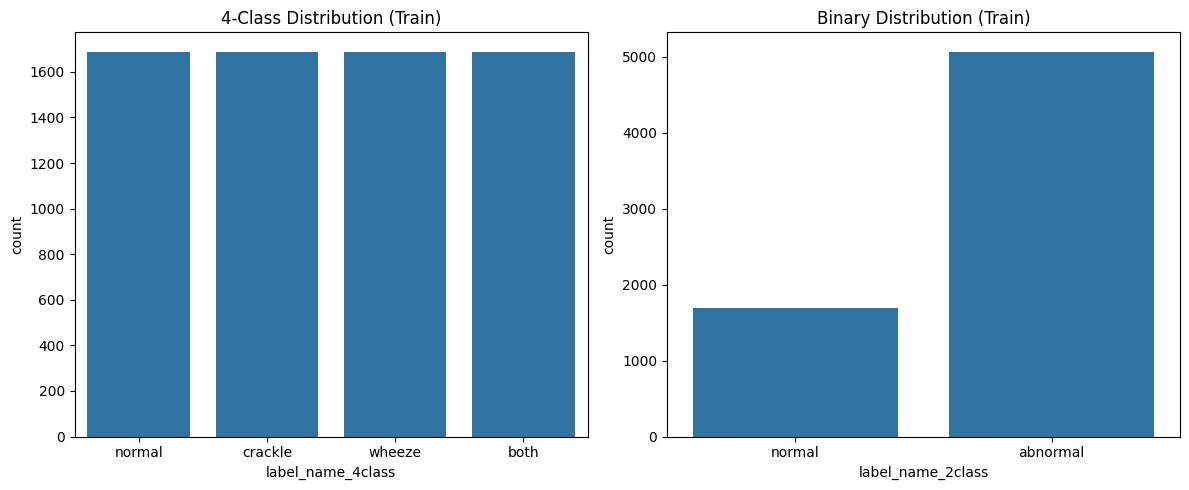

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use the combined_train_df directly from memory
train_prep_df = combined_train_df

print(f"Total samples in train data: {len(train_prep_df)}")

# 4-Class Distribution
print("\nDistribution of 4-Class Labels:")
display(train_prep_df['label_name_4class'].value_counts())

# 2-Class Distribution
print("\nDistribution of 2-Class Labels:")
display(train_prep_df['label_name_2class'].value_counts())

# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=train_prep_df, x='label_name_4class', order=['normal', 'crackle', 'wheeze', 'both'])
plt.title('4-Class Distribution (Train)')

plt.subplot(1, 2, 2)
sns.countplot(data=train_prep_df, x='label_name_2class')
plt.title('Binary Distribution (Train)')

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# CELL 17 — PREPROCESSING AUDIO
# =============================================================================
import os
import re
import gc
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from scipy.signal import butter, filtfilt
from tqdm import tqdm

# =========================
# 0. VALIDASI INPUT DARI CELL 12 & 14
# =========================
required_vars = [
    "AUG_TRAIN_META_PATH",
    "VAL_ORIG_META_PATH",
    "TEST_ORIG_META_PATH",
    "SPLIT_SUFFIX",
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        f"Variabel berikut belum ada — jalankan Cell 12 & 14 dulu: {missing_vars}"
    )

TRAIN_META = AUG_TRAIN_META_PATH
VAL_META   = VAL_ORIG_META_PATH
TEST_META  = TEST_ORIG_META_PATH

for p in [TRAIN_META, VAL_META, TEST_META]:
    assert os.path.exists(p), f"Tidak ditemukan: {p}"

# =========================
# 1. OUTPUT
# =========================
OUT_ROOT      = f"preprocessed_4class_{SPLIT_SUFFIX}"
TRAIN_OUT_DIR = os.path.join(OUT_ROOT, "train")
VAL_OUT_DIR   = os.path.join(OUT_ROOT, "val")
TEST_OUT_DIR  = os.path.join(OUT_ROOT, "test")

os.makedirs(TRAIN_OUT_DIR, exist_ok=True)
os.makedirs(VAL_OUT_DIR, exist_ok=True)
os.makedirs(TEST_OUT_DIR, exist_ok=True)

print("=" * 72)
print(f"  PREPROCESSING AUDIO | split {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)
print(f"  Train meta : {TRAIN_META}")
print(f"  Val meta   : {VAL_META}")
print(f"  Test meta  : {TEST_META}")
print(f"  Output     : {OUT_ROOT}/")

# =========================
# 2. PARAMETER PREPROCESSING
# =========================
TARGET_SR = 16000

USE_BANDPASS   = True
LOWCUT         = 100.0
HIGHCUT        = 7600.0   # aman di bawah Nyquist saat sr=16 kHz
BANDPASS_ORDER = 4

USE_RMS_NORMALIZATION = True
TARGET_DB             = -15.0

print(f"\n  TARGET_SR             : {TARGET_SR} Hz")
print(f"  Durasi                : native duration (tanpa padding)")
print(f"  USE_BANDPASS          : {USE_BANDPASS}")
if USE_BANDPASS:
    print(f"  Bandpass              : {int(LOWCUT)}–{int(HIGHCUT)} Hz | order={BANDPASS_ORDER}")
print(f"  USE_RMS_NORMALIZATION : {USE_RMS_NORMALIZATION}")
if USE_RMS_NORMALIZATION:
    print(f"  TARGET_DB             : {TARGET_DB} dB")

# =========================
# 3. HELPER
# =========================
def safe_filename(text, max_len=220):
    return re.sub(r"[^\w\-\.]+", "_", str(text))[:max_len]

def to_mono_float32(y):
    y = np.asarray(y)
    if y.ndim > 1:
        y = y.mean(axis=1)
    y = np.nan_to_num(y).astype(np.float32, copy=False)
    return y

def bandpass_filter(y, sr, lowcut=100.0, highcut=7600.0, order=4):
    if y is None or len(y) == 0:
        return y

    y = np.nan_to_num(y).astype(np.float32, copy=False)
    nyq = 0.5 * sr
    lo = max(lowcut, 1.0) / nyq
    hi = min(highcut, nyq * 0.95) / nyq

    if hi <= lo or hi >= 1.0:
        return y

    b, a = butter(order, [lo, hi], btype="band")
    try:
        yf = filtfilt(b, a, y).astype(np.float32, copy=False)
        return yf if np.all(np.isfinite(yf)) else y
    except Exception:
        return y

def normalize_rms(y, target_db=-15.0, eps=1e-10):
    if y is None or len(y) == 0:
        return y

    y = np.nan_to_num(y).astype(np.float32, copy=False)
    rms = np.sqrt(np.mean(y ** 2) + eps)
    if rms <= eps:
        return y

    gain = (10 ** (target_db / 20.0)) / rms
    return np.clip(y * gain, -1.0, 1.0).astype(np.float32, copy=False)

def preprocess_audio(y, sr):
    """
    Alur preprocessing TANPA padding:
      1. Konversi mono float32
      2. Resample ke TARGET_SR
      3. Bandpass filter (opsional)
      4. RMS normalization (opsional)

    Durasi asli dipertahankan sepenuhnya.
    """
    y = to_mono_float32(y)

    if len(y) == 0:
        return None, None

    if sr != TARGET_SR:
        y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR).astype(np.float32)
        sr = TARGET_SR

    if USE_BANDPASS:
        y = bandpass_filter(
            y, sr,
            lowcut=LOWCUT,
            highcut=HIGHCUT,
            order=BANDPASS_ORDER
        )

    if USE_RMS_NORMALIZATION:
        y = normalize_rms(y, target_db=TARGET_DB)

    if len(y) == 0 or not np.all(np.isfinite(y)):
        return None, None

    return y.astype(np.float32, copy=False), TARGET_SR

def load_segment(row):
    seg_file = str(row.get("file", ""))
    if seg_file and seg_file.lower() != "nan" and os.path.exists(seg_file):
        y, sr = sf.read(seg_file, always_2d=False)
        return to_mono_float32(y), sr

    wav_source = str(row.get("wav_source", ""))
    start_sec  = float(row.get("start_sec", 0.0))
    end_sec    = float(row.get("end_sec", 0.0))

    if (not wav_source) or (wav_source.lower() == "nan") or (not os.path.exists(wav_source)):
        return None, None
    if end_sec <= start_sec:
        return None, None

    y, sr = sf.read(wav_source, always_2d=False)
    y = to_mono_float32(y)

    s = max(0, min(int(np.floor(start_sec * sr)), len(y)))
    e = max(0, min(int(np.ceil(end_sec * sr)), len(y)))
    if e <= s:
        return None, None

    return y[s:e], sr

# =========================
# 4. VALIDASI INPUT SPLIT
# =========================
train_meta_df = pd.read_csv(TRAIN_META).copy()
val_meta_df   = pd.read_csv(VAL_META).copy()
test_meta_df  = pd.read_csv(TEST_META).copy()

for df_name, df in [
    ("train", train_meta_df), ("val", val_meta_df), ("test", test_meta_df)
]:
    if "patient_id" in df.columns:
        df["patient_id"] = df["patient_id"].astype(int)
    if "split" in df.columns:
        bad = df[df["split"].astype(str).str.lower() != df_name]
        if len(bad) > 0:
            raise AssertionError(
                f"{df_name.upper()} berisi {len(bad)} baris non-{df_name}."
            )

train_pat = set(train_meta_df["patient_id"].tolist())
val_pat   = set(val_meta_df["patient_id"].tolist())
test_pat  = set(test_meta_df["patient_id"].tolist())

assert not (train_pat & val_pat), "Overlap pasien train-val!"
assert not (train_pat & test_pat), "Overlap pasien train-test!"
assert not (val_pat & test_pat), "Overlap pasien val-test!"

print("\n[OK] Validasi split lulus — tidak ada overlap pasien train-val-test")

# =========================
# 5. FUNGSI UTAMA PREPROCESS PER SPLIT
# =========================
VALID_4CLASS = {"normal", "crackle", "wheeze", "both"}
VALID_2CLASS = {"normal", "abnormal"}

def run_preprocess(meta_path, split_name, save_dir):
    df = pd.read_csv(meta_path).copy()
    os.makedirs(save_dir, exist_ok=True)

    required_cols = [
        "patient_id", "label_4class", "label_name_4class",
        "label_2class", "label_name_2class",
    ]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise AssertionError(f"{split_name}: kolom wajib tidak ada: {missing_cols}")

    out_rows = []
    skipped = 0
    dur_list = []

    print(f"\n  [{split_name.upper()}] {len(df)} sampel -> {save_dir}")

    for idx, row in tqdm(df.iterrows(), total=len(df), ncols=100):
        y, sr = load_segment(row)
        if y is None or sr is None:
            skipped += 1
            continue

        try:
            lbl4  = int(row["label_4class"])
            lbl4n = str(row["label_name_4class"]).strip().lower()
            lbl2  = int(row["label_2class"])
            lbl2n = str(row["label_name_2class"]).strip().lower()

            if lbl4 not in (0, 1, 2, 3) or lbl4n not in VALID_4CLASS:
                skipped += 1
                continue
            if lbl2 not in (0, 1) or lbl2n not in VALID_2CLASS:
                skipped += 1
                continue

            cycle_id     = str(row["cycle_id"]) if "cycle_id" in df.columns else f"{split_name}_{idx}"
            recording_id = str(row["recording_id"]) if "recording_id" in df.columns else "unknown"
            patient_id   = int(row["patient_id"])
            is_aug       = int(row["is_augmented"]) if "is_augmented" in df.columns and pd.notna(row["is_augmented"]) else 0
            aug_type     = str(row["aug_type"]) if "aug_type" in df.columns and pd.notna(row["aug_type"]) else "none"
            aug_src      = str(row["aug_source"]) if "aug_source" in df.columns and pd.notna(row["aug_source"]) else "original"

            y_out, sr_out = preprocess_audio(y, sr)
            if y_out is None or sr_out is None or len(y_out) == 0:
                skipped += 1
                continue

            dur_sec = len(y_out) / sr_out
            dur_list.append(dur_sec)

            out_name = safe_filename(
                f"{cycle_id}_{lbl4n}_{lbl2n}_{split_name}_sr{TARGET_SR}.wav"
            )
            out_path = os.path.join(save_dir, out_name)
            sf.write(out_path, y_out, sr_out)

            desc_parts = [f"resample_{TARGET_SR}Hz"]
            if USE_BANDPASS:
                desc_parts.append(f"bandpass_{int(LOWCUT)}_{int(HIGHCUT)}")
            if USE_RMS_NORMALIZATION:
                desc_parts.append(f"rmsnorm_{TARGET_DB}dB")
            desc_parts.append("native_duration")

            out_rows.append({
                "prep_file":           out_path,
                "cycle_id":            cycle_id,
                "recording_id":        recording_id,
                "patient_id":          patient_id,
                "wav_source":          row.get("wav_source", ""),
                "start_sec":           row.get("start_sec", np.nan),
                "end_sec":             row.get("end_sec", np.nan),
                "duration_sec":        dur_sec,
                "label_4class":        lbl4,
                "label_name_4class":   lbl4n,
                "label_2class":        lbl2,
                "label_name_2class":   lbl2n,
                "split":               split_name,
                "sr":                  int(sr_out),
                "is_augmented":        is_aug,
                "aug_type":            aug_type,
                "aug_source":          aug_src,
                "outer_split_suffix":  SPLIT_SUFFIX,
                "preprocess_desc":     "+".join(desc_parts),
            })

        except Exception:
            skipped += 1
            continue

        if (idx + 1) % 300 == 0:
            gc.collect()

    out_df = pd.DataFrame(out_rows)
    out_csv = os.path.join(
        OUT_ROOT,
        f"metadata_{split_name}_preprocessed_{TARGET_SR}Hz_native_dur_4class.csv"
    )
    out_df.to_csv(out_csv, index=False)

    print(f"  Tersimpan      : {len(out_df)}")
    print(f"  Skip           : {skipped}")
    if dur_list:
        dur_arr = np.array(dur_list)
        print(
            f"  Durasi (s)     : min={dur_arr.min():.2f}  "
            f"median={np.median(dur_arr):.2f}  "
            f"mean={dur_arr.mean():.2f}  "
            f"max={dur_arr.max():.2f}"
        )
    if len(out_df) > 0:
        print(f"  4 kelas        : {out_df['label_name_4class'].value_counts().to_dict()}")
    print(f"  CSV            : {out_csv}")

    return out_csv

# =========================
# 6. EKSEKUSI
# =========================
train_prep_csv = run_preprocess(TRAIN_META, "train", TRAIN_OUT_DIR)
val_prep_csv   = run_preprocess(VAL_META, "val", VAL_OUT_DIR)
test_prep_csv  = run_preprocess(TEST_META, "test", TEST_OUT_DIR)

# =========================
# 7. ALIAS UNTUK CELL 19
# =========================
PREPROC_ROOT   = OUT_ROOT
TRAIN_PREP_CSV = train_prep_csv
VAL_PREP_CSV   = val_prep_csv
TEST_PREP_CSV  = test_prep_csv

print(f"\n{'='*72}")
print(f"  SELESAI | PREPROCESSING {SPLIT_SUFFIX.replace('_', ':')}")
print(f"{'='*72}")
print(f"  PREPROC_ROOT   = '{PREPROC_ROOT}'")
print(f"  TRAIN_PREP_CSV = '{TRAIN_PREP_CSV}'")
print(f"  VAL_PREP_CSV   = '{VAL_PREP_CSV}'")
print(f"  TEST_PREP_CSV  = '{TEST_PREP_CSV}'")
print(f"\n  Catatan:")
print(f"  - Durasi asli dipertahankan.")
print(f"  - Cell 19 akan mengonversi audio hasil preprocess ke citra log-mel.")

  PREPROCESSING AUDIO | split 60:40
  Train meta : augmented_audio_4class_60_40_innertrain_v7/metadata_train_plus_augmented_4class.csv
  Val meta   : metadata_icbhi_subject_independent_60_40_val20/metadata_val_60_40_4class.csv
  Test meta  : metadata_icbhi_subject_independent_60_40_val20/metadata_test_60_40_4class.csv
  Output     : preprocessed_4class_60_40/

  TARGET_SR             : 16000 Hz
  Durasi                : native duration (tanpa padding)
  USE_BANDPASS          : True
  Bandpass              : 100–7600 Hz | order=4
  USE_RMS_NORMALIZATION : True
  TARGET_DB             : -15.0 dB

[OK] Validasi split lulus — tidak ada overlap pasien train-val-test

  [TRAIN] 6756 sampel -> preprocessed_4class_60_40/train


100%|███████████████████████████████████████████████████████████| 6756/6756 [01:09<00:00, 97.56it/s]


  Tersimpan      : 6756
  Skip           : 0
  Durasi (s)     : min=0.29  median=2.59  mean=2.78  max=16.16
  4 kelas        : {'normal': 1689, 'wheeze': 1689, 'crackle': 1689, 'both': 1689}
  CSV            : preprocessed_4class_60_40/metadata_train_preprocessed_16000Hz_native_dur_4class.csv

  [VAL] 553 sampel -> preprocessed_4class_60_40/val


100%|████████████████████████████████████████████████████████████| 553/553 [00:05<00:00, 107.70it/s]


  Tersimpan      : 553
  Skip           : 0
  Durasi (s)     : min=0.24  median=2.60  mean=2.67  max=5.94
  4 kelas        : {'normal': 325, 'crackle': 114, 'wheeze': 72, 'both': 42}
  CSV            : preprocessed_4class_60_40/metadata_val_preprocessed_16000Hz_native_dur_4class.csv

  [TEST] 2895 sampel -> preprocessed_4class_60_40/test


100%|███████████████████████████████████████████████████████████| 2895/2895 [00:30<00:00, 93.60it/s]


  Tersimpan      : 2895
  Skip           : 0
  Durasi (s)     : min=0.20  median=2.60  mean=2.73  max=11.21
  4 kelas        : {'normal': 1628, 'crackle': 620, 'wheeze': 481, 'both': 166}
  CSV            : preprocessed_4class_60_40/metadata_test_preprocessed_16000Hz_native_dur_4class.csv

  SELESAI | PREPROCESSING 60:40
  PREPROC_ROOT   = 'preprocessed_4class_60_40'
  TRAIN_PREP_CSV = 'preprocessed_4class_60_40/metadata_train_preprocessed_16000Hz_native_dur_4class.csv'
  VAL_PREP_CSV   = 'preprocessed_4class_60_40/metadata_val_preprocessed_16000Hz_native_dur_4class.csv'
  TEST_PREP_CSV  = 'preprocessed_4class_60_40/metadata_test_preprocessed_16000Hz_native_dur_4class.csv'

  Catatan:
  - Durasi asli dipertahankan.
  - Cell 19 akan mengonversi audio hasil preprocess ke citra log-mel.


# **Konversi citra log mel spectrogram**

In [ ]:
# =============================================================================
# CELL 19 — KONVERSI KE CITRA LOG-MEL SPECTROGRAM
# =============================================================================
import os
import gc
import re
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
from PIL import Image
from tqdm import tqdm

# =========================
# 0. VALIDASI INPUT DARI CELL 17
# =========================
required_vars = [
    "TRAIN_PREP_CSV", "VAL_PREP_CSV", "TEST_PREP_CSV",
    "PREPROC_ROOT", "SPLIT_SUFFIX",
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        f"Variabel berikut belum ada — jalankan Cell 17 dulu: {missing_vars}"
    )

train_meta_path = TRAIN_PREP_CSV
val_meta_path   = VAL_PREP_CSV
test_meta_path  = TEST_PREP_CSV

for p in [train_meta_path, val_meta_path, test_meta_path]:
    assert os.path.exists(p), f"Metadata tidak ditemukan: {p}"

SR_TARGET_CELL17 = globals().get("TARGET_SR", 16000)

# =========================
# 1. OUTPUT
# =========================
IMG_ROOT       = f"logmel_images_4class_{SPLIT_SUFFIX}"
TRAIN_IMG_DIR  = os.path.join(IMG_ROOT, "train")
VAL_IMG_DIR    = os.path.join(IMG_ROOT, "val")
TEST_IMG_DIR   = os.path.join(IMG_ROOT, "test")

META_OUT_ROOT  = f"metadata_features_4class_{SPLIT_SUFFIX}"
META_TRAIN_OUT = os.path.join(META_OUT_ROOT, "metadata_lmimg_train_4class.csv")
META_VAL_OUT   = os.path.join(META_OUT_ROOT, "metadata_lmimg_val_4class.csv")
META_TEST_OUT  = os.path.join(META_OUT_ROOT, "metadata_lmimg_test_4class.csv")
META_ALL_OUT   = os.path.join(META_OUT_ROOT, "metadata_lmimg_all_4class.csv")

os.makedirs(META_OUT_ROOT, exist_ok=True)
os.makedirs(TRAIN_IMG_DIR, exist_ok=True)
os.makedirs(VAL_IMG_DIR, exist_ok=True)
os.makedirs(TEST_IMG_DIR, exist_ok=True)

FORCE_REGENERATE = False

print("=" * 72)
print(f"  KONVERSI LOG-MEL IMAGE | split {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)

# =========================
# 2. PARAMETER FITUR
# =========================
SR_TARGET  = SR_TARGET_CELL17
N_FFT      = 2048
HOP_LENGTH = 128
WIN_LENGTH = 2048
N_MELS     = 128
FMIN       = 100
FMAX       = 7600

FEATURE_MODE = "logmel_delta12"

SAVE_IMAGE_SIZE    = (384, 384)
RESIZE_BEFORE_SAVE = True

# hanya untuk menjaga agar spectrogram tidak terlalu degenerate
MIN_FRAMES = 8

VALID_4CLASS = ["normal", "crackle", "wheeze", "both"]
VALID_IMAGE_EXT = ".png"

assert FEATURE_MODE in ["logmel_only_replicated", "logmel_delta12"], \
    "FEATURE_MODE harus 'logmel_only_replicated' atau 'logmel_delta12'"

print(f"\n  SR_TARGET          : {SR_TARGET}")
print(f"  N_FFT              : {N_FFT}")
print(f"  HOP_LENGTH         : {HOP_LENGTH}  (~{HOP_LENGTH/SR_TARGET*1000:.1f} ms/frame)")
print(f"  WIN_LENGTH         : {WIN_LENGTH}")
print(f"  N_MELS             : {N_MELS}")
print(f"  FMIN/FMAX          : {FMIN}–{FMAX} Hz")
print(f"  FEATURE_MODE       : {FEATURE_MODE}")
print(f"  RESIZE_BEFORE_SAVE : {RESIZE_BEFORE_SAVE} -> {SAVE_IMAGE_SIZE}")
print(f"  Durasi             : native duration (tanpa padding)")
print(f"  MIN_FRAMES         : {MIN_FRAMES}")

# =========================
# 3. HELPER
# =========================
def safe_filename(text: str, max_len: int = 220) -> str:
    return re.sub(r"[^\w\-\.]+", "_", str(text))[:max_len]

def minmax_uint8(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    xmin = x.min()
    xmax = x.max()
    if xmax - xmin < 1e-8:
        return np.zeros_like(x, dtype=np.uint8)
    return ((x - xmin) / (xmax - xmin) * 255.0).clip(0, 255).astype(np.uint8)

try:
    BILINEAR_RESAMPLE = Image.Resampling.BILINEAR
except AttributeError:
    BILINEAR_RESAMPLE = Image.BILINEAR

# =========================
# 4. FUNGSI KONVERSI AUDIO -> CITRA
# =========================
def audio_to_image(
    wav_path: str,
    feature_mode: str = FEATURE_MODE,
    sr_target: int = SR_TARGET,
    n_fft: int = N_FFT,
    hop_length: int = HOP_LENGTH,
    win_length: int = WIN_LENGTH,
    n_mels: int = N_MELS,
    fmin: int = FMIN,
    fmax: int = FMAX,
    resize_before_save: bool = RESIZE_BEFORE_SAVE,
    save_image_size: tuple = SAVE_IMAGE_SIZE,
):
    """
    Konversi file WAV hasil Cell 17 ke citra RGB.
    Tidak ada padding tambahan di cell ini.
    """
    y, sr = sf.read(wav_path, always_2d=False)

    if isinstance(y, np.ndarray) and y.ndim > 1:
        y = y.mean(axis=1)

    y = np.nan_to_num(y).astype(np.float32, copy=False)

    if len(y) == 0:
        raise ValueError(f"Audio kosong: {wav_path}")

    if sr != sr_target:
        y = librosa.resample(y, orig_sr=sr, target_sr=sr_target).astype(np.float32)
        sr = sr_target

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax,
        power=2.0,
    ).astype(np.float32)

    logmel = librosa.power_to_db(mel + 1e-10, ref=np.max).astype(np.float32)
    n_frames = int(logmel.shape[1])

    if n_frames < MIN_FRAMES:
        raise ValueError(f"Terlalu sedikit frame ({n_frames} < {MIN_FRAMES}): {wav_path}")

    if feature_mode == "logmel_only_replicated":
        ch0 = minmax_uint8(logmel)
        ch1 = minmax_uint8(logmel)
        ch2 = minmax_uint8(logmel)
    else:
        delta1 = librosa.feature.delta(
            logmel, width=9, order=1, axis=-1, mode="interp"
        ).astype(np.float32)
        delta2 = librosa.feature.delta(
            logmel, width=9, order=2, axis=-1, mode="interp"
        ).astype(np.float32)

        ch0 = minmax_uint8(logmel)
        ch1 = minmax_uint8(delta1)
        ch2 = minmax_uint8(delta2)

    img_arr = np.stack([ch0, ch1, ch2], axis=-1)
    img = Image.fromarray(img_arr, mode="RGB")

    if resize_before_save:
        img = img.resize(save_image_size, BILINEAR_RESAMPLE)

    return img, n_frames, n_mels

# =========================
# 5. FUNGSI KONVERSI PER SPLIT
# =========================
def convert_split_to_images(df: pd.DataFrame, split_name: str, save_root: str) -> pd.DataFrame:
    required_cols = [
        "prep_file", "label_4class", "label_name_4class",
        "label_2class", "label_name_2class",
    ]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise AssertionError(f"{split_name}: kolom wajib tidak ada: {missing_cols}")

    image_paths = []
    image_ok = []
    n_frames_list = []
    n_missing_aud = 0
    n_error = 0
    n_skip_lbl = 0

    print(f"\n  Konversi {split_name.upper()} | {len(df)} sampel")

    for i, row in tqdm(df.iterrows(), total=len(df), desc=f"  {split_name}", ncols=100):
        wav_path = str(row["prep_file"])
        lbl4n = str(row["label_name_4class"]).strip().lower()

        if lbl4n not in VALID_4CLASS:
            image_paths.append(None)
            image_ok.append(0)
            n_frames_list.append(np.nan)
            n_skip_lbl += 1
            continue

        if not os.path.exists(wav_path):
            image_paths.append(None)
            image_ok.append(0)
            n_frames_list.append(np.nan)
            n_missing_aud += 1
            continue

        cycle_id = (
            str(row["cycle_id"])
            if "cycle_id" in df.columns and pd.notna(row["cycle_id"])
            else f"{split_name}_{i}"
        )
        lbl2n = str(row["label_name_2class"]).strip().lower()

        out_dir = os.path.join(save_root, lbl4n)
        os.makedirs(out_dir, exist_ok=True)

        out_name = safe_filename(
            f"{cycle_id}_{lbl4n}_{lbl2n}_{FEATURE_MODE}{VALID_IMAGE_EXT}"
        )
        out_path = os.path.join(out_dir, out_name)
        n_frames = np.nan

        if FORCE_REGENERATE and os.path.exists(out_path):
            os.remove(out_path)

        try:
            img, n_frames, _ = audio_to_image(wav_path=wav_path)
            if (not os.path.exists(out_path)) or FORCE_REGENERATE:
                img.save(out_path)
        except Exception:
            n_error += 1
            out_path = None

        ok = 1 if (out_path is not None and os.path.exists(out_path)) else 0
        image_paths.append(out_path)
        image_ok.append(ok)
        n_frames_list.append(n_frames)

        if (i + 1) % 200 == 0:
            gc.collect()

    df = df.copy()
    df["image_path"]    = image_paths
    df["image_ok"]      = image_ok
    df["image_type"]    = f"{FEATURE_MODE}_16k_hop{HOP_LENGTH}_nmels{N_MELS}_384"
    df["spec_n_frames"] = n_frames_list
    df["split"]         = split_name

    n_ok = int(df["image_ok"].sum())
    print(f"    Image OK      : {n_ok}")
    print(f"    Audio missing : {n_missing_aud}")
    print(f"    Error konversi: {n_error}")
    print(f"    Skip label    : {n_skip_lbl}")

    if n_ok > 0:
        frames_ok = df.loc[df["image_ok"] == 1, "spec_n_frames"].dropna()
        print(
            f"    N_frames      : min={frames_ok.min():.0f}  "
            f"median={frames_ok.median():.0f}  "
            f"max={frames_ok.max():.0f}"
        )

    return df

# =========================
# 6. LOAD METADATA & KONVERSI
# =========================
train_df = pd.read_csv(train_meta_path).copy()
val_df   = pd.read_csv(val_meta_path).copy()
test_df  = pd.read_csv(test_meta_path).copy()

print(f"\n  Train : {len(train_df)}  |  Val : {len(val_df)}  |  Test : {len(test_df)}")

train_img_df = convert_split_to_images(train_df, "train", TRAIN_IMG_DIR)
val_img_df   = convert_split_to_images(val_df, "val", VAL_IMG_DIR)
test_img_df  = convert_split_to_images(test_df, "test", TEST_IMG_DIR)

# =========================
# 7. FILTER GAMBAR VALID
# =========================
train_img_df = train_img_df[train_img_df["image_ok"] == 1].reset_index(drop=True)
val_img_df   = val_img_df[val_img_df["image_ok"] == 1].reset_index(drop=True)
test_img_df  = test_img_df[test_img_df["image_ok"] == 1].reset_index(drop=True)

print(f"\n  Image valid -> Train:{len(train_img_df)}  Val:{len(val_img_df)}  Test:{len(test_img_df)}")

# =========================
# 8. SIMPAN METADATA
# =========================
train_img_df.to_csv(META_TRAIN_OUT, index=False)
val_img_df.to_csv(META_VAL_OUT, index=False)
test_img_df.to_csv(META_TEST_OUT, index=False)

meta_all = pd.concat([train_img_df, val_img_df, test_img_df], ignore_index=True)
meta_all.to_csv(META_ALL_OUT, index=False)

# =========================
# 9. RINGKASAN AKHIR
# =========================
print(f"\n{'='*72}")
print(f"  SELESAI | KONVERSI LOG-MEL IMAGE {SPLIT_SUFFIX.replace('_', ':')}")
print(f"{'='*72}")
print(f"\n  Per split:")
print(meta_all.groupby('split')[['image_ok']].sum().to_string())

print(f"\n  Distribusi 4 kelas total:")
print(meta_all["label_name_4class"].value_counts().reindex(VALID_4CLASS, fill_value=0))

print(f"\n  Parameter fitur:")
print(f"    N_FFT/WIN  : {N_FFT}")
print(f"    HOP_LENGTH : {HOP_LENGTH}  (~{HOP_LENGTH/SR_TARGET*1000:.1f} ms/frame)")
print(f"    N_MELS     : {N_MELS}")
print(f"    FMIN/FMAX  : {FMIN}–{FMAX} Hz")
print(f"    Mode       : {FEATURE_MODE}")
print(f"    Image size : {SAVE_IMAGE_SIZE} (resize disimpan ke disk)")
print(f"    Durasi     : native duration (tanpa padding)")

# =========================
# 10. ALIAS UNTUK CELL LOADER
# =========================
META_FEATURES_ROOT  = META_OUT_ROOT
TRAIN_IMG_META_PATH = META_TRAIN_OUT
VAL_IMG_META_PATH   = META_VAL_OUT
TEST_IMG_META_PATH  = META_TEST_OUT

print(f"\n--- Alias siap untuk cell loader (Cell 21 & 30) ---")
print(f"  META_FEATURES_ROOT  = '{META_FEATURES_ROOT}'")
print(f"  TRAIN_IMG_META_PATH = '{TRAIN_IMG_META_PATH}'")
print(f"  VAL_IMG_META_PATH   = '{VAL_IMG_META_PATH}'")
print(f"  TEST_IMG_META_PATH  = '{TEST_IMG_META_PATH}'")

  KONVERSI LOG-MEL IMAGE | split 60:40

  SR_TARGET          : 16000
  N_FFT              : 2048
  HOP_LENGTH         : 128  (~8.0 ms/frame)
  WIN_LENGTH         : 2048
  N_MELS             : 128
  FMIN/FMAX          : 100–7600 Hz
  FEATURE_MODE       : logmel_delta12
  RESIZE_BEFORE_SAVE : True -> (384, 384)
  Durasi             : native duration (tanpa padding)
  MIN_FRAMES         : 8

  Train : 6756  |  Val : 553  |  Test : 2895

  Konversi TRAIN | 6756 sampel


  train:   0%|                                                             | 0/6756 [00:00<?, ?it/s]/tmp/ipykernel_1420/4045151204.py:185: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_arr, mode="RGB")
  train: 100%|██████████████████████████████████████████████████| 6756/6756 [11:36<00:00,  9.70it/s]


    Image OK      : 6756
    Audio missing : 0
    Error konversi: 0
    Skip label    : 0
    N_frames      : min=36  median=325  max=2021

  Konversi VAL | 553 sampel


  val:   0%|                                                                | 0/553 [00:00<?, ?it/s]/tmp/ipykernel_1420/4045151204.py:185: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_arr, mode="RGB")
  val: 100%|██████████████████████████████████████████████████████| 553/553 [00:57<00:00,  9.61it/s]


    Image OK      : 553
    Audio missing : 0
    Error konversi: 0
    Skip label    : 0
    N_frames      : min=31  median=326  max=743

  Konversi TEST | 2895 sampel


  test:   0%|                                                              | 0/2895 [00:00<?, ?it/s]/tmp/ipykernel_1420/4045151204.py:185: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_arr, mode="RGB")
  test: 100%|███████████████████████████████████████████████████| 2895/2895 [05:04<00:00,  9.51it/s]


    Image OK      : 2895
    Audio missing : 0
    Error konversi: 0
    Skip label    : 0
    N_frames      : min=26  median=325  max=1401

  Image valid -> Train:6756  Val:553  Test:2895

  SELESAI | KONVERSI LOG-MEL IMAGE 60:40

  Per split:
       image_ok
split          
test       2895
train      6756
val         553

  Distribusi 4 kelas total:
label_name_4class
normal     3642
crackle    2423
wheeze     2242
both       1897
Name: count, dtype: int64

  Parameter fitur:
    N_FFT/WIN  : 2048
    HOP_LENGTH : 128  (~8.0 ms/frame)
    N_MELS     : 128
    FMIN/FMAX  : 100–7600 Hz
    Mode       : logmel_delta12
    Image size : (384, 384) (resize disimpan ke disk)
    Durasi     : native duration (tanpa padding)

--- Alias siap untuk cell loader (Cell 21 & 30) ---
  META_FEATURES_ROOT  = 'metadata_features_4class_60_40'
  TRAIN_IMG_META_PATH = 'metadata_features_4class_60_40/metadata_lmimg_train_4class.csv'
  VAL_IMG_META_PATH   = 'metadata_features_4class_60_40/metadata_lmimg_val

# **Dataset Loader**
> EfficientNEtV2



In [ ]:
# =============================================================================
# CELL 21 — DATA LOADER EFFICIENTNETV2-S
# =============================================================================
import os
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageFile
from torchvision import transforms
from torchvision.transforms import InterpolationMode

ImageFile.LOAD_TRUNCATED_IMAGES = True

# =========================
# 0. VALIDASI VARIABEL DARI CELL 19
# =========================
required_vars = [
    "TRAIN_IMG_META_PATH", "VAL_IMG_META_PATH",
    "TEST_IMG_META_PATH", "META_FEATURES_ROOT", "SPLIT_SUFFIX",
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        f"Variabel berikut belum ada — jalankan Cell 19 dulu: {missing_vars}"
    )

USE_VAL         = True
TRAIN_META_PATH = TRAIN_IMG_META_PATH
VAL_META_PATH   = VAL_IMG_META_PATH
TEST_META_PATH  = TEST_IMG_META_PATH

for p in [TRAIN_META_PATH, VAL_META_PATH, TEST_META_PATH]:
    assert os.path.exists(p), f"Metadata image tidak ditemukan: {p}"

print("=" * 72)
print(f"  DATALOADER EFFICIENTNETV2-S | split {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)
print(f"  Train meta : {TRAIN_META_PATH}")
print(f"  Val meta   : {VAL_META_PATH}")
print(f"  Test meta  : {TEST_META_PATH}")

# =========================
# 1. KONFIGURASI KELAS & INPUT
# =========================
NUM_CLASSES_4CLASS = 4
CLASS_NAMES_4CLASS = ["normal", "crackle", "wheeze", "both"]

NUM_CLASSES_BINARY = 2
CLASS_NAMES_BINARY = ["normal", "abnormal"]

COLLAPSE_MAP = torch.tensor([0, 1, 1, 1], dtype=torch.long)

IMAGE_SIZE_EFFNET = 384
BATCH_SIZE = 16

CPU_COUNT = os.cpu_count() or 2
NUM_WORKERS = min(4, max(2, CPU_COUNT // 2))
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0
PREFETCH_FACTOR = 2 if NUM_WORKERS > 0 else None

# Fair comparison: CBS dimatikan
ENABLE_CBS = False
CBS_TARGET_MODE = "disabled"

# SpecAugment konsisten untuk kedua model
FREQ_MASK_PARAM = 8
TIME_MASK_PARAM = 20

# Reproducibility
LOADER_SEED = 42

# =========================
# 2. LOAD & BERSIHKAN METADATA
# =========================
train_img_df_4class = pd.read_csv(TRAIN_META_PATH).copy()
val_img_df_4class   = pd.read_csv(VAL_META_PATH).copy()
test_img_df_4class  = pd.read_csv(TEST_META_PATH).copy()

def clean_image_metadata(df_name, df, expected_split):
    df = df.copy()

    required_cols = [
        "image_path", "split",
        "label_4class", "label_name_4class",
        "label_2class", "label_name_2class",
    ]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise AssertionError(f"{df_name}: kolom wajib tidak ada: {missing_cols}")

    df["split"]             = df["split"].astype(str).str.strip().str.lower()
    df["label_4class"]      = df["label_4class"].astype(int)
    df["label_2class"]      = df["label_2class"].astype(int)
    df["label_name_4class"] = df["label_name_4class"].astype(str).str.strip().str.lower()
    df["label_name_2class"] = df["label_name_2class"].astype(str).str.strip().str.lower()

    if "image_ok" in df.columns:
        df = df[df["image_ok"] == 1].reset_index(drop=True)

    df = df[df["image_path"].notna()].reset_index(drop=True)
    df = df[df["image_path"].astype(str).str.lower() != "nan"].reset_index(drop=True)

    exists_mask = df["image_path"].apply(os.path.exists)
    n_missing = int((~exists_mask).sum())
    if n_missing > 0:
        print(f"  [{df_name}] image hilang di disk: {n_missing} -> dilewati")
        df = df[exists_mask].reset_index(drop=True)

    df = df[df["label_4class"].isin([0, 1, 2, 3])].reset_index(drop=True)
    df = df[df["label_name_4class"].isin(CLASS_NAMES_4CLASS)].reset_index(drop=True)
    df = df[df["label_2class"].isin([0, 1])].reset_index(drop=True)
    df = df[df["label_name_2class"].isin(CLASS_NAMES_BINARY)].reset_index(drop=True)

    bad_split = df[df["split"] != expected_split]
    if len(bad_split) > 0:
        raise AssertionError(
            f"{df_name}: ditemukan split selain '{expected_split}'. Pipeline belum sinkron."
        )

    return df.reset_index(drop=True)

train_img_df_4class = clean_image_metadata("train", train_img_df_4class, "train")
val_img_df_4class   = clean_image_metadata("val", val_img_df_4class, "val")
test_img_df_4class  = clean_image_metadata("test", test_img_df_4class, "test")

assert len(train_img_df_4class) > 0, "train_img_df_4class kosong"
assert len(val_img_df_4class) > 0, "val_img_df_4class kosong"
assert len(test_img_df_4class) > 0, "test_img_df_4class kosong"

# Sanity check — tidak ada overlap pasien
if all("patient_id" in df.columns for df in [train_img_df_4class, val_img_df_4class, test_img_df_4class]):
    train_pat = set(train_img_df_4class["patient_id"].dropna().astype(int))
    val_pat   = set(val_img_df_4class["patient_id"].dropna().astype(int))
    test_pat  = set(test_img_df_4class["patient_id"].dropna().astype(int))
    assert not (train_pat & val_pat), "Overlap pasien train-val!"
    assert not (train_pat & test_pat), "Overlap pasien train-test!"
    assert not (val_pat & test_pat), "Overlap pasien val-test!"

n_train_pat = train_img_df_4class["patient_id"].nunique() if "patient_id" in train_img_df_4class.columns else "n/a"
n_val_pat   = val_img_df_4class["patient_id"].nunique() if "patient_id" in val_img_df_4class.columns else "n/a"
n_test_pat  = test_img_df_4class["patient_id"].nunique() if "patient_id" in test_img_df_4class.columns else "n/a"

print(f"\n  Train : {len(train_img_df_4class)} sampel | {n_train_pat} pasien")
print(f"  Val   : {len(val_img_df_4class)} sampel | {n_val_pat} pasien")
print(f"  Test  : {len(test_img_df_4class)} sampel | {n_test_pat} pasien")

print(f"\n  Distribusi 4 kelas train:")
print(train_img_df_4class["label_name_4class"].value_counts().reindex(CLASS_NAMES_4CLASS, fill_value=0))
print(f"\n  Distribusi 4 kelas val:")
print(val_img_df_4class["label_name_4class"].value_counts().reindex(CLASS_NAMES_4CLASS, fill_value=0))
print(f"\n  Distribusi 4 kelas test:")
print(test_img_df_4class["label_name_4class"].value_counts().reindex(CLASS_NAMES_4CLASS, fill_value=0))
print(f"\n  Distribusi 2 kelas train:")
print(train_img_df_4class["label_name_2class"].value_counts().reindex(CLASS_NAMES_BINARY, fill_value=0))

# =========================
# 3. STATISTIK NORMALISASI (TRAIN SAJA, REPRODUCIBLE)
# =========================
def safe_open_rgb(path):
    with Image.open(path) as img:
        return img.convert("RGB").copy()

def compute_image_stats(img_paths, sample_size=800, seed=42):
    if len(img_paths) == 0:
        raise RuntimeError("img_paths kosong.")

    rng = random.Random(seed)
    sampled = rng.sample(img_paths, min(sample_size, len(img_paths)))

    to_tensor = transforms.ToTensor()
    means, stds = [], []

    for p in sampled:
        try:
            img = safe_open_rgb(p)
            t = to_tensor(img)
            means.append(t.mean(dim=[1, 2]))
            stds.append(t.std(dim=[1, 2]))
        except Exception:
            continue

    if not means:
        raise RuntimeError("Semua gambar gagal dimuat saat hitung statistik.")

    mean = torch.stack(means).mean(dim=0).tolist()
    std = [max(s, 1e-6) for s in torch.stack(stds).mean(dim=0).tolist()]
    return mean, std

print("\n  Menghitung statistik normalisasi dari train saja...")
LOGMEL_MEAN, LOGMEL_STD = compute_image_stats(
    train_img_df_4class["image_path"].tolist(),
    sample_size=800,
    seed=LOADER_SEED,
)
print(f"  mean : {[round(m, 4) for m in LOGMEL_MEAN]}")
print(f"  std  : {[round(s, 4) for s in LOGMEL_STD]}")

# =========================
# 4. SPECAUGMENT — FreqTimeMask
# =========================
class FreqTimeMask:
    """
    SpecAugment pada tensor [C, H, W].
    Frequency mask pada sumbu H, time mask pada sumbu W.
    """
    def __init__(self, freq_mask=8, time_mask=20):
        self.freq_mask = int(freq_mask)
        self.time_mask = int(time_mask)

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        x = x.clone()
        _, H, W = x.shape

        f = np.random.randint(0, self.freq_mask + 1)
        if f > 0:
            f0 = np.random.randint(0, max(H - f + 1, 1))
            x[:, f0:f0 + f, :] = 0.0

        t = np.random.randint(0, self.time_mask + 1)
        if t > 0:
            t0 = np.random.randint(0, max(W - t + 1, 1))
            x[:, :, t0:t0 + t] = 0.0

        return x

# =========================
# 5. TRANSFORM
# =========================
train_transform_4class = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE_EFFNET, IMAGE_SIZE_EFFNET),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=LOGMEL_MEAN, std=LOGMEL_STD),
    FreqTimeMask(freq_mask=FREQ_MASK_PARAM, time_mask=TIME_MASK_PARAM),
])

eval_transform_4class = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE_EFFNET, IMAGE_SIZE_EFFNET),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=LOGMEL_MEAN, std=LOGMEL_STD),
])

print(f"\n  Transform train : Resize({IMAGE_SIZE_EFFNET}) -> ToTensor -> Normalize -> FreqTimeMask(f={FREQ_MASK_PARAM}, t={TIME_MASK_PARAM})")
print(f"  Transform eval  : Resize({IMAGE_SIZE_EFFNET}) -> ToTensor -> Normalize")

# =========================
# 6. DATASET CLASS
# =========================
class Respiratory4ClassImageDataset(Dataset):
    def __init__(self, df, transform=None, return_meta=False):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = str(row["image_path"])

        if (not image_path) or (image_path.lower() == "nan") or (not os.path.exists(image_path)):
            raise FileNotFoundError(f"Image tidak ditemukan: {image_path}")

        try:
            img = safe_open_rgb(image_path)
        except Exception as e:
            raise RuntimeError(f"Gagal membuka image: {image_path} | {e}")

        x = self.transform(img) if self.transform is not None else transforms.ToTensor()(img)
        y = torch.tensor(int(row["label_4class"]), dtype=torch.long)

        if self.return_meta:
            meta = {
                "cycle_id": str(row["cycle_id"]) if "cycle_id" in row.index else f"sample_{idx}",
                "patient_id": int(row["patient_id"]) if "patient_id" in row.index and pd.notna(row["patient_id"]) else -1,
                "label_4class": int(row["label_4class"]),
                "label_name_4class": str(row["label_name_4class"]),
                "label_2class": int(row["label_2class"]),
                "label_name_2class": str(row["label_name_2class"]),
                "image_path": image_path,
                "split": str(row["split"]),
                "is_augmented": int(row["is_augmented"]) if "is_augmented" in row.index and pd.notna(row["is_augmented"]) else 0,
                "aug_type": str(row["aug_type"]) if "aug_type" in row.index and pd.notna(row["aug_type"]) else "none",
                "aug_source": str(row["aug_source"]) if "aug_source" in row.index and pd.notna(row["aug_source"]) else "original",
            }
            return x, y, meta

        return x, y

# =========================
# 7. BUAT DATASET
# =========================
train_ds_4class = Respiratory4ClassImageDataset(
    train_img_df_4class, transform=train_transform_4class, return_meta=False
)
val_ds_4class = Respiratory4ClassImageDataset(
    val_img_df_4class, transform=eval_transform_4class, return_meta=True
)
test_ds_4class = Respiratory4ClassImageDataset(
    test_img_df_4class, transform=eval_transform_4class, return_meta=True
)

# =========================
# 8. DATALOADER
# =========================
def seed_worker(worker_id):
    worker_seed = LOADER_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(LOADER_SEED)

train_sampler = None
total_samples = len(train_ds_4class)

loader_common_kwargs = dict(
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    generator=g,
)

if NUM_WORKERS > 0:
    loader_common_kwargs["prefetch_factor"] = PREFETCH_FACTOR

train_loader_4class = DataLoader(
    train_ds_4class,
    batch_size=BATCH_SIZE,
    sampler=None,
    shuffle=True,
    drop_last=True,
    **loader_common_kwargs,
)

val_loader_4class = DataLoader(
    val_ds_4class,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **loader_common_kwargs,
)

test_loader_4class = DataLoader(
    test_ds_4class,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **loader_common_kwargs,
)

# =========================
# 9. SANITY CHECK
# =========================
batch = next(iter(train_loader_4class))
xb, yb = batch[0], batch[1]
unique_lbl, cnt_lbl = torch.unique(yb, sorted=True, return_counts=True)

print(f"\n  Sanity check EfficientNetV2-S dataloader:")
print(f"  X shape  : {xb.shape}")   # [B, 3, 384, 384]
print(f"  Y shape  : {yb.shape}")
print(f"  X min/max: {xb.min():.3f} / {xb.max():.3f}")
print(f"  Distribusi label di 1 batch:")
for lbl, cnt in zip(unique_lbl.tolist(), cnt_lbl.tolist()):
    print(f"    {lbl} ({CLASS_NAMES_4CLASS[lbl]:8s}): {cnt:2d}  {'█' * cnt}")

print(f"\n  Train batches : {len(train_loader_4class)} ({total_samples} sampel)")
print(f"  Val batches   : {len(val_loader_4class)}")
print(f"  Test batches  : {len(test_loader_4class)}")

# =========================
# 10. ALIAS UNTUK CELL 23 & 25
# =========================
train_loader = train_loader_4class
val_loader = val_loader_4class
val_loader_eval = val_loader_4class
test_loader = test_loader_4class

print(f"\n{'='*72}")
print(f"  RINGKASAN DATALOADER EFFICIENTNETV2-S")
print(f"{'='*72}")
print(f"  SpecAugment train  : AKTIF — FreqTimeMask(f={FREQ_MASK_PARAM}, t={TIME_MASK_PARAM})")
print(f"  SpecAugment val    : tidak aktif")
print(f"  CBS                : {ENABLE_CBS}")
print(f"  Batch size         : {BATCH_SIZE}")
print(f"  Image size         : {IMAGE_SIZE_EFFNET}x{IMAGE_SIZE_EFFNET}")
print(f"  Num workers        : {NUM_WORKERS}")
print(f"  Prefetch factor    : {PREFETCH_FACTOR if NUM_WORKERS > 0 else 'n/a'}")
print(f"  Drop last train    : True")
print(f"  Normalisasi mean   : {[round(m, 4) for m in LOGMEL_MEAN]}")
print(f"  Normalisasi std    : {[round(s, 4) for s in LOGMEL_STD]}")
print(f"\n  Alias siap untuk Cell 23 & 25:")
print(f"    train_loader_4class  -> {len(train_loader_4class)} batches")
print(f"    val_loader_4class    -> {len(val_loader_4class)} batches")
print(f"    test_loader_4class   -> {len(test_loader_4class)} batches")
print(f"    train_sampler        -> None (shuffle)")
print(f"    COLLAPSE_MAP         -> {COLLAPSE_MAP.tolist()}")

  DATALOADER EFFICIENTNETV2-S | split 60:40
  Train meta : metadata_features_4class_60_40/metadata_lmimg_train_4class.csv
  Val meta   : metadata_features_4class_60_40/metadata_lmimg_val_4class.csv
  Test meta  : metadata_features_4class_60_40/metadata_lmimg_test_4class.csv

  Train : 6756 sampel | 60 pasien
  Val   : 553 sampel | 15 pasien
  Test  : 2895 sampel | 51 pasien

  Distribusi 4 kelas train:
label_name_4class
normal     1689
crackle    1689
wheeze     1689
both       1689
Name: count, dtype: int64

  Distribusi 4 kelas val:
label_name_4class
normal     325
crackle    114
wheeze      72
both        42
Name: count, dtype: int64

  Distribusi 4 kelas test:
label_name_4class
normal     1628
crackle     620
wheeze      481
both        166
Name: count, dtype: int64

  Distribusi 2 kelas train:
label_name_2class
normal      1689
abnormal    5067
Name: count, dtype: int64

  Menghitung statistik normalisasi dari train saja...
  mean : [0.2773, 0.4896, 0.4015]
  std  : [0.1818, 0.082

# **Setup & Konfigurasi Model EfficientNetV2-s**

In [ ]:
# =============================================================================
# CELL 23 — SETUP & KONFIGURASI MODEL EFFICIENTNETV2-S  [FINAL]
# =============================================================================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torchvision.models import EfficientNet_V2_S_Weights
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

required_vars = ["SPLIT_SUFFIX"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(f"Variabel berikut belum ada — jalankan Cell 12 dulu: {missing_vars}")

required_globals = [
    "train_loader_4class", "val_loader_4class", "test_loader_4class",
    "train_img_df_4class", "val_img_df_4class", "test_img_df_4class",
    "COLLAPSE_MAP",
]
missing_globals = [v for v in required_globals if v not in globals()]
if missing_globals:
    raise NameError(f"Variabel berikut belum ada — jalankan Cell 21 dulu: {missing_globals}")

# =========================
# 1. KONFIGURASI — FINAL
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES_4CLASS = 4
CLASS_NAMES_4CLASS = ["normal", "crackle", "wheeze", "both"]
NUM_CLASSES_BINARY = 2
CLASS_NAMES_BINARY = ["normal", "abnormal"]

# ── Optimizer ──────────────────────────────────────────────
LR_EFFNET_4CLASS           = 3e-4
LR_BACKBONE_RATIO          = 0.05
WEIGHT_DECAY_EFFNET_4CLASS = 2e-2   # dari 5e-2 → kurangi double regularisasi
NUM_EPOCHS_EFFNET_4CLASS   = 50
DROPOUT_P_4CLASS           = 0.50   # dari 0.65 → seimbangkan dengan WD baru
WARMUP_EPOCHS              = 5

# ── Focal Loss ─────────────────────────────────────────────
ALPHA_POWER     = 0.75   # dari 2.0 → rasio abnormal/normal = 1.35x (tidak agresif)
GAMMA_FL        = 2.5
LABEL_SMOOTH_FL = 0.05

# ── Fine-tuning ────────────────────────────────────────────
FINETUNE_MODE_EFFNET = "partial"

MODEL_TAG_EFFNET_4CLASS = f"effnetv2s_4class_{SPLIT_SUFFIX}_focal_partial_v5"

print("=" * 72)
print(f"  SETUP EFFICIENTNETV2-S — FINAL | {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)
print(f"  Device              : {DEVICE}")
print(f"  Model tag           : {MODEL_TAG_EFFNET_4CLASS}")
print(f"  Epochs              : {NUM_EPOCHS_EFFNET_4CLASS} (warmup {WARMUP_EPOCHS} ep)")
print(f"  LR head             : {LR_EFFNET_4CLASS:.1e}")
print(f"  LR backbone         : {LR_EFFNET_4CLASS * LR_BACKBONE_RATIO:.2e}")
print(f"  Weight decay        : {WEIGHT_DECAY_EFFNET_4CLASS:.2e}")
print(f"  Dropout             : {DROPOUT_P_4CLASS}")
print(f"  Alpha power         : {ALPHA_POWER}  → rasio abnormal/normal ~1.35x")
print(f"  Focal gamma         : {GAMMA_FL}")
print(f"  Label smoothing     : {LABEL_SMOOTH_FL}")
print(f"  Fine-tuning mode    : {FINETUNE_MODE_EFFNET}")

# =========================
# 2. VALIDASI DATAFRAME
# =========================
required_train_cols = [
    "label_4class", "label_name_4class",
    "label_2class", "label_name_2class",
]
missing_cols = [c for c in required_train_cols if c not in train_img_df_4class.columns]
if missing_cols:
    raise AssertionError(f"Kolom wajib tidak ada: {missing_cols}")

assert len(train_img_df_4class) > 0, "train_img_df_4class kosong."
assert len(val_img_df_4class)   > 0, "val_img_df_4class kosong."
assert len(test_img_df_4class)  > 0, "test_img_df_4class kosong."

# =========================
# 3. DISTRIBUSI KELAS
# =========================
counts = (
    train_img_df_4class["label_4class"]
    .value_counts()
    .sort_index()
    .reindex(range(NUM_CLASSES_4CLASS), fill_value=1)
)

print(f"\n  Distribusi 4 kelas train:")
for i, n in counts.items():
    print(f"    {i} ({CLASS_NAMES_4CLASS[i]:8s}): {n}")

print(f"\n  Distribusi 4 kelas val:")
print(val_img_df_4class["label_name_4class"]
      .value_counts().reindex(CLASS_NAMES_4CLASS, fill_value=0))

print(f"\n  Distribusi 4 kelas test:")
print(test_img_df_4class["label_name_4class"]
      .value_counts().reindex(CLASS_NAMES_4CLASS, fill_value=0))

print(f"\n  Distribusi 2 kelas test:")
print(test_img_df_4class["label_name_2class"]
      .value_counts().reindex(CLASS_NAMES_BINARY, fill_value=0))

# =========================
# 4. FOCAL LOSS
# =========================
class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.5,
                 label_smoothing: float = 0.05):
        super().__init__()
        self.register_buffer("alpha", alpha)
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        num_classes = logits.size(1)
        logits = torch.clamp(logits, -20.0, 20.0)

        if self.label_smoothing > 0:
            smooth_value = self.label_smoothing / num_classes
            soft_targets = torch.full_like(logits, smooth_value)
            soft_targets.scatter_(
                1, targets.unsqueeze(1),
                1.0 - self.label_smoothing + smooth_value
            )
            log_prob = torch.clamp(F.log_softmax(logits, dim=1), -100.0, 0.0)
            ce = -(soft_targets * log_prob).sum(dim=1)
        else:
            ce = F.cross_entropy(logits, targets, reduction="none")

        pt = F.softmax(logits, dim=1).gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = torch.clamp(pt, 1e-7, 1.0)

        loss = (self.alpha.gather(0, targets) * ((1 - pt) ** self.gamma) * ce).mean()

        if torch.isnan(loss) or torch.isinf(loss):
            return torch.tensor(0.1, device=logits.device, requires_grad=True)
        return loss


def compute_focal_alpha(counts_series, power=0.75, device="cpu"):
    counts_series = counts_series.reindex(range(len(counts_series)), fill_value=1)
    n_max = float(counts_series.max())
    raw   = [(n_max / max(float(n), 1.0)) ** power for n in counts_series.values]
    total = sum(raw)
    norm  = [r / total for r in raw]
    return torch.tensor(norm, dtype=torch.float32, device=device)


class_weights_4 = compute_focal_alpha(counts, power=ALPHA_POWER, device=DEVICE)
w4 = class_weights_4.detach().cpu().tolist()

criterion_effnet_4class = FocalLoss(
    alpha=class_weights_4,
    gamma=GAMMA_FL,
    label_smoothing=LABEL_SMOOTH_FL,
)

print(f"\n{'='*72}")
print(f"  Focal Loss alpha (ALPHA_POWER={ALPHA_POWER})")
print(f"{'='*72}")
for i in range(NUM_CLASSES_4CLASS):
    print(f"  {CLASS_NAMES_4CLASS[i]:8s} -> alpha = {w4[i]:.4f}")
print(f"  Rasio abnormal/normal = {w4[1]/w4[0]:.3f}x")

# =========================
# 5. ARSITEKTUR — PARTIAL FINE-TUNING
# =========================
weights_effnet       = EfficientNet_V2_S_Weights.DEFAULT
model_effnet_4class  = models.efficientnet_v2_s(weights=weights_effnet)

in_features = model_effnet_4class.classifier[1].in_features
model_effnet_4class.classifier = nn.Sequential(
    nn.Dropout(p=DROPOUT_P_4CLASS, inplace=True),
    nn.Linear(in_features, NUM_CLASSES_4CLASS),
)

# Freeze semua dulu
for param in model_effnet_4class.parameters():
    param.requires_grad = False

# Buka features.3 s.d. features.6 + classifier
UNFREEZE_LAYERS = [
    "features.3", "features.4",
    "features.5", "features.6",
    "classifier",
]
for name, param in model_effnet_4class.named_parameters():
    if any(k in name for k in UNFREEZE_LAYERS):
        param.requires_grad = True

model_effnet_4class = model_effnet_4class.to(DEVICE)

n_total     = sum(p.numel() for p in model_effnet_4class.parameters())
n_trainable = sum(p.numel() for p in model_effnet_4class.parameters()
                  if p.requires_grad)

print(f"\n  Fine-tuning    : {FINETUNE_MODE_EFFNET} — {UNFREEZE_LAYERS}")
print(f"  Total params   : {n_total:,}")
print(f"  Trainable      : {n_trainable:,} ({100*n_trainable/n_total:.1f}%)")

# =========================
# 6. OPTIMIZER — LAYER-WISE LR
# =========================
backbone_p = [p for n, p in model_effnet_4class.named_parameters()
              if p.requires_grad and "classifier" not in n]
head_p     = [p for n, p in model_effnet_4class.named_parameters()
              if p.requires_grad and "classifier" in n]

optimizer_effnet_4class = torch.optim.AdamW(
    [
        {"params": backbone_p, "lr": LR_EFFNET_4CLASS * LR_BACKBONE_RATIO},
        {"params": head_p,     "lr": LR_EFFNET_4CLASS},
    ],
    weight_decay=WEIGHT_DECAY_EFFNET_4CLASS,
)

print(f"\n  Optimizer : AdamW (layer-wise LR)")
print(f"    Backbone : {LR_EFFNET_4CLASS * LR_BACKBONE_RATIO:.2e}"
      f" ({sum(p.numel() for p in backbone_p):,} params)")
print(f"    Head     : {LR_EFFNET_4CLASS:.2e}"
      f" ({sum(p.numel() for p in head_p):,} params)")
print(f"    WD       : {WEIGHT_DECAY_EFFNET_4CLASS:.2e}")

# =========================
# 7. SCHEDULER — WARMUP + COSINE
# =========================
warmup_sched = LinearLR(
    optimizer_effnet_4class,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS,
)
cosine_sched = CosineAnnealingLR(
    optimizer_effnet_4class,
    T_max=NUM_EPOCHS_EFFNET_4CLASS - WARMUP_EPOCHS,
    eta_min=1e-6,
)
scheduler_effnet_4class = SequentialLR(
    optimizer_effnet_4class,
    schedulers=[warmup_sched, cosine_sched],
    milestones=[WARMUP_EPOCHS],
)

print(f"\n  Scheduler : LinearLR warmup({WARMUP_EPOCHS}ep) → CosineAnnealingLR")
print(f"    T_max={NUM_EPOCHS_EFFNET_4CLASS - WARMUP_EPOCHS}, eta_min=1e-6")

# =========================
# 8. SANITY CHECK
# =========================
_batch = next(iter(train_loader_4class))
xb = _batch[0] if isinstance(_batch, (list, tuple)) else _batch
yb = _batch[1] if isinstance(_batch, (list, tuple)) else None

with torch.no_grad():
    out        = model_effnet_4class(xb.to(DEVICE))
    loss_check = criterion_effnet_4class(out, yb.to(DEVICE))

print(f"\n  Sanity check:")
print(f"    Input  : {xb.shape}")
print(f"    Output : {out.shape}")
print(f"    Loss   : {float(loss_check):.4f}")

# =========================
# 9. ALIAS
# =========================
print(f"\n{'='*72}")
print(f"  EfficientNetV2-S FINAL siap")
print(f"{'='*72}")
print(f"  Alpha  : {[round(w,4) for w in w4]}")
print(f"  Rasio  : {w4[1]/w4[0]:.3f}x  (abnormal/normal)")
print(f"\n  Variabel siap untuk Cell 25:")
print(f"    model_effnet_4class      → EfficientNetV2-S")
print(f"    criterion_effnet_4class  → FocalLoss")
print(f"    optimizer_effnet_4class  → AdamW")
print(f"    scheduler_effnet_4class  → Warmup+Cosine")
print(f"    NUM_EPOCHS_EFFNET_4CLASS = {NUM_EPOCHS_EFFNET_4CLASS}")
print(f"    MODEL_TAG_EFFNET_4CLASS  = '{MODEL_TAG_EFFNET_4CLASS}'")
print(f"    WARMUP_EPOCHS            = {WARMUP_EPOCHS}")

  SETUP EFFICIENTNETV2-S — FINAL | 60:40
  Device              : cuda
  Model tag           : effnetv2s_4class_60_40_focal_partial_v5
  Epochs              : 50 (warmup 5 ep)
  LR head             : 3.0e-04
  LR backbone         : 1.50e-05
  Weight decay        : 2.00e-02
  Dropout             : 0.5
  Alpha power         : 0.75  → rasio abnormal/normal ~1.35x
  Focal gamma         : 2.5
  Label smoothing     : 0.05
  Fine-tuning mode    : partial

  Distribusi 4 kelas train:
    0 (normal  ): 1689
    1 (crackle ): 1689
    2 (wheeze  ): 1689
    3 (both    ): 1689

  Distribusi 4 kelas val:
label_name_4class
normal     325
crackle    114
wheeze      72
both        42
Name: count, dtype: int64

  Distribusi 4 kelas test:
label_name_4class
normal     1628
crackle     620
wheeze      481
both        166
Name: count, dtype: int64

  Distribusi 2 kelas test:
label_name_2class
normal      1628
abnormal    1267
Name: count, dtype: int64

  Focal Loss alpha (ALPHA_POWER=0.75)
  normal   -> al

# **Training Model EfficientNetV2-s**
> Best Sensitifity Val

In [ ]:
# =============================================================================
# CELL 25B — TRAINING EFFICIENTNETV2-S (SENSITIVITY-FIRST)
# =============================================================================
import os
import time
import copy
import numpy as np
import torch

from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

# =========================
# 0. VALIDASI VARIABEL
# =========================
required_vars = [
    "model_effnet_4class",
    "criterion_effnet_4class",
    "optimizer_effnet_4class",
    "scheduler_effnet_4class",
    "train_loader_4class",
    "val_loader_4class",
    "DEVICE",
    "NUM_CLASSES_4CLASS",
    "CLASS_NAMES_4CLASS",
    "NUM_EPOCHS_EFFNET_4CLASS",
    "MODEL_TAG_EFFNET_4CLASS",
    "SPLIT_SUFFIX",
    "WARMUP_EPOCHS",
    "GAMMA_FL",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        f"Variabel berikut belum ada. Jalankan cell loader dan setup model dulu: {missing}"
    )

# =========================
# 1. DIREKTORI CHECKPOINT
# =========================
CKPT_DIR = os.path.join(
    "checkpoints_effnetv2s_4class",
    MODEL_TAG_EFFNET_4CLASS,
    "sensitivity_first"
)
os.makedirs(CKPT_DIR, exist_ok=True)

BEST_SCORE_MODEL_PATH = os.path.join(CKPT_DIR, f"best_score_{MODEL_TAG_EFFNET_4CLASS}.pth")
BEST_SE_MODEL_PATH    = os.path.join(CKPT_DIR, f"best_se_{MODEL_TAG_EFFNET_4CLASS}.pth")
LAST_MODEL_PATH       = os.path.join(CKPT_DIR, f"last_{MODEL_TAG_EFFNET_4CLASS}.pth")
HISTORY_PATH          = os.path.join(CKPT_DIR, f"history_{MODEL_TAG_EFFNET_4CLASS}.npy")
INTERVAL_CKPT_DIR     = os.path.join(CKPT_DIR, "interval")
os.makedirs(INTERVAL_CKPT_DIR, exist_ok=True)

# =========================
# 2. PARAMETER TRAINING — SENSITIVITY-FIRST — FINAL
# =========================
SP_MIN_FILTER      = 0.30   # filter Sp minimum untuk checkpoint best Se
PATIENCE_VAL_SE    = 15     # stop jika val Se tidak naik N epoch
PATIENCE_PLATEAU   = 12     # stop jika train loss tidak turun N epoch
MIN_SCORE_DELTA    = 1e-4
MIN_SE_DELTA       = 1e-4
MIN_LOSS_DELTA     = 5e-4
MIN_EPOCHS         = 8
INTERVAL_SAVE      = 5
GRAD_CLIP_NORM     = 1.0

# =========================
# 3. AMP
# =========================
USE_AMP    = torch.cuda.is_available()
AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
scaler_effnet_4class = GradScaler(AMP_DEVICE, enabled=USE_AMP)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("=" * 72)
print(f"  TRAINING EFFICIENTNETV2-S | SENSITIVITY-FIRST | {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)
print(f"  Tag                   : {MODEL_TAG_EFFNET_4CLASS}")
print(f"  CKPT dir              : {CKPT_DIR}")
print(f"  Epochs max            : {NUM_EPOCHS_EFFNET_4CLASS}")
print(f"  Warmup epochs         : {WARMUP_EPOCHS}")
print(f"  Checkpoint utama      : best val Se (Sp >= {SP_MIN_FILTER_SE:.2f})")
print(f"  Checkpoint tambahan   : best val Score (tie-break Harmonic, lalu Loss)")
print(f"  Early stopping utama  : val Se plateau")
print(f"  Se patience           : {PATIENCE_VAL_SE}")
print(f"  Score patience        : {PATIENCE_VAL_SCORE}")
print(f"  Min epochs            : {MIN_EPOCHS}")
print(f"  Interval ckpt         : tiap {INTERVAL_SAVE} epoch")
print(f"  AMP                   : {USE_AMP}")
print(f"  Focal gamma           : {GAMMA_FL}")
print(f"  Train batches         : {len(train_loader_4class)}")
print(f"  Val batches           : {len(val_loader_4class)}")

# =========================
# 4. HELPER
# =========================
def safe_div(num, den):
    return float(num) / float(den) if float(den) > 0 else 0.0

def harmonic_score(se, sp):
    return 2.0 * se * sp / (se + sp) if (se + sp) > 0 else 0.0

def compute_multiclass_metrics(y_true, y_pred, num_classes=4):
    acc = accuracy_score(y_true, y_pred)
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    return {
        "accuracy": float(acc),
        "precision_macro": float(prec_m),
        "recall_macro": float(rec_m),
        "f1_macro": float(f1_m),
        "precision_weighted": float(prec_w),
        "recall_weighted": float(rec_w),
        "f1_weighted": float(f1_w),
        "confusion_matrix": cm,
    }

def compute_icbhi_metrics_4class(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])

    tn_normal        = cm[0, 0]
    total_normal     = cm[0, :].sum()
    total_abnormal   = cm[1:, :].sum()
    correct_abnormal = cm[1, 1] + cm[2, 2] + cm[3, 3]

    sp   = safe_div(tn_normal, total_normal)
    se   = safe_div(correct_abnormal, total_abnormal)
    avg  = (se + sp) / 2.0
    harm = harmonic_score(se, sp)

    row_sums = cm.sum(axis=1)
    recall_normal  = safe_div(cm[0, 0], row_sums[0])
    recall_crackle = safe_div(cm[1, 1], row_sums[1])
    recall_wheeze  = safe_div(cm[2, 2], row_sums[2])
    recall_both    = safe_div(cm[3, 3], row_sums[3])

    hard_abn_score = (
        0.30 * recall_crackle +
        0.35 * recall_wheeze +
        0.35 * recall_both
    )

    abn_macro_recall = (recall_crackle + recall_wheeze + recall_both) / 3.0

    return {
        "sensitivity": float(se),
        "specificity": float(sp),
        "avg_score": float(avg),
        "icbhi_score": float(avg),
        "harmonic_score": float(harm),

        "recall_normal": float(recall_normal),
        "recall_crackle": float(recall_crackle),
        "recall_wheeze": float(recall_wheeze),
        "recall_both": float(recall_both),

        "abn_macro_recall": float(abn_macro_recall),
        "hard_abn_score": float(hard_abn_score),

        "confusion_matrix_icbhi": cm,
    }

def unpack_batch(batch):
    if isinstance(batch, (list, tuple)) and len(batch) == 3:
        return batch
    xb, yb = batch
    return xb, yb, None

def is_better_score_checkpoint(cur_score, cur_harm, cur_loss, best_score, best_harm, best_loss):
    if cur_score > best_score + MIN_SCORE_DELTA:
        return True
    if abs(cur_score - best_score) <= MIN_SCORE_DELTA:
        if cur_harm > best_harm + MIN_HARM_DELTA:
            return True
        if abs(cur_harm - best_harm) <= MIN_HARM_DELTA and cur_loss < best_loss - MIN_LOSS_DELTA:
            return True
    return False

def is_better_se_checkpoint(cur_se, cur_sp, cur_score, cur_harm, cur_abn_macro,
                            best_se, best_sp, best_score_at_se, best_harm_at_se, best_abn_macro_at_se):
    """
    Prioritas sensitivity-first:
    1. Se lebih tinggi
    2. jika Se sama, pilih abnormal macro recall lebih tinggi
    3. jika masih sama, pilih AS lebih tinggi
    4. jika masih sama, pilih Sp lebih tinggi
    5. jika masih sama, pilih Harm lebih tinggi
    """
    if cur_sp < SP_MIN_FILTER_SE:
        return False

    if cur_se > best_se + MIN_SE_DELTA:
        return True

    if abs(cur_se - best_se) <= MIN_SE_DELTA:
        if cur_abn_macro > best_abn_macro_at_se + MIN_ABN_MACRO_DELTA:
            return True
        if abs(cur_abn_macro - best_abn_macro_at_se) <= MIN_ABN_MACRO_DELTA:
            if cur_score > best_score_at_se + MIN_SCORE_DELTA:
                return True
            if abs(cur_score - best_score_at_se) <= MIN_SCORE_DELTA:
                if cur_sp > best_sp + MIN_SCORE_DELTA:
                    return True
                if abs(cur_sp - best_sp) <= MIN_SCORE_DELTA and cur_harm > best_harm_at_se + MIN_HARM_DELTA:
                    return True

    return False

# =========================
# 5. TRAIN / VALIDATE 1 EPOCH
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device, scaler, use_amp=True):
    model.train()
    running_loss = 0.0
    num_seen = 0
    all_preds = []
    all_targets = []
    skipped_nonfinite = 0

    pbar = tqdm(loader, desc="Train", leave=False, dynamic_ncols=True)
    for batch in pbar:
        xb, yb, _ = unpack_batch(batch)
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=AMP_DEVICE, enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        if not torch.isfinite(loss):
            skipped_nonfinite += 1
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        preds = torch.argmax(logits, dim=1)
        bs = xb.size(0)

        running_loss += loss.item() * bs
        num_seen += bs
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(yb.detach().cpu().numpy().tolist())

        pbar.set_postfix({
            "loss": f"{running_loss / max(num_seen, 1):.4f}",
            "acc": f"{accuracy_score(all_targets, all_preds):.4f}" if num_seen > 0 else "0.0000",
        })

    epoch_loss = running_loss / max(num_seen, 1)
    metrics_4 = compute_multiclass_metrics(all_targets, all_preds, NUM_CLASSES_4CLASS)
    metrics_icbhi = compute_icbhi_metrics_4class(all_targets, all_preds)

    return {
        "loss": float(epoch_loss),
        "skipped_nonfinite": int(skipped_nonfinite),
        **metrics_4,
        **metrics_icbhi,
    }

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, use_amp=True):
    model.eval()
    running_loss = 0.0
    num_seen = 0
    all_preds = []
    all_targets = []
    skipped_nonfinite = 0

    pbar = tqdm(loader, desc="Val", leave=False, dynamic_ncols=True)
    for batch in pbar:
        xb, yb, _ = unpack_batch(batch)
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE, enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        if not torch.isfinite(loss):
            skipped_nonfinite += 1
            continue

        preds = torch.argmax(logits, dim=1)
        bs = xb.size(0)

        running_loss += loss.item() * bs
        num_seen += bs
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(yb.detach().cpu().numpy().tolist())

        pbar.set_postfix({
            "loss": f"{running_loss / max(num_seen, 1):.4f}",
            "acc": f"{accuracy_score(all_targets, all_preds):.4f}" if num_seen > 0 else "0.0000",
        })

    epoch_loss = running_loss / max(num_seen, 1)
    metrics_4 = compute_multiclass_metrics(all_targets, all_preds, NUM_CLASSES_4CLASS)
    metrics_icbhi = compute_icbhi_metrics_4class(all_targets, all_preds)

    return {
        "loss": float(epoch_loss),
        "skipped_nonfinite": int(skipped_nonfinite),
        **metrics_4,
        **metrics_icbhi,
    }

# =========================
# 6. TRAINING LOOP
# =========================
# checkpoint tambahan: best score
best_val_score   = -np.inf
best_score_epoch = -1
best_score_se    = 0.0
best_score_sp    = 0.0
best_score_harm  = -np.inf
best_score_loss  = np.inf

# checkpoint utama: best sensitivity
best_val_se              = -np.inf
best_se_epoch            = -1
best_val_se_sp           = 0.0
best_val_se_score_at     = -np.inf
best_val_se_harm_at      = -np.inf
best_val_abn_macro_at_se = -np.inf

no_improve_score_counter = 0
no_improve_se_counter    = 0
stopped_early = False
stop_reason   = ""

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_f1_macro": [], "val_f1_macro": [],
    "train_f1_weighted": [], "val_f1_weighted": [],
    "train_precision_macro": [], "val_precision_macro": [],
    "train_recall_macro": [], "val_recall_macro": [],
    "train_precision_weighted": [], "val_precision_weighted": [],
    "train_recall_weighted": [], "val_recall_weighted": [],
    "train_sensitivity": [], "val_sensitivity": [],
    "train_specificity": [], "val_specificity": [],
    "train_avg_score": [], "val_avg_score": [],
    "train_icbhi_score": [], "val_icbhi_score": [],
    "train_harmonic_score": [], "val_harmonic_score": [],
    "train_recall_normal": [], "val_recall_normal": [],
    "train_recall_crackle": [], "val_recall_crackle": [],
    "train_recall_wheeze": [], "val_recall_wheeze": [],
    "train_recall_both": [], "val_recall_both": [],
    "train_abn_macro_recall": [], "val_abn_macro_recall": [],
    "train_hard_abn_score": [], "val_hard_abn_score": [],
    "train_skipped_nonfinite": [], "val_skipped_nonfinite": [],
    "lr": [],
}

start_time = time.time()

for epoch in range(NUM_EPOCHS_EFFNET_4CLASS):
    epoch_start = time.time()
    current_lr = optimizer_effnet_4class.param_groups[0]["lr"]
    phase = "warmup" if epoch < WARMUP_EPOCHS else "cosine"

    print(f"\nEpoch [{epoch+1:>3}/{NUM_EPOCHS_EFFNET_4CLASS}] | LR: {current_lr:.6e} [{phase}]")

    train_stats = train_one_epoch(
        model=model_effnet_4class,
        loader=train_loader_4class,
        criterion=criterion_effnet_4class,
        optimizer=optimizer_effnet_4class,
        device=DEVICE,
        scaler=scaler_effnet_4class,
        use_amp=USE_AMP,
    )

    val_stats = validate_one_epoch(
        model=model_effnet_4class,
        loader=val_loader_4class,
        criterion=criterion_effnet_4class,
        device=DEVICE,
        use_amp=USE_AMP,
    )

    scheduler_effnet_4class.step()

    for prefix, stats in [("train", train_stats), ("val", val_stats)]:
        history[f"{prefix}_loss"].append(float(stats["loss"]))
        history[f"{prefix}_acc"].append(float(stats["accuracy"]))
        history[f"{prefix}_f1_macro"].append(float(stats["f1_macro"]))
        history[f"{prefix}_f1_weighted"].append(float(stats["f1_weighted"]))
        history[f"{prefix}_precision_macro"].append(float(stats["precision_macro"]))
        history[f"{prefix}_recall_macro"].append(float(stats["recall_macro"]))
        history[f"{prefix}_precision_weighted"].append(float(stats["precision_weighted"]))
        history[f"{prefix}_recall_weighted"].append(float(stats["recall_weighted"]))
        history[f"{prefix}_sensitivity"].append(float(stats["sensitivity"]))
        history[f"{prefix}_specificity"].append(float(stats["specificity"]))
        history[f"{prefix}_avg_score"].append(float(stats["avg_score"]))
        history[f"{prefix}_icbhi_score"].append(float(stats["icbhi_score"]))
        history[f"{prefix}_harmonic_score"].append(float(stats["harmonic_score"]))
        history[f"{prefix}_recall_normal"].append(float(stats["recall_normal"]))
        history[f"{prefix}_recall_crackle"].append(float(stats["recall_crackle"]))
        history[f"{prefix}_recall_wheeze"].append(float(stats["recall_wheeze"]))
        history[f"{prefix}_recall_both"].append(float(stats["recall_both"]))
        history[f"{prefix}_abn_macro_recall"].append(float(stats["abn_macro_recall"]))
        history[f"{prefix}_hard_abn_score"].append(float(stats["hard_abn_score"]))
        history[f"{prefix}_skipped_nonfinite"].append(int(stats["skipped_nonfinite"]))

    history["lr"].append(float(current_lr))
    np.save(HISTORY_PATH, history, allow_pickle=True)

    t = train_stats
    v = val_stats
    elapsed = time.time() - epoch_start

    print(
        f"  Train | loss:{t['loss']:.4f}  acc:{t['accuracy']:.4f}  "
        f"Se:{t['sensitivity']:.4f}  Sp:{t['specificity']:.4f}  "
        f"Score:{t['icbhi_score']:.4f}  Harm:{t['harmonic_score']:.4f}"
    )
    print(
        f"  Val   | loss:{v['loss']:.4f}  acc:{v['accuracy']:.4f}  "
        f"Se:{v['sensitivity']:.4f}  Sp:{v['specificity']:.4f}  "
        f"Score:{v['icbhi_score']:.4f}  Harm:{v['harmonic_score']:.4f}  "
        f"HardAbn:{v['hard_abn_score']:.4f}  | {elapsed:.1f}s"
    )
    print(
        f"  Val recall | normal:{v['recall_normal']:.4f}  "
        f"crackle:{v['recall_crackle']:.4f}  "
        f"wheeze:{v['recall_wheeze']:.4f}  "
        f"both:{v['recall_both']:.4f}  "
        f"| AbnMacro:{v['abn_macro_recall']:.4f}"
    )

    if epoch + 1 >= MIN_EPOCHS:
        cur_se        = float(v["sensitivity"])
        cur_sp        = float(v["specificity"])
        cur_score     = float(v["icbhi_score"])
        cur_harm      = float(v["harmonic_score"])
        cur_loss      = float(v["loss"])
        cur_abn_macro = float(v["abn_macro_recall"])

        # ---------- checkpoint tambahan: best score ----------
        score_improved = is_better_score_checkpoint(
            cur_score, cur_harm, cur_loss,
            best_val_score, best_score_harm, best_score_loss
        )

        if score_improved:
            best_val_score   = cur_score
            best_score_se    = cur_se
            best_score_sp    = cur_sp
            best_score_harm  = cur_harm
            best_score_loss  = cur_loss
            best_score_epoch = int(epoch + 1)
            no_improve_score_counter = 0

            torch.save({
                "epoch": best_score_epoch,
                "model_tag": MODEL_TAG_EFFNET_4CLASS,
                "split_suffix": SPLIT_SUFFIX,
                "model_state_dict": copy.deepcopy(model_effnet_4class.state_dict()),
                "optimizer_state_dict": optimizer_effnet_4class.state_dict(),
                "scheduler_state_dict": scheduler_effnet_4class.state_dict(),
                "best_val_avg_score": best_val_score,
                "best_val_icbhi_score": best_val_score,
                "best_val_sensitivity": best_score_se,
                "best_val_specificity": best_score_sp,
                "best_val_harmonic_score": best_score_harm,
                "best_val_loss": best_score_loss,
                "best_val_recall_normal": float(v["recall_normal"]),
                "best_val_recall_crackle": float(v["recall_crackle"]),
                "best_val_recall_wheeze": float(v["recall_wheeze"]),
                "best_val_recall_both": float(v["recall_both"]),
                "class_names_4class": list(CLASS_NAMES_4CLASS),
                "num_classes_4class": int(NUM_CLASSES_4CLASS),
                "gamma_fl": float(GAMMA_FL),
                "warmup_epochs": int(WARMUP_EPOCHS),
                "checkpoint_strategy": "best_val_icbhi_score_tiebreak_harm_loss",
                "history": history,
            }, BEST_SCORE_MODEL_PATH)

            print(
                f"  [BEST-VAL-SCORE] epoch={best_score_epoch} | "
                f"Se={best_score_se:.4f} | Sp={best_score_sp:.4f} | "
                f"Score={best_val_score:.4f} | Harm={best_score_harm:.4f} | Loss={best_score_loss:.4f}"
            )
        else:
            no_improve_score_counter += 1

        # ---------- checkpoint utama: best sensitivity ----------
        se_improved = is_better_se_checkpoint(
            cur_se, cur_sp, cur_score, cur_harm, cur_abn_macro,
            best_val_se, best_val_se_sp, best_val_se_score_at, best_val_se_harm_at, best_val_abn_macro_at_se
        )

        if se_improved:
            best_val_se              = cur_se
            best_val_se_sp           = cur_sp
            best_val_se_score_at     = cur_score
            best_val_se_harm_at      = cur_harm
            best_val_abn_macro_at_se = cur_abn_macro
            best_se_epoch            = int(epoch + 1)
            no_improve_se_counter    = 0

            torch.save({
                "epoch": best_se_epoch,
                "model_tag": MODEL_TAG_EFFNET_4CLASS,
                "split_suffix": SPLIT_SUFFIX,
                "model_state_dict": copy.deepcopy(model_effnet_4class.state_dict()),
                "optimizer_state_dict": optimizer_effnet_4class.state_dict(),
                "scheduler_state_dict": scheduler_effnet_4class.state_dict(),
                "best_val_se": best_val_se,
                "best_val_sp": best_val_se_sp,
                "best_val_score_at_se": best_val_se_score_at,
                "best_val_harmonic_score": best_val_se_harm_at,
                "best_val_abn_macro_recall": best_val_abn_macro_at_se,
                "best_val_hard_abn_score": float(v["hard_abn_score"]),
                "best_val_loss": cur_loss,
                "best_val_sensitivity": best_val_se,
                "best_val_specificity": best_val_se_sp,
                "best_val_avg_score": best_val_se_score_at,
                "best_val_recall_normal": float(v["recall_normal"]),
                "best_val_recall_crackle": float(v["recall_crackle"]),
                "best_val_recall_wheeze": float(v["recall_wheeze"]),
                "best_val_recall_both": float(v["recall_both"]),
                "class_names_4class": list(CLASS_NAMES_4CLASS),
                "num_classes_4class": int(NUM_CLASSES_4CLASS),
                "gamma_fl": float(GAMMA_FL),
                "warmup_epochs": int(WARMUP_EPOCHS),
                "checkpoint_strategy": "best_val_sensitivity_tiebreak_abnmacro_score_sp_harm",
                "sp_min_filter": SP_MIN_FILTER_SE,
                "history": history,
            }, BEST_SE_MODEL_PATH)

            print(
                f"  [BEST-VAL-SE ★] epoch={best_se_epoch} | "
                f"Se={best_val_se:.4f} | Sp={best_val_se_sp:.4f} | "
                f"AbnMacro={best_val_abn_macro_at_se:.4f} | "
                f"Score={best_val_se_score_at:.4f} | Harm={best_val_se_harm_at:.4f}"
            )
        else:
            no_improve_se_counter += 1
            print(
                f"  [SE-PLATEAU] {no_improve_se_counter}/{PATIENCE_VAL_SE}  "
                f"(Se={cur_se:.4f}, best={best_val_se:.4f}, Sp={cur_sp:.4f})"
            )

            if no_improve_se_counter >= PATIENCE_VAL_SE:
                print(
                    f"\n  [STOP] Val Se tidak naik selama {PATIENCE_VAL_SE} epoch. "
                    f"Berhenti di epoch {epoch+1}."
                )
                stop_reason = f"val_se_plateau_{PATIENCE_VAL_SE}ep"
                stopped_early = True

                torch.save({
                    "epoch": int(epoch + 1),
                    "model_tag": MODEL_TAG_EFFNET_4CLASS,
                    "model_state_dict": copy.deepcopy(model_effnet_4class.state_dict()),
                    "optimizer_state_dict": optimizer_effnet_4class.state_dict(),
                    "scheduler_state_dict": scheduler_effnet_4class.state_dict(),
                    "last_train_loss": float(t["loss"]),
                    "last_val_loss": cur_loss,
                    "last_val_avg_score": cur_score,
                    "last_val_sensitivity": cur_se,
                    "last_val_specificity": cur_sp,
                    "last_val_harmonic_score": cur_harm,
                    "last_val_abn_macro_recall": cur_abn_macro,
                    "last_val_hard_abn_score": float(v["hard_abn_score"]),
                }, LAST_MODEL_PATH)
                break
    else:
        print("  [WARMUP/MIN] early stopping belum aktif")

    if (epoch + 1) % INTERVAL_SAVE == 0:
        interval_path = os.path.join(
            INTERVAL_CKPT_DIR,
            f"epoch{epoch+1:03d}_{MODEL_TAG_EFFNET_4CLASS}.pth"
        )
        torch.save({
            "epoch": int(epoch + 1),
            "model_tag": MODEL_TAG_EFFNET_4CLASS,
            "model_state_dict": copy.deepcopy(model_effnet_4class.state_dict()),
            "train_loss": float(t["loss"]),
            "train_avg_score": float(t["avg_score"]),
            "train_harmonic_score": float(t["harmonic_score"]),
            "train_abn_macro_recall": float(t["abn_macro_recall"]),
            "train_hard_abn_score": float(t["hard_abn_score"]),
            "val_loss": float(v["loss"]),
            "val_avg_score": float(v["avg_score"]),
            "val_sensitivity": float(v["sensitivity"]),
            "val_specificity": float(v["specificity"]),
            "val_harmonic_score": float(v["harmonic_score"]),
            "val_abn_macro_recall": float(v["abn_macro_recall"]),
            "val_hard_abn_score": float(v["hard_abn_score"]),
        }, interval_path)
        print(f"  [INTERVAL] checkpoint epoch {epoch+1} disimpan")

    torch.save({
        "epoch": int(epoch + 1),
        "model_tag": MODEL_TAG_EFFNET_4CLASS,
        "model_state_dict": copy.deepcopy(model_effnet_4class.state_dict()),
        "optimizer_state_dict": optimizer_effnet_4class.state_dict(),
        "scheduler_state_dict": scheduler_effnet_4class.state_dict(),
        "last_train_loss": float(t["loss"]),
        "last_val_loss": float(v["loss"]),
        "last_val_avg_score": float(v["avg_score"]),
        "last_val_sensitivity": float(v["sensitivity"]),
        "last_val_specificity": float(v["specificity"]),
        "last_val_harmonic_score": float(v["harmonic_score"]),
        "last_val_abn_macro_recall": float(v["abn_macro_recall"]),
        "last_val_hard_abn_score": float(v["hard_abn_score"]),
    }, LAST_MODEL_PATH)

# =========================
# 7. RINGKASAN TRAINING
# =========================
total_elapsed = time.time() - start_time

print(f"\n{'='*72}")
print(f"  TRAINING SELESAI | EfficientNetV2-S | SENSITIVITY-FIRST | {SPLIT_SUFFIX.replace('_', ':')}")
print(f"{'='*72}")
print(f"  Stopped early               : {stopped_early}")
if stopped_early:
    print(f"  Stop reason                 : {stop_reason}")

print(f"  Best epoch (val Se)         : {best_se_epoch}")
if best_se_epoch > 0:
    print(f"  Best val Se                 : {best_val_se:.4f}")
    print(f"  Best val Sp (at Se)         : {best_val_se_sp:.4f}")
    print(f"  Best val AbnMacro (at Se)   : {best_val_abn_macro_at_se:.4f}")
    print(f"  Best val Score (at Se)      : {best_val_se_score_at:.4f}")
    print(f"  Best val Harm (at Se)       : {best_val_se_harm_at:.4f}")

print(f"  Best epoch (val Score)      : {best_score_epoch}")
if best_score_epoch > 0:
    print(f"  Best val Score (ICBHI)      : {best_val_score:.4f}")
    print(f"  Best val Se (at Score)      : {best_score_se:.4f}")
    print(f"  Best val Sp (at Score)      : {best_score_sp:.4f}")
    print(f"  Best val Harm (at Score)    : {best_score_harm:.4f}")

print(f"  Se patience used            : {no_improve_se_counter}/{PATIENCE_VAL_SE}")
print(f"  Score patience tracked      : {no_improve_score_counter}/{PATIENCE_VAL_SCORE}")
print(f"  Total waktu                 : {total_elapsed / 60:.2f} menit")
print(f"  Best Se checkpoint          : {BEST_SE_MODEL_PATH}")
print(f"  Best Score checkpoint       : {BEST_SCORE_MODEL_PATH}")
print(f"  Interval folder             : {INTERVAL_CKPT_DIR}/")

interval_files = sorted(os.listdir(INTERVAL_CKPT_DIR))
if interval_files:
    print(f"  Interval files              : {interval_files}")

# =========================
# 8. LOAD BEST CHECKPOINT
# =========================
if os.path.exists(BEST_SE_MODEL_PATH):
    best_ckpt = torch.load(BEST_SE_MODEL_PATH, map_location=DEVICE, weights_only=False)
    model_effnet_4class.load_state_dict(best_ckpt["model_state_dict"])
    print(f"\n  [LOADED] Best val Se - epoch {best_ckpt['epoch']}")
    print(f"  val_sensitivity : {best_ckpt.get('best_val_sensitivity', best_ckpt.get('best_val_se', 'n/a'))}")
    print(f"  val_specificity : {best_ckpt.get('best_val_specificity', best_ckpt.get('best_val_sp', 'n/a'))}")
    print(f"  val_avg_score   : {best_ckpt.get('best_val_avg_score', best_ckpt.get('best_val_score_at_se', 'n/a'))}")
    print(f"  val_abn_macro   : {best_ckpt.get('best_val_abn_macro_recall', 'n/a')}")
    print(f"  val_hard_abn    : {best_ckpt.get('best_val_hard_abn_score', 'n/a')}")
    print(f"  val_harmonic    : {best_ckpt.get('best_val_harmonic_score', 'n/a')}")
    print(f"  strategy        : {best_ckpt.get('checkpoint_strategy', 'n/a')}")
elif os.path.exists(BEST_SCORE_MODEL_PATH):
    best_ckpt = torch.load(BEST_SCORE_MODEL_PATH, map_location=DEVICE, weights_only=False)
    model_effnet_4class.load_state_dict(best_ckpt["model_state_dict"])
    print(f"\n  [LOADED] Best val Score (fallback) - epoch {best_ckpt['epoch']}")
else:
    last_ckpt = torch.load(LAST_MODEL_PATH, map_location=DEVICE, weights_only=False)
    model_effnet_4class.load_state_dict(last_ckpt["model_state_dict"])
    print(f"\n  [LOADED] Last model (fallback) - epoch {last_ckpt['epoch']}")

# =========================
# 9. ALIAS UNTUK CELL EVALUASI
# =========================
EFFNET_PRIMARY_MODEL_PATH    = BEST_SE_MODEL_PATH
EFFNET_BEST_MODEL_PATH       = BEST_SE_MODEL_PATH
EFFNET_BEST_SCORE_MODEL_PATH = BEST_SCORE_MODEL_PATH
EFFNET_BEST_SE_MODEL_PATH    = BEST_SE_MODEL_PATH
EFFNET_HISTORY_PATH          = HISTORY_PATH
EFFNET_CKPT_DIR              = CKPT_DIR

print(f"\n  Alias siap untuk cell evaluasi:")
print(f"    EFFNET_PRIMARY_MODEL_PATH    = '{EFFNET_PRIMARY_MODEL_PATH}'")
print(f"    EFFNET_BEST_MODEL_PATH       = '{EFFNET_BEST_MODEL_PATH}'")
print(f"    EFFNET_BEST_SCORE_MODEL_PATH = '{EFFNET_BEST_SCORE_MODEL_PATH}'")
print(f"    EFFNET_BEST_SE_MODEL_PATH    = '{EFFNET_BEST_SE_MODEL_PATH}'")
print(f"    EFFNET_HISTORY_PATH          = '{EFFNET_HISTORY_PATH}'")
print(f"    EFFNET_CKPT_DIR              = '{EFFNET_CKPT_DIR}'")

  TRAINING EFFICIENTNETV2-S | SENSITIVITY-FIRST | 60:40
  Tag                   : effnetv2s_4class_60_40_focal_partial_v5
  CKPT dir              : checkpoints_effnetv2s_4class/effnetv2s_4class_60_40_focal_partial_v5/sensitivity_first
  Epochs max            : 50
  Warmup epochs         : 5
  Checkpoint utama      : best val Se (Sp >= 0.30)
  Checkpoint tambahan   : best val Score (tie-break Harmonic, lalu Loss)
  Early stopping utama  : val Se plateau
  Se patience           : 15
  Score patience        : 10
  Min epochs            : 8
  Interval ckpt         : tiap 5 epoch
  AMP                   : True
  Focal gamma           : 2.5
  Train batches         : 422
  Val batches           : 35

Epoch [  1/50] | LR: 1.500000e-06 [warmup]


Train:   0%|          | 0/422 [00:00<?, ?it/s]

Val:   0%|          | 0/35 [00:00<?, ?it/s]

  Train | loss:0.1690  acc:0.2693  Se:0.2724  Sp:0.2599  Score:0.2661  Harm:0.2660
  Val   | loss:0.1657  acc:0.3128  Se:0.1053  Sp:0.4585  Score:0.2819  Harm:0.1712  HardAbn:0.0857  | 104.5s
  Val recall | normal:0.4585  crackle:0.1491  wheeze:0.0694  both:0.0476  | AbnMacro:0.0887
  [WARMUP/MIN] early stopping belum aktif

Epoch [  2/50] | LR: 4.200000e-06 [warmup]


Train:   0%|          | 0/422 [00:00<?, ?it/s]

...

Val:   0%|          | 0/35 [00:00<?, ?it/s]

  Train | loss:0.0075  acc:0.9637  Se:0.9654  Sp:0.9586  Score:0.9620  Harm:0.9620
  Val   | loss:0.1803  acc:0.6420  Se:0.3728  Sp:0.8308  Score:0.6018  Harm:0.5147  HardAbn:0.3178  | 104.0s
  Val recall | normal:0.8308  crackle:0.4298  wheeze:0.4444  both:0.0952  | AbnMacro:0.3232
  [SE-PLATEAU] 14/15  (Se=0.3728, best=0.4912, Sp=0.8308)

Epoch [ 33/50] | LR: 5.836881e-06 [cosine]


Train:   0%|          | 0/422 [00:00<?, ?it/s]

Val:   0%|          | 0/35 [00:00<?, ?it/s]

  Train | loss:0.0081  acc:0.9618  Se:0.9641  Sp:0.9550  Score:0.9595  Harm:0.9595
  Val   | loss:0.1990  acc:0.6184  Se:0.2807  Sp:0.8554  Score:0.5680  Harm:0.4227  HardAbn:0.2715  | 103.9s
  Val recall | normal:0.8554  crackle:0.2105  wheeze:0.5000  both:0.0952  | AbnMacro:0.2686
  [SE-PLATEAU] 15/15  (Se=0.2807, best=0.4912, Sp=0.8554)

  [STOP] Val Se tidak naik selama 15 epoch. Berhenti di epoch 33.

  TRAINING SELESAI | EfficientNetV2-S | SENSITIVITY-FIRST | 60:40
  Stopped early               : True
  Stop reason                 : val_se_plateau_15ep
  Best epoch (val Se)         : 18
  Best val Se                 : 0.4912
  Best val Sp (at Se)         : 0.8154
  Best val AbnMacro (at Se)   : 0.4323
  Best val Score (at Se)      : 0.6533
  Best val Harm (at Se)       : 0.6131
  Best epoch (val Score)      : 18
  Best val Score (ICBHI)      : 0.6533
  Best val Se (at Score)      : 0.4912
  Best val Sp (at Score)      : 0.8154
  Best val Harm (at Score)    : 0.6131
  Se patience 

# **Helper evaluasi bersama Model.**

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

# =============================================================================
# HELPER EVALUASI BERSAMA
# =============================================================================

def safe_div_eval(num, den):
    return float(num) / float(den) if float(den) > 0 else 0.0

def harmonic_score_eval(se, sp):
    return 2.0 * se * sp / (se + sp) if (se + sp) > 0 else 0.0

def flatten_meta_batches_eval(all_meta, expected_len):
    if not all_meta:
        return {}
    meta_flat = {}
    try:
        if not isinstance(all_meta[0], dict):
            return {}
        for k in all_meta[0].keys():
            vals = []
            for mb in all_meta:
                if k not in mb:
                    vals = []
                    break
                v = mb[k]
                if isinstance(v, torch.Tensor):
                    vals.extend(v.detach().cpu().numpy().tolist())
                elif isinstance(v, np.ndarray):
                    vals.extend(v.tolist())
                elif isinstance(v, (list, tuple, pd.Series)):
                    vals.extend(list(v))
                else:
                    vals.append(v)
            if len(vals) == expected_len:
                meta_flat[k] = vals
    except Exception as e:
        print(f"[WARN] flatten_meta_batches_eval gagal: {e}")
    return meta_flat

def plot_training_history_eval(history_path, result_dir, model_tag):
    if not os.path.exists(history_path):
        print(f"[WARN] History tidak ditemukan: {history_path}")
        return

    history = np.load(history_path, allow_pickle=True).item()
    if "train_loss" not in history:
        print("[WARN] Key 'train_loss' tidak ada di history.")
        return

    epochs = np.arange(1, len(history["train_loss"]) + 1)

    def save_fig(keys, labels, title, ylabel, fname):
        valid = [(k, l) for k, l in zip(keys, labels) if k in history]
        if not valid:
            return
        plt.figure(figsize=(7, 5))
        for k, l in valid:
            plt.plot(epochs, history[k], marker="o", label=l)
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        p = os.path.join(result_dir, fname)
        plt.savefig(p, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()

    save_fig(["train_loss", "val_loss"],
             ["Train Loss", "Val Loss"],
             "Loss", "Loss",
             f"history_loss_{model_tag}.png")

    save_fig(["train_f1_macro", "val_f1_macro"],
             ["Train F1 Macro", "Val F1 Macro"],
             "F1 Macro", "F1",
             f"history_f1_macro_{model_tag}.png")

    save_fig(["train_acc", "val_acc"],
             ["Train Accuracy", "Val Accuracy"],
             "Accuracy", "Acc",
             f"history_accuracy_{model_tag}.png")

    save_fig(["train_icbhi_score", "val_icbhi_score"],
             ["Train ICBHI Score", "Val ICBHI Score"],
             "ICBHI Score", "Score",
             f"history_icbhi_score_{model_tag}.png")

    save_fig(["val_sensitivity", "val_specificity"],
             ["Val Sensitivity", "Val Specificity"],
             "Validation Sensitivity vs Specificity", "Score",
             f"history_val_sens_spec_{model_tag}.png")

def load_checkpoint_for_eval_generic(model, ckpt_path, device, label=""):
    if not ckpt_path or not os.path.exists(ckpt_path):
        print(f"[WARN] Checkpoint {label} tidak ditemukan — memakai model aktif.")
        return None
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"\nCheckpoint dimuat ({label}): {ckpt_path}")
    print(f"  Epoch      : {ckpt.get('epoch', 'n/a')}")
    print(f"  Strategy   : {ckpt.get('checkpoint_strategy', 'n/a')}")
    print(f"  Val Score  : {ckpt.get('best_val_avg_score', ckpt.get('best_val_icbhi_score', 'n/a'))}")
    print(f"  Val Se     : {ckpt.get('best_val_sensitivity', 'n/a')}")
    print(f"  Val Sp     : {ckpt.get('best_val_specificity', 'n/a')}")
    return ckpt

@torch.no_grad()
def collect_outputs_generic(model, loader, device):
    model.eval()
    all_targets, all_preds, all_probs, all_meta = [], [], [], []
    for batch in loader:
        if isinstance(batch, (list, tuple)) and len(batch) == 3:
            xb, yb, meta = batch
        else:
            xb, yb = batch
            meta = None

        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        probs = torch.softmax(model(xb), dim=1)
        preds = torch.argmax(probs, dim=1)

        all_targets.extend(yb.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())

        if meta is not None:
            all_meta.append(meta)

    return (
        np.array(all_targets, dtype=int),
        np.array(all_preds, dtype=int),
        np.array(all_probs, dtype=float),
        all_meta,
    )

def compute_icbhi_4class_generic(y_true_4, y_pred_4):
    cm = confusion_matrix(y_true_4, y_pred_4, labels=[0, 1, 2, 3])
    sp = safe_div_eval(cm[0, 0], cm[0, :].sum())
    se = safe_div_eval(cm[1, 1] + cm[2, 2] + cm[3, 3], cm[1:, :].sum())
    row_sums = cm.sum(axis=1)
    recalls = [safe_div_eval(cm[i, i], row_sums[i]) for i in range(4)]

    return {
        "cm": cm,
        "sensitivity": se,
        "specificity": sp,
        "score": (se + sp) / 2,
        "harmonic": harmonic_score_eval(se, sp),
        "recall_normal": recalls[0],
        "recall_crackle": recalls[1],
        "recall_wheeze": recalls[2],
        "recall_both": recalls[3],
        "support_normal": int(row_sums[0]),
        "support_crackle": int(row_sums[1]),
        "support_wheeze": int(row_sums[2]),
        "support_both": int(row_sums[3]),
    }

def evaluate_4class_generic(
    y_true_4,
    y_pred_4,
    y_prob_4,
    all_meta,
    split_name,
    class_names,
    result_dir,
    model_tag,
    model_display_name,
    cm_cmap="Blues",
):
    acc = accuracy_score(y_true_4, y_pred_4)

    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        y_true_4, y_pred_4, average="macro", zero_division=0
    )
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_true_4, y_pred_4, average="weighted", zero_division=0
    )

    report_text = classification_report(
        y_true_4, y_pred_4,
        labels=[0, 1, 2, 3],
        target_names=class_names,
        zero_division=0,
        digits=4,
    )

    try:
        auc_ovr = roc_auc_score(y_true_4, y_prob_4, multi_class="ovr", average="macro")
    except Exception:
        auc_ovr = np.nan

    icbhi = compute_icbhi_4class_generic(y_true_4, y_pred_4)
    cm_4 = icbhi["cm"]

    print(f"\n{'='*72}")
    print(f"  EVALUASI 4 KELAS | {model_display_name} | {split_name.upper()}")
    print(f"{'='*72}")
    print(f"  ICBHI Sensitivity (Se) : {icbhi['sensitivity']:.4f}")
    print(f"  ICBHI Specificity (Sp) : {icbhi['specificity']:.4f}")
    print(f"  ICBHI Score            : {icbhi['score']:.4f}")
    print(f"  Harmonic Score         : {icbhi['harmonic']:.4f}")
    print(f"  Accuracy               : {acc:.4f}")
    print(f"  Precision Macro        : {prec_m:.4f}")
    print(f"  Recall Macro           : {rec_m:.4f}")
    print(f"  F1 Macro               : {f1_m:.4f}")
    print(f"  F1 Weighted            : {f1_w:.4f}")
    print(f"  AUC OVR Macro          : {auc_ovr:.4f}" if not np.isnan(auc_ovr) else "  AUC OVR Macro          : nan")
    print(f"\nClassification Report:\n{report_text}")

    for suffix, cm_data, fmt in [
        ("raw", cm_4, "d"),
        ("norm", cm_4.astype(float) / np.clip(cm_4.sum(axis=1, keepdims=True), 1, None), ".2f"),
    ]:
        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(cm_data, cmap=cm_cmap, vmin=0, vmax=(1 if suffix == "norm" else cm_data.max()))
        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(f"{model_display_name} 4-Class {'Normalized ' if suffix=='norm' else ''}| {split_name}")
        for i in range(4):
            for j in range(4):
                ax.text(j, i, format(cm_data[i, j], fmt), ha="center", va="center")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.savefig(
            os.path.join(result_dir, f"cm_4class_{suffix}_{model_tag}_{split_name}.png"),
            dpi=200, bbox_inches="tight"
        )
        plt.show()
        plt.close(fig)

    summary = pd.DataFrame([{
        "model": model_tag,
        "split": split_name,
        "icbhi_sensitivity": icbhi["sensitivity"],
        "icbhi_specificity": icbhi["specificity"],
        "icbhi_score": icbhi["score"],
        "harmonic_score": icbhi["harmonic"],
        "accuracy": acc,
        "precision_macro": prec_m,
        "recall_macro": rec_m,
        "f1_macro": f1_m,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "f1_weighted": f1_w,
        "auc_ovr_macro": auc_ovr,
        "recall_normal": icbhi["recall_normal"],
        "recall_crackle": icbhi["recall_crackle"],
        "recall_wheeze": icbhi["recall_wheeze"],
        "recall_both": icbhi["recall_both"],
    }])
    summary.to_csv(
        os.path.join(result_dir, f"summary_4class_{model_tag}_{split_name}.csv"),
        index=False
    )

    meta_flat = flatten_meta_batches_eval(all_meta, len(y_true_4))
    pred_df = pd.DataFrame({
        "y_true_4class": y_true_4,
        "y_pred_4class": y_pred_4,
        "true_label_name": [class_names[i] for i in y_true_4],
        "pred_label_name": [class_names[i] for i in y_pred_4],
        "prob_normal": y_prob_4[:, 0],
        "prob_crackle": y_prob_4[:, 1],
        "prob_wheeze": y_prob_4[:, 2],
        "prob_both": y_prob_4[:, 3],
    })
    for k, v in meta_flat.items():
        pred_df[k] = v
    pred_df.to_csv(
        os.path.join(result_dir, f"predictions_4class_{model_tag}_{split_name}.csv"),
        index=False
    )

    return {
        "summary": summary,
        "auc_ovr_macro": auc_ovr,
        "pred_df": pred_df,
        "icbhi_sensitivity": icbhi["sensitivity"],
        "icbhi_specificity": icbhi["specificity"],
        "icbhi_score": icbhi["score"],
        "harmonic_score": icbhi["harmonic"],
        "recall_normal": icbhi["recall_normal"],
        "recall_crackle": icbhi["recall_crackle"],
        "recall_wheeze": icbhi["recall_wheeze"],
        "recall_both": icbhi["recall_both"],
    }

def choose_threshold_from_validation(y_true_4_val, y_prob_4_val, threshold_range):
    y_true_2 = (y_true_4_val != 0).astype(int)
    prob_abn = y_prob_4_val[:, 1] + y_prob_4_val[:, 2] + y_prob_4_val[:, 3]

    rows = []
    for t in threshold_range:
        pred = (prob_abn >= t).astype(int)
        cm2 = confusion_matrix(y_true_2, pred, labels=[0, 1])
        tn, fp, fn, tp = cm2.ravel()

        se = safe_div_eval(tp, tp + fn)
        sp = safe_div_eval(tn, tn + fp)
        avg_score = (se + sp) / 2
        hs = harmonic_score_eval(se, sp)
        acc = safe_div_eval(tp + tn, tp + tn + fp + fn)

        rows.append({
            "threshold": round(float(t), 3),
            "Se": round(se, 4),
            "Sp": round(sp, 4),
            "Score": round(avg_score, 4),
            "Harmonic": round(hs, 4),
            "Acc": round(acc, 4),
        })

    scan_df = pd.DataFrame(rows)
    best_idx = scan_df["Score"].idxmax()
    best_row = scan_df.loc[best_idx]
    return scan_df, best_row

def apply_binary_threshold_eval(
    y_true_4,
    y_prob_4,
    threshold,
    split_name,
    result_dir,
    model_tag,
    model_display_name,
    mode_name,
    cm_cmap="Blues",
):
    y_true_2 = (y_true_4 != 0).astype(int)
    prob_abn = y_prob_4[:, 1] + y_prob_4[:, 2] + y_prob_4[:, 3]
    pred_bin = (prob_abn >= threshold).astype(int)

    cm2 = confusion_matrix(y_true_2, pred_bin, labels=[0, 1])
    tn, fp, fn, tp = cm2.ravel()

    se = safe_div_eval(tp, tp + fn)
    sp = safe_div_eval(tn, tn + fp)
    avg_score = (se + sp) / 2
    hs = harmonic_score_eval(se, sp)
    acc = safe_div_eval(tp + tn, tp + tn + fp + fn)
    f1_macro = precision_recall_fscore_support(
        y_true_2, pred_bin, average="macro", zero_division=0
    )[2]

    try:
        auc_bin = roc_auc_score(y_true_2, prob_abn)
    except Exception:
        auc_bin = np.nan

    report_bin = classification_report(
        y_true_2, pred_bin,
        labels=[0, 1],
        target_names=["normal", "abnormal"],
        zero_division=0,
        digits=4,
    )

    print(f"\n{'='*60}")
    print(f"  EVALUASI BINARY | {model_display_name} | {split_name.upper()} | {mode_name} | t={threshold:.2f}")
    print(f"{'='*60}")
    print(f"  Sensitivity (Se)   : {se:.4f}")
    print(f"  Specificity (Sp)   : {sp:.4f}")
    print(f"  Average Score      : {avg_score:.4f}")
    print(f"  Harmonic Score     : {hs:.4f}")
    print(f"  Accuracy           : {acc:.4f}")
    print(f"  F1 Macro Binary    : {f1_macro:.4f}")
    print(f"  AUC Binary         : {auc_bin:.4f}" if not np.isnan(auc_bin) else "  AUC Binary         : nan")
    print(f"\nClassification Report (binary):\n{report_bin}")

    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(cm2, display_labels=["normal", "abnormal"]).plot(
        ax=ax, cmap=cm_cmap, values_format="d", colorbar=False
    )
    plt.title(f"{model_display_name} Binary | {split_name} | t={threshold:.2f} | {mode_name}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(result_dir, f"cm_binary_{model_tag}_{split_name}_{mode_name}_t{threshold:.2f}.png"),
        dpi=200, bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)

    if split_name == "test":
        try:
            fpr, tpr, _ = roc_curve(y_true_2, prob_abn)
            plt.figure(figsize=(6, 5))
            plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc_bin:.4f}" if not np.isnan(auc_bin) else "ROC")
            plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
            plt.scatter([1 - sp], [se], color="red", zorder=5, label=f"t={threshold:.2f}")
            plt.xlabel("False Positive Rate (1−Sp)")
            plt.ylabel("True Positive Rate (Se)")
            plt.title(f"ROC — {model_display_name} | {split_name} | {mode_name}")
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.savefig(
                os.path.join(result_dir, f"roc_binary_{model_tag}_{split_name}_{mode_name}.png"),
                dpi=200, bbox_inches="tight"
            )
            plt.show()
            plt.close()
        except Exception as e:
            print(f"[WARN] ROC curve gagal: {e}")

    summary_bin = pd.DataFrame([{
        "model": model_tag,
        "split": split_name,
        "threshold_mode": mode_name,
        "threshold": threshold,
        "sensitivity": se,
        "specificity": sp,
        "avg_score": avg_score,
        "harmonic_score": hs,
        "accuracy": acc,
        "f1_macro_binary": f1_macro,
        "auc_binary": auc_bin,
    }])
    summary_bin.to_csv(
        os.path.join(result_dir, f"summary_binary_{model_tag}_{split_name}_{mode_name}.csv"),
        index=False
    )

    return {
        "best_threshold": threshold,
        "best_se": se,
        "best_sp": sp,
        "best_score": avg_score,
        "best_harmonic": hs,
        "best_acc": acc,
        "auc_binary": auc_bin,
        "y_true_2": y_true_2,
        "pred_bin": pred_bin,
        "prob_abn": prob_abn,
    }

# **Evaluasi Model EfficientNetV2-S**
> Best SE Thereshold

  EVALUASI EFFICIENTNETV2-S | BEST_SE | 60:40
  Threshold dipilih dari VALIDATION lalu diterapkan ke TEST

Checkpoint dimuat (best_se): checkpoints_effnetv2s_4class/effnetv2s_4class_60_40_focal_partial_v5/sensitivity_first/best_se_effnetv2s_4class_60_40_focal_partial_v5.pth
  Epoch      : 18
  Strategy   : best_val_sensitivity_tiebreak_abnmacro_score_sp_harm
  Val Score  : 0.653306342780027
  Val Se     : 0.49122807017543857
  Val Sp     : 0.8153846153846154

  Grafik training history...


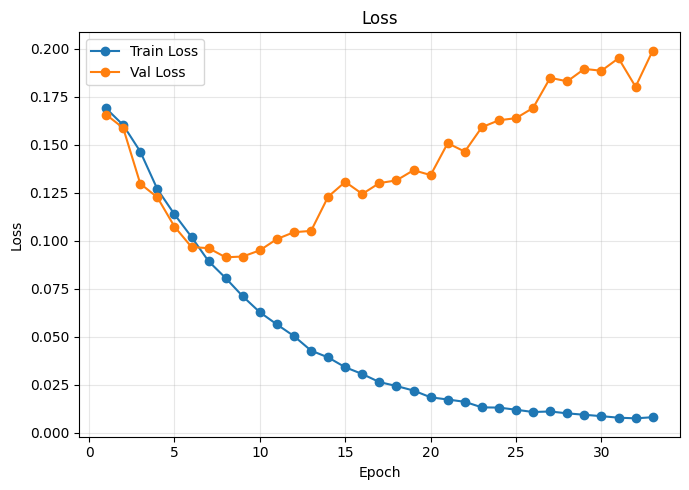

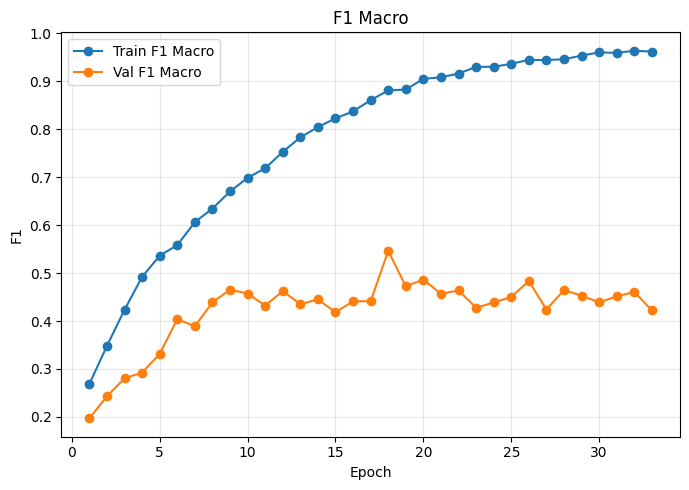

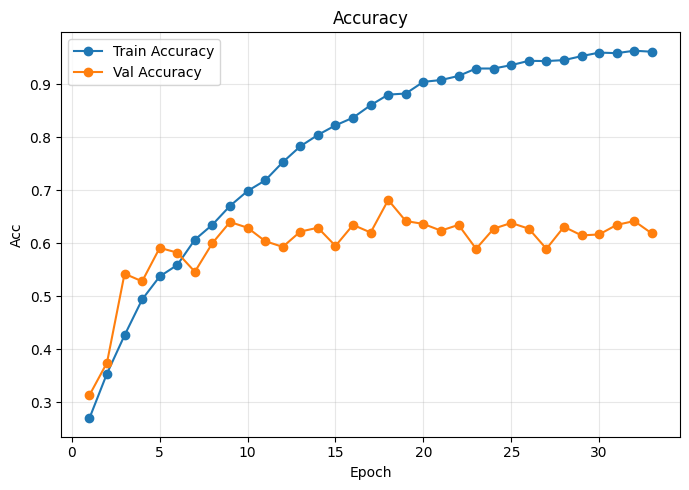

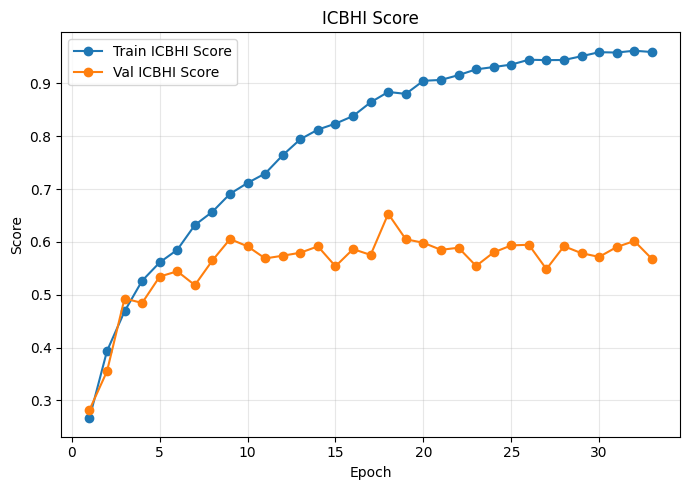

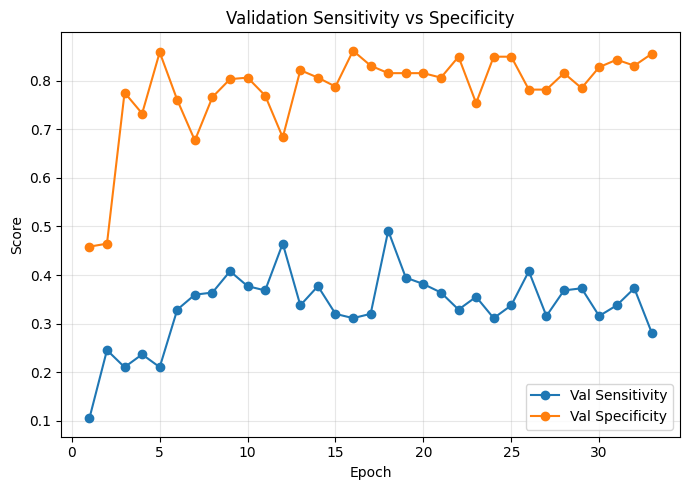


  EVALUASI 4 KELAS | EfficientNetV2-S | TEST
  ICBHI Sensitivity (Se) : 0.3189
  ICBHI Specificity (Sp) : 0.6916
  ICBHI Score            : 0.5053
  Harmonic Score         : 0.4365
  Accuracy               : 0.5285
  Precision Macro        : 0.4153
  Recall Macro           : 0.3827
  F1 Macro               : 0.3824
  F1 Weighted            : 0.5169
  AUC OVR Macro          : 0.6913

Classification Report:
              precision    recall  f1-score   support

      normal     0.6468    0.6916    0.6684      1628
     crackle     0.3561    0.4532    0.3989       620
      wheeze     0.4663    0.1871    0.2671       481
        both     0.1919    0.1988    0.1953       166

    accuracy                         0.5285      2895
   macro avg     0.4153    0.3827    0.3824      2895
weighted avg     0.5285    0.5285    0.5169      2895



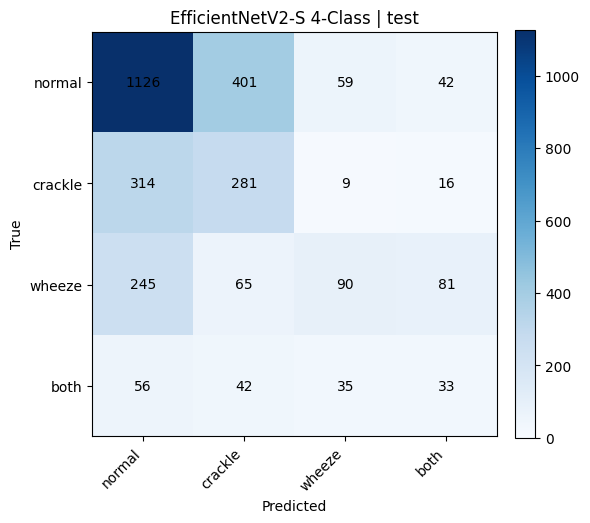

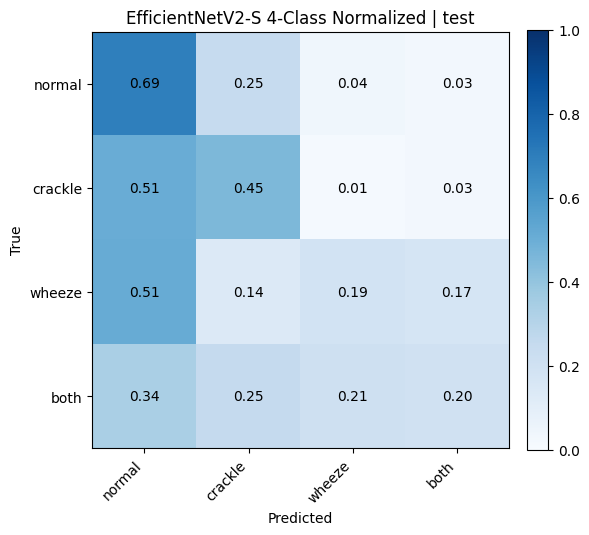


Threshold terbaik dari validation:
threshold    0.5100
Se           0.6535
Sp           0.8092
Score        0.7314
Harmonic     0.7231
Acc          0.7450

  EVALUASI BINARY | EfficientNetV2-S | TEST | best_se | t=0.51
  Sensitivity (Se)   : 0.5430
  Specificity (Sp)   : 0.6806
  Average Score      : 0.6118
  Harmonic Score     : 0.6041
  Accuracy           : 0.6204
  F1 Macro Binary    : 0.6122
  AUC Binary         : 0.6451

Classification Report (binary):
              precision    recall  f1-score   support

      normal     0.6568    0.6806    0.6685      1628
    abnormal     0.5695    0.5430    0.5560      1267

    accuracy                         0.6204      2895
   macro avg     0.6132    0.6118    0.6122      2895
weighted avg     0.6186    0.6204    0.6192      2895



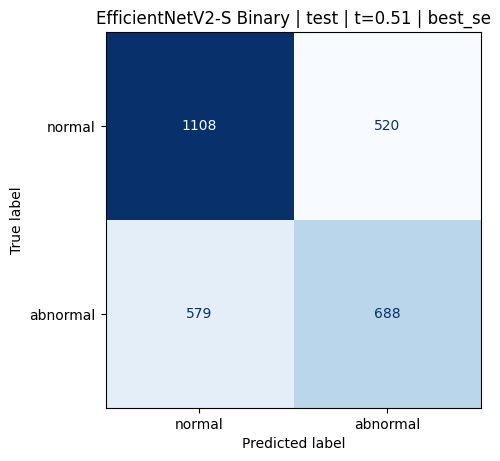

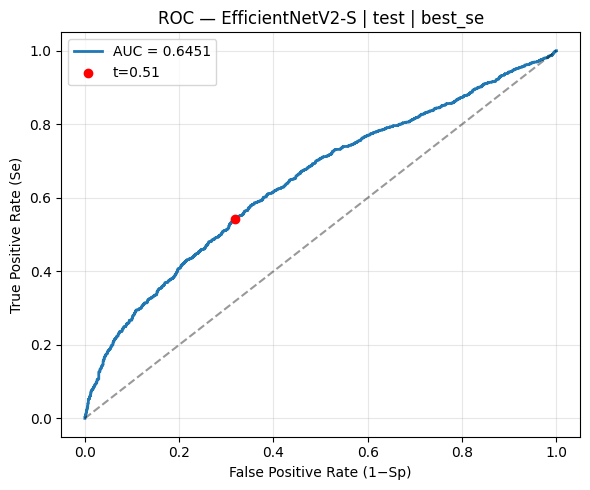


  RINGKASAN AKHIR — EFFICIENTNETV2-S | BEST_SE
  Threshold          : 0.51
  Binary Se / Sp / AS: 0.5430 / 0.6806 / 0.6118
  Binary Harmonic    : 0.6041
  Binary AUC         : 0.6451
  4-Class AS         : 0.5053
  4-Class AUC OVR    : 0.6913
  Result dir         : results_effnetv2s_4class/effnetv2s_4class_60_40_focal_partial_v5/eval_best_se_from_val/

  Alias siap untuk cell perbandingan:
    EFFNET_TEST_SE             = 0.5430
    EFFNET_TEST_SP             = 0.6806
    EFFNET_TEST_AVGSCORE       = 0.6118
    EFFNET_TEST_HARMONIC       = 0.6041
    EFFNET_TEST_AUC            = 0.6451
    EFFNET_TEST_THRESHOLD      = 0.51


In [ ]:
# =============================================================================
# CELL 36A — EVALUASI CONVNEXT-TINY | BEST_SE | THRESHOLD DARI VALIDATION
# =============================================================================
required_vars = [
    "model_convnext_4class",
    "val_loader_cn_4class",
    "test_loader_cn_4class",
    "DEVICE",
    "CLASS_NAMES_4CLASS",
    "MODEL_TAG_CONVNEXT_4CLASS",
    "CONVNEXT_HISTORY_PATH",
    "CONVNEXT_BEST_SE_MODEL_PATH",
    "SPLIT_SUFFIX",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"Variabel berikut belum ada. Jalankan Cell 34 dulu: {missing}")

RESULT_DIR_CN_BEST = os.path.join(
    "results_convnexttiny_4class",
    MODEL_TAG_CONVNEXT_4CLASS,
    "eval_best_se_from_val",
)
os.makedirs(RESULT_DIR_CN_BEST, exist_ok=True)

THRESHOLD_RANGE_CN = np.arange(0.10, 0.71, 0.01)

print("=" * 72)
print(f"  EVALUASI CONVNEXT-TINY | BEST_SE | {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)
print("  Threshold dipilih dari VALIDATION lalu diterapkan ke TEST")

_ = load_checkpoint_for_eval_generic(
    model_convnext_4class,
    CONVNEXT_BEST_SE_MODEL_PATH,
    DEVICE,
    label="best_se",
)

print("\n  Grafik training history...")
plot_training_history_eval(
    CONVNEXT_HISTORY_PATH,
    RESULT_DIR_CN_BEST,
    MODEL_TAG_CONVNEXT_4CLASS,
)

# Collect validation + test
y_true_4_val_cn, y_pred_4_val_cn, y_prob_4_val_cn, all_meta_val_cn = collect_outputs_generic(
    model_convnext_4class, val_loader_cn_4class, DEVICE
)
y_true_4_cn, y_pred_4_cn, y_prob_4_cn, all_meta_cn = collect_outputs_generic(
    model_convnext_4class, test_loader_cn_4class, DEVICE
)

# 4-class test
res_4_cn = evaluate_4class_generic(
    y_true_4_cn,
    y_pred_4_cn,
    y_prob_4_cn,
    all_meta_cn,
    split_name="test",
    class_names=CLASS_NAMES_4CLASS,
    result_dir=RESULT_DIR_CN_BEST,
    model_tag=MODEL_TAG_CONVNEXT_4CLASS,
    model_display_name="ConvNeXt-Tiny",
    cm_cmap="Oranges",
)

# choose threshold from validation
scan_val_cn, best_row_cn = choose_threshold_from_validation(
    y_true_4_val_cn,
    y_prob_4_val_cn,
    THRESHOLD_RANGE_CN,
)
scan_val_cn.to_csv(
    os.path.join(
        RESULT_DIR_CN_BEST,
        f"threshold_scan_val_{MODEL_TAG_CONVNEXT_4CLASS}_best_se.csv"
    ),
    index=False
)

print("\nThreshold terbaik dari validation:")
print(best_row_cn.to_string())

# apply to test
res_bin_cn = apply_binary_threshold_eval(
    y_true_4_cn,
    y_prob_4_cn,
    threshold=float(best_row_cn["threshold"]),
    split_name="test",
    result_dir=RESULT_DIR_CN_BEST,
    model_tag=MODEL_TAG_CONVNEXT_4CLASS,
    model_display_name="ConvNeXt-Tiny",
    mode_name="best_se",
    cm_cmap="Oranges",
)

print(f"\n{'='*72}")
print("  RINGKASAN AKHIR — CONVNEXT-TINY | BEST_SE")
print(f"{'='*72}")
print(f"  Threshold          : {res_bin_cn['best_threshold']:.2f}")
print(f"  Binary Se / Sp / AS: {res_bin_cn['best_se']:.4f} / {res_bin_cn['best_sp']:.4f} / {res_bin_cn['best_score']:.4f}")
print(f"  Binary Harmonic    : {res_bin_cn['best_harmonic']:.4f}")
print(f"  Binary AUC         : {res_bin_cn['auc_binary']:.4f}" if not np.isnan(res_bin_cn['auc_binary']) else "  Binary AUC         : nan")
print(f"  4-Class AS         : {res_4_cn['icbhi_score']:.4f}")
print(f"  4-Class AUC OVR    : {res_4_cn['auc_ovr_macro']:.4f}" if not np.isnan(res_4_cn['auc_ovr_macro']) else "  4-Class AUC OVR    : nan")
print(f"  Result dir         : {RESULT_DIR_CN_BEST}/")

# Alias untuk perbandingan utama
CONVNEXT_TEST_SE        = res_bin_cn["best_se"]
CONVNEXT_TEST_SP        = res_bin_cn["best_sp"]
CONVNEXT_TEST_AVGSCORE  = res_bin_cn["best_score"]
CONVNEXT_TEST_HARMONIC  = res_bin_cn["best_harmonic"]
CONVNEXT_TEST_AUC       = res_bin_cn["auc_binary"]
CONVNEXT_TEST_THRESHOLD = res_bin_cn["best_threshold"]

CONVNEXT_TEST_RECALL_NORMAL  = res_4_cn["recall_normal"]
CONVNEXT_TEST_RECALL_CRACKLE = res_4_cn["recall_crackle"]
CONVNEXT_TEST_RECALL_WHEEZE  = res_4_cn["recall_wheeze"]
CONVNEXT_TEST_RECALL_BOTH    = res_4_cn["recall_both"]

CONVNEXT_RESULT_DIR    = RESULT_DIR_CN_BEST
CONVNEXT_SUMMARY_ICBHI = res_4_cn["summary"]

print("\n  Alias siap untuk cell perbandingan:")
print(f"    CONVNEXT_TEST_SE             = {CONVNEXT_TEST_SE:.4f}")
print(f"    CONVNEXT_TEST_SP             = {CONVNEXT_TEST_SP:.4f}")
print(f"    CONVNEXT_TEST_AVGSCORE       = {CONVNEXT_TEST_AVGSCORE:.4f}")
print(f"    CONVNEXT_TEST_HARMONIC       = {CONVNEXT_TEST_HARMONIC:.4f}")
print(f"    CONVNEXT_TEST_AUC            = {CONVNEXT_TEST_AUC:.4f}" if not np.isnan(CONVNEXT_TEST_AUC) else "    CONVNEXT_TEST_AUC            = nan")
print(f"    CONVNEXT_TEST_THRESHOLD      = {CONVNEXT_TEST_THRESHOLD:.2f}")

# **Evaluasi Model EfficientNetV2-S**
> Fixed Threshold - 0.50

  EVALUASI EFFICIENTNETV2-S | BEST_SE | FIXED THRESHOLD 0.50 | 60:40

Checkpoint dimuat (best_se): checkpoints_effnetv2s_4class/effnetv2s_4class_60_40_focal_partial_v5/sensitivity_first/best_se_effnetv2s_4class_60_40_focal_partial_v5.pth
  Epoch      : 18
  Strategy   : best_val_sensitivity_tiebreak_abnmacro_score_sp_harm
  Val Score  : 0.653306342780027
  Val Se     : 0.49122807017543857
  Val Sp     : 0.8153846153846154

  EVALUASI 4 KELAS | EfficientNetV2-S | TEST_BESTSE_T050
  ICBHI Sensitivity (Se) : 0.3189
  ICBHI Specificity (Sp) : 0.6916
  ICBHI Score            : 0.5053
  Harmonic Score         : 0.4365
  Accuracy               : 0.5285
  Precision Macro        : 0.4153
  Recall Macro           : 0.3827
  F1 Macro               : 0.3824
  F1 Weighted            : 0.5169
  AUC OVR Macro          : 0.6913

Classification Report:
              precision    recall  f1-score   support

      normal     0.6468    0.6916    0.6684      1628
     crackle     0.3561    0.4532    0.3989

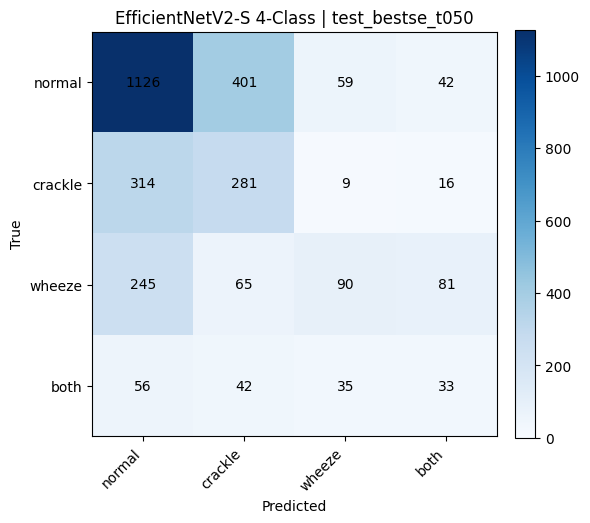

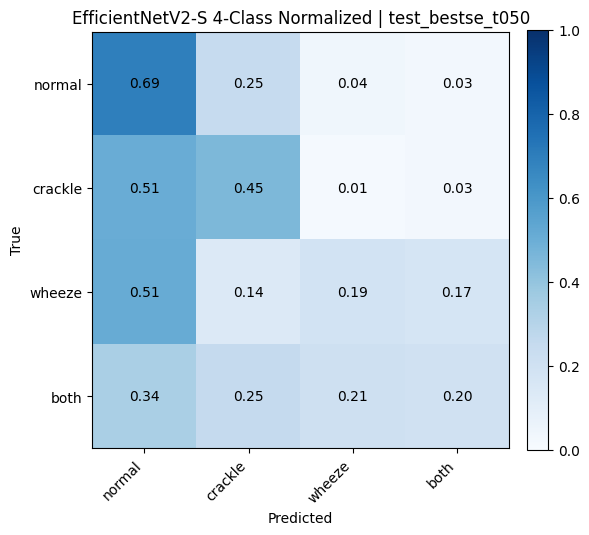


  EVALUASI BINARY | EfficientNetV2-S | TEST | best_se_fixed_050 | t=0.50
  Sensitivity (Se)   : 0.5549
  Specificity (Sp)   : 0.6646
  Average Score      : 0.6097
  Harmonic Score     : 0.6048
  Accuracy           : 0.6166
  F1 Macro Binary    : 0.6099
  AUC Binary         : 0.6451

Classification Report (binary):
              precision    recall  f1-score   support

      normal     0.6574    0.6646    0.6610      1628
    abnormal     0.5629    0.5549    0.5588      1267

    accuracy                         0.6166      2895
   macro avg     0.6101    0.6097    0.6099      2895
weighted avg     0.6160    0.6166    0.6163      2895



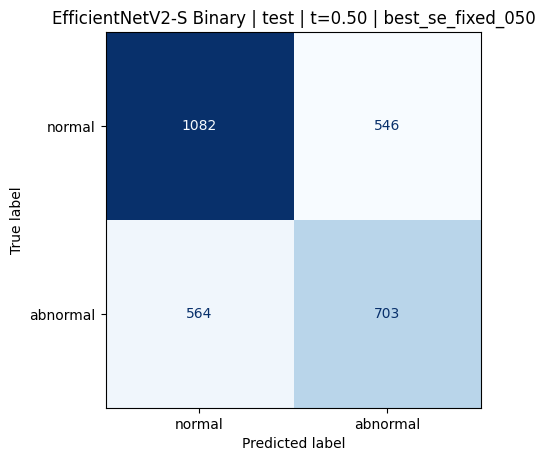

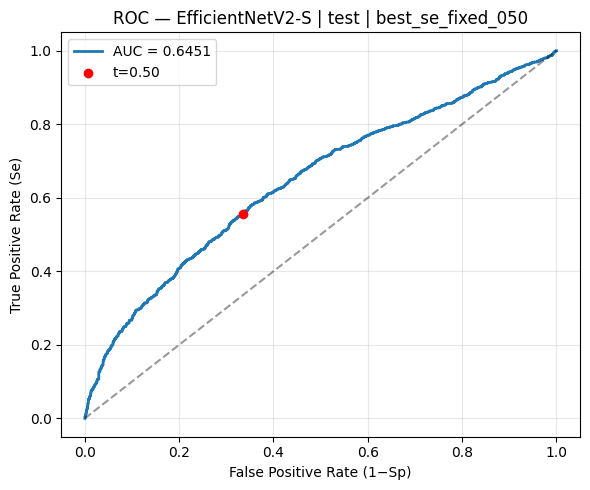


  RINGKASAN AKHIR — EFFICIENTNETV2-S | BEST_SE | FIXED 0.50
  Threshold          : 0.50
  Binary Se / Sp / AS: 0.5549 / 0.6646 / 0.6097
  Binary Harmonic    : 0.6048
  Binary AUC         : 0.6451
  4-Class AS         : 0.5053
  4-Class AUC OVR    : 0.6913
  Result dir         : results_effnetv2s_4class/effnetv2s_4class_60_40_focal_partial_v5/eval_best_se_threshold_050/

  Alias siap untuk cell perbandingan:
    EFFNET_BESTSE_T50_SE             = 0.5549
    EFFNET_BESTSE_T50_SP             = 0.6646
    EFFNET_BESTSE_T50_SCORE          = 0.6097
    EFFNET_BESTSE_T50_HARMONIC       = 0.6048
    EFFNET_BESTSE_T50_AUC            = 0.6451


In [ ]:
# =============================================================================
# CELL 36B — EVALUASI CONVNEXT-TINY | BEST_SE | FIXED THRESHOLD 0.50
# =============================================================================
required_vars = [
    "model_convnext_4class",
    "test_loader_cn_4class",
    "DEVICE",
    "CLASS_NAMES_4CLASS",
    "MODEL_TAG_CONVNEXT_4CLASS",
    "CONVNEXT_BEST_SE_MODEL_PATH",
    "SPLIT_SUFFIX",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"Variabel berikut belum ada. Jalankan Cell 34 dulu: {missing}")

FIXED_THRESHOLD_CN_BESTSE = 0.50
RESULT_DIR_CN_T50_BESTSE = os.path.join(
    "results_convnexttiny_4class",
    MODEL_TAG_CONVNEXT_4CLASS,
    "eval_best_se_threshold_050",
)
os.makedirs(RESULT_DIR_CN_T50_BESTSE, exist_ok=True)

print("=" * 72)
print(f"  EVALUASI CONVNEXT-TINY | BEST_SE | FIXED THRESHOLD {FIXED_THRESHOLD_CN_BESTSE:.2f} | {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)

# Selalu load checkpoint best_se agar tidak tercampur dengan checkpoint lain
_ = load_checkpoint_for_eval_generic(
    model_convnext_4class,
    CONVNEXT_BEST_SE_MODEL_PATH,
    DEVICE,
    label="best_se",
)

# Cache khusus best_se
y_true_4_cn_bestse_t50, y_pred_4_cn_bestse_t50, y_prob_4_cn_bestse_t50, all_meta_cn_bestse_t50 = collect_outputs_generic(
    model_convnext_4class, test_loader_cn_4class, DEVICE
)

res_4_cn_t50_bestse = evaluate_4class_generic(
    y_true_4_cn_bestse_t50,
    y_pred_4_cn_bestse_t50,
    y_prob_4_cn_bestse_t50,
    all_meta_cn_bestse_t50,
    split_name="test_bestse_t050",
    class_names=CLASS_NAMES_4CLASS,
    result_dir=RESULT_DIR_CN_T50_BESTSE,
    model_tag=MODEL_TAG_CONVNEXT_4CLASS,
    model_display_name="ConvNeXt-Tiny",
    cm_cmap="Oranges",
)

res_bin_cn_t50_bestse = apply_binary_threshold_eval(
    y_true_4_cn_bestse_t50,
    y_prob_4_cn_bestse_t50,
    threshold=FIXED_THRESHOLD_CN_BESTSE,
    split_name="test",
    result_dir=RESULT_DIR_CN_T50_BESTSE,
    model_tag=MODEL_TAG_CONVNEXT_4CLASS,
    model_display_name="ConvNeXt-Tiny",
    mode_name="best_se_fixed_050",
    cm_cmap="Oranges",
)

print(f"\n{'='*72}")
print("  RINGKASAN AKHIR — CONVNEXT-TINY | BEST_SE | FIXED 0.50")
print(f"{'='*72}")
print(f"  Threshold          : {FIXED_THRESHOLD_CN_BESTSE:.2f}")
print(f"  Binary Se / Sp / AS: {res_bin_cn_t50_bestse['best_se']:.4f} / {res_bin_cn_t50_bestse['best_sp']:.4f} / {res_bin_cn_t50_bestse['best_score']:.4f}")
print(f"  Binary Harmonic    : {res_bin_cn_t50_bestse['best_harmonic']:.4f}")
print(f"  Binary AUC         : {res_bin_cn_t50_bestse['auc_binary']:.4f}" if not np.isnan(res_bin_cn_t50_bestse['auc_binary']) else "  Binary AUC         : nan")
print(f"  4-Class AS         : {res_4_cn_t50_bestse['icbhi_score']:.4f}")
print(f"  4-Class AUC OVR    : {res_4_cn_t50_bestse['auc_ovr_macro']:.4f}" if not np.isnan(res_4_cn_t50_bestse['auc_ovr_macro']) else "  4-Class AUC OVR    : nan")
print(f"  Result dir         : {RESULT_DIR_CN_T50_BESTSE}/")

# Alias khusus best_se fixed 0.50
CONVNEXT_BESTSE_T50_SE       = res_bin_cn_t50_bestse["best_se"]
CONVNEXT_BESTSE_T50_SP       = res_bin_cn_t50_bestse["best_sp"]
CONVNEXT_BESTSE_T50_SCORE    = res_bin_cn_t50_bestse["best_score"]
CONVNEXT_BESTSE_T50_HARMONIC = res_bin_cn_t50_bestse["best_harmonic"]
CONVNEXT_BESTSE_T50_AUC      = res_bin_cn_t50_bestse["auc_binary"]

CONVNEXT_BESTSE_T50_RECALL_NORMAL  = res_4_cn_t50_bestse["recall_normal"]
CONVNEXT_BESTSE_T50_RECALL_CRACKLE = res_4_cn_t50_bestse["recall_crackle"]
CONVNEXT_BESTSE_T50_RECALL_WHEEZE  = res_4_cn_t50_bestse["recall_wheeze"]
CONVNEXT_BESTSE_T50_RECALL_BOTH    = res_4_cn_t50_bestse["recall_both"]

print("\n  Alias siap untuk cell perbandingan:")
print(f"    CONVNEXT_BESTSE_T50_SE             = {CONVNEXT_BESTSE_T50_SE:.4f}")
print(f"    CONVNEXT_BESTSE_T50_SP             = {CONVNEXT_BESTSE_T50_SP:.4f}")
print(f"    CONVNEXT_BESTSE_T50_SCORE          = {CONVNEXT_BESTSE_T50_SCORE:.4f}")
print(f"    CONVNEXT_BESTSE_T50_HARMONIC       = {CONVNEXT_BESTSE_T50_HARMONIC:.4f}")
print(f"    CONVNEXT_BESTSE_T50_AUC            = {CONVNEXT_BESTSE_T50_AUC:.4f}" if not np.isnan(CONVNEXT_BESTSE_T50_AUC) else "    CONVNEXT_BESTSE_T50_AUC            = nan")

# **ConvNeXt-Tiny**

# **Data Loader**

In [ ]:
# =============================================================================
# CELL 30 — DATA LOADER CONVNEXT-TINY
# =============================================================================
import os
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageFile
from torchvision import transforms
from torchvision.transforms import InterpolationMode

ImageFile.LOAD_TRUNCATED_IMAGES = True

# =========================
# 0. VALIDASI VARIABEL DARI CELL 19
# =========================
required_vars = [
    "TRAIN_IMG_META_PATH", "VAL_IMG_META_PATH",
    "TEST_IMG_META_PATH", "META_FEATURES_ROOT", "SPLIT_SUFFIX",
]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(
        f"Variabel berikut belum ada. Jalankan Cell 19 dulu: {missing_vars}"
    )

USE_VAL         = True
TRAIN_META_PATH = TRAIN_IMG_META_PATH
VAL_META_PATH   = VAL_IMG_META_PATH
TEST_META_PATH  = TEST_IMG_META_PATH

for p in [TRAIN_META_PATH, VAL_META_PATH, TEST_META_PATH]:
    assert os.path.exists(p), f"Metadata image tidak ditemukan: {p}"

print("=" * 72)
print(f"  DATALOADER CONVNEXT-TINY | split {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)
print(f"  Train meta : {TRAIN_META_PATH}")
print(f"  Val meta   : {VAL_META_PATH}")
print(f"  Test meta  : {TEST_META_PATH}")

# =========================
# 1. KONFIGURASI KELAS & INPUT
# =========================
NUM_CLASSES_4CLASS = 4
CLASS_NAMES_4CLASS = ["normal", "crackle", "wheeze", "both"]

NUM_CLASSES_BINARY = 2
CLASS_NAMES_BINARY = ["normal", "abnormal"]

# Harus sama dengan EfficientNet untuk evaluasi 2 kelas
COLLAPSE_MAP = torch.tensor([0, 1, 1, 1], dtype=torch.long)

# Fair comparison dengan EfficientNetV2-S
IMAGE_SIZE_CN = 384
BATCH_SIZE_CN = 16

CPU_COUNT_CN = os.cpu_count() or 2
NUM_WORKERS_CN = min(4, max(2, CPU_COUNT_CN // 2))
PIN_MEMORY_CN = torch.cuda.is_available()
PERSISTENT_CN = NUM_WORKERS_CN > 0
PREFETCH_FACTOR_CN = 2 if NUM_WORKERS_CN > 0 else None

# Fair comparison: CBS dimatikan
ENABLE_CBS_CN = False
CBS_TARGET_MODE_CN = "disabled"

# SpecAugment harus sama dengan EfficientNet
FREQ_MASK_PARAM = 8
TIME_MASK_PARAM = 20

# Reproducibility
LOADER_SEED_CN = 42

# =========================
# 2. LOAD & BERSIHKAN METADATA
# =========================
train_img_df_cn = pd.read_csv(TRAIN_META_PATH).copy()
val_img_df_cn   = pd.read_csv(VAL_META_PATH).copy()
test_img_df_cn  = pd.read_csv(TEST_META_PATH).copy()

def clean_image_metadata_cn(df_name, df, expected_split):
    df = df.copy()

    required_cols = [
        "image_path", "split",
        "label_4class", "label_name_4class",
        "label_2class", "label_name_2class",
    ]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise AssertionError(f"{df_name}: kolom wajib tidak ada: {missing_cols}")

    df["split"]             = df["split"].astype(str).str.strip().str.lower()
    df["label_4class"]      = df["label_4class"].astype(int)
    df["label_2class"]      = df["label_2class"].astype(int)
    df["label_name_4class"] = df["label_name_4class"].astype(str).str.strip().str.lower()
    df["label_name_2class"] = df["label_name_2class"].astype(str).str.strip().str.lower()

    if "image_ok" in df.columns:
        df = df[df["image_ok"] == 1].reset_index(drop=True)

    df = df[df["image_path"].notna()].reset_index(drop=True)
    df = df[df["image_path"].astype(str).str.lower() != "nan"].reset_index(drop=True)

    exists_mask = df["image_path"].apply(os.path.exists)
    n_missing = int((~exists_mask).sum())
    if n_missing > 0:
        print(f"  [{df_name}] image hilang di disk: {n_missing} -> dilewati")
        df = df[exists_mask].reset_index(drop=True)

    df = df[df["label_4class"].isin([0, 1, 2, 3])].reset_index(drop=True)
    df = df[df["label_name_4class"].isin(CLASS_NAMES_4CLASS)].reset_index(drop=True)
    df = df[df["label_2class"].isin([0, 1])].reset_index(drop=True)
    df = df[df["label_name_2class"].isin(CLASS_NAMES_BINARY)].reset_index(drop=True)

    bad_split = df[df["split"] != expected_split]
    if len(bad_split) > 0:
        raise AssertionError(
            f"{df_name}: ditemukan split selain '{expected_split}'. Pipeline belum sinkron."
        )

    return df.reset_index(drop=True)

train_img_df_cn = clean_image_metadata_cn("train", train_img_df_cn, "train")
val_img_df_cn   = clean_image_metadata_cn("val", val_img_df_cn, "val")
test_img_df_cn  = clean_image_metadata_cn("test", test_img_df_cn, "test")

assert len(train_img_df_cn) > 0, "train_img_df_cn kosong"
assert len(val_img_df_cn) > 0, "val_img_df_cn kosong"
assert len(test_img_df_cn) > 0, "test_img_df_cn kosong"

# Sanity check — tidak ada overlap pasien
if all("patient_id" in df.columns for df in [train_img_df_cn, val_img_df_cn, test_img_df_cn]):
    train_pat = set(train_img_df_cn["patient_id"].dropna().astype(int))
    val_pat   = set(val_img_df_cn["patient_id"].dropna().astype(int))
    test_pat  = set(test_img_df_cn["patient_id"].dropna().astype(int))
    assert not (train_pat & val_pat), "Overlap pasien train-val!"
    assert not (train_pat & test_pat), "Overlap pasien train-test!"
    assert not (val_pat & test_pat), "Overlap pasien val-test!"

n_train_pat = train_img_df_cn["patient_id"].nunique() if "patient_id" in train_img_df_cn.columns else "n/a"
n_val_pat   = val_img_df_cn["patient_id"].nunique() if "patient_id" in val_img_df_cn.columns else "n/a"
n_test_pat  = test_img_df_cn["patient_id"].nunique() if "patient_id" in test_img_df_cn.columns else "n/a"

print(f"\n  Train : {len(train_img_df_cn)} sampel | {n_train_pat} pasien")
print(f"  Val   : {len(val_img_df_cn)} sampel | {n_val_pat} pasien")
print(f"  Test  : {len(test_img_df_cn)} sampel | {n_test_pat} pasien")

print(f"\n  Distribusi 4 kelas train:")
print(train_img_df_cn["label_name_4class"].value_counts().reindex(CLASS_NAMES_4CLASS, fill_value=0))
print(f"\n  Distribusi 4 kelas val:")
print(val_img_df_cn["label_name_4class"].value_counts().reindex(CLASS_NAMES_4CLASS, fill_value=0))
print(f"\n  Distribusi 4 kelas test:")
print(test_img_df_cn["label_name_4class"].value_counts().reindex(CLASS_NAMES_4CLASS, fill_value=0))
print(f"\n  Distribusi 2 kelas train:")
print(train_img_df_cn["label_name_2class"].value_counts().reindex(CLASS_NAMES_BINARY, fill_value=0))

# =========================
# 3. STATISTIK NORMALISASI
#    Reuse dari EfficientNet agar fair
# =========================
def safe_open_rgb_cn(path):
    with Image.open(path) as img:
        return img.convert("RGB").copy()

def compute_image_stats_cn(img_paths, sample_size=800, seed=42):
    if len(img_paths) == 0:
        raise RuntimeError("img_paths kosong.")

    rng = random.Random(seed)
    sampled = rng.sample(img_paths, min(sample_size, len(img_paths)))

    to_tensor = transforms.ToTensor()
    means, stds = [], []

    for p in sampled:
        try:
            img = safe_open_rgb_cn(p)
            t = to_tensor(img)
            means.append(t.mean(dim=[1, 2]))
            stds.append(t.std(dim=[1, 2]))
        except Exception:
            continue

    if not means:
        raise RuntimeError("Semua gambar gagal dimuat saat hitung statistik.")

    mean = torch.stack(means).mean(dim=0).tolist()
    std = [max(s, 1e-6) for s in torch.stack(stds).mean(dim=0).tolist()]
    return mean, std

if "LOGMEL_MEAN" in globals() and "LOGMEL_STD" in globals():
    print("\n  Menggunakan LOGMEL_MEAN & LOGMEL_STD dari loader EfficientNet (konsisten).")
else:
    print("\n  LOGMEL_MEAN/STD belum ada, menghitung dari train...")
    LOGMEL_MEAN, LOGMEL_STD = compute_image_stats_cn(
        train_img_df_cn["image_path"].tolist(),
        sample_size=800,
        seed=LOADER_SEED_CN,
    )

print(f"  mean : {[round(m, 4) for m in LOGMEL_MEAN]}")
print(f"  std  : {[round(s, 4) for s in LOGMEL_STD]}")

# =========================
# 4. SPECAUGMENT — FreqTimeMask
# =========================
class FreqTimeMask:
    """
    SpecAugment pada tensor [C, H, W].
    Frequency mask pada sumbu H, time mask pada sumbu W.
    """
    def __init__(self, freq_mask=8, time_mask=20):
        self.freq_mask = int(freq_mask)
        self.time_mask = int(time_mask)

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        x = x.clone()
        _, H, W = x.shape

        f = np.random.randint(0, self.freq_mask + 1)
        if f > 0:
            f0 = np.random.randint(0, max(H - f + 1, 1))
            x[:, f0:f0 + f, :] = 0.0

        t = np.random.randint(0, self.time_mask + 1)
        if t > 0:
            t0 = np.random.randint(0, max(W - t + 1, 1))
            x[:, :, t0:t0 + t] = 0.0

        return x

# =========================
# 5. TRANSFORM
# =========================
train_transform_cn = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE_CN, IMAGE_SIZE_CN),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=LOGMEL_MEAN, std=LOGMEL_STD),
    FreqTimeMask(freq_mask=FREQ_MASK_PARAM, time_mask=TIME_MASK_PARAM),
])

eval_transform_cn = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE_CN, IMAGE_SIZE_CN),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=LOGMEL_MEAN, std=LOGMEL_STD),
])

print(f"\n  Transform train : Resize({IMAGE_SIZE_CN}) -> ToTensor -> Normalize -> FreqTimeMask(f={FREQ_MASK_PARAM}, t={TIME_MASK_PARAM})")
print(f"  Transform eval  : Resize({IMAGE_SIZE_CN}) -> ToTensor -> Normalize")

# =========================
# 6. DATASET CLASS
# =========================
class Respiratory4ClassDataset_CN(Dataset):
    def __init__(self, df, transform=None, return_meta=False):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = str(row["image_path"])

        if (not image_path) or (image_path.lower() == "nan") or (not os.path.exists(image_path)):
            raise FileNotFoundError(f"Image tidak ditemukan: {image_path}")

        try:
            img = safe_open_rgb_cn(image_path)
        except Exception as e:
            raise RuntimeError(f"Gagal membuka image: {image_path} | {e}")

        x = self.transform(img) if self.transform is not None else transforms.ToTensor()(img)
        y = torch.tensor(int(row["label_4class"]), dtype=torch.long)

        if self.return_meta:
            meta = {
                "cycle_id": str(row["cycle_id"]) if "cycle_id" in row.index else f"sample_{idx}",
                "patient_id": int(row["patient_id"]) if "patient_id" in row.index and pd.notna(row["patient_id"]) else -1,
                "label_4class": int(row["label_4class"]),
                "label_name_4class": str(row["label_name_4class"]),
                "label_2class": int(row["label_2class"]),
                "label_name_2class": str(row["label_name_2class"]),
                "image_path": image_path,
                "split": str(row["split"]),
                "is_augmented": int(row["is_augmented"]) if "is_augmented" in row.index and pd.notna(row["is_augmented"]) else 0,
                "aug_type": str(row["aug_type"]) if "aug_type" in row.index and pd.notna(row["aug_type"]) else "none",
                "aug_source": str(row["aug_source"]) if "aug_source" in row.index and pd.notna(row["aug_source"]) else "original",
            }
            return x, y, meta

        return x, y

# =========================
# 7. BUAT DATASET
# =========================
train_ds_cn = Respiratory4ClassDataset_CN(
    train_img_df_cn, transform=train_transform_cn, return_meta=False
)
val_ds_cn = Respiratory4ClassDataset_CN(
    val_img_df_cn, transform=eval_transform_cn, return_meta=True
)
test_ds_cn = Respiratory4ClassDataset_CN(
    test_img_df_cn, transform=eval_transform_cn, return_meta=True
)

# =========================
# 8. DATALOADER
# =========================
def seed_worker_cn(worker_id):
    worker_seed = LOADER_SEED_CN + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g_cn = torch.Generator()
g_cn.manual_seed(LOADER_SEED_CN)

loader_common_kwargs_cn = dict(
    num_workers=NUM_WORKERS_CN,
    pin_memory=PIN_MEMORY_CN,
    persistent_workers=PERSISTENT_CN,
    worker_init_fn=seed_worker_cn if NUM_WORKERS_CN > 0 else None,
    generator=g_cn,
)

if NUM_WORKERS_CN > 0:
    loader_common_kwargs_cn["prefetch_factor"] = PREFETCH_FACTOR_CN

train_loader_cn = DataLoader(
    train_ds_cn,
    batch_size=BATCH_SIZE_CN,
    sampler=None,
    shuffle=True,
    drop_last=True,
    **loader_common_kwargs_cn,
)

val_loader_cn = DataLoader(
    val_ds_cn,
    batch_size=BATCH_SIZE_CN,
    shuffle=False,
    drop_last=False,
    **loader_common_kwargs_cn,
)

test_loader_cn = DataLoader(
    test_ds_cn,
    batch_size=BATCH_SIZE_CN,
    shuffle=False,
    drop_last=False,
    **loader_common_kwargs_cn,
)

# =========================
# 9. SANITY CHECK
# =========================
batch = next(iter(train_loader_cn))
xb, yb = batch[0], batch[1]
unique_lbl, cnt_lbl = torch.unique(yb, sorted=True, return_counts=True)

print(f"\n  Sanity check ConvNeXt-Tiny dataloader:")
print(f"  X shape  : {xb.shape}")
print(f"  Y shape  : {yb.shape}")
print(f"  X min/max: {xb.min():.3f} / {xb.max():.3f}")
print(f"  Distribusi label di 1 batch:")
for lbl, cnt in zip(unique_lbl.tolist(), cnt_lbl.tolist()):
    print(f"    {lbl} ({CLASS_NAMES_4CLASS[lbl]:8s}): {cnt:2d}  {'█' * cnt}")

print(f"\n  Train batches : {len(train_loader_cn)} ({len(train_ds_cn)} sampel)")
print(f"  Val batches   : {len(val_loader_cn)}")
print(f"  Test batches  : {len(test_loader_cn)}")

# =========================
# 10. ALIAS UNTUK CELL MODEL CONVNEXT
# =========================
train_loader_cn_4class = train_loader_cn
val_loader_cn_4class   = val_loader_cn
test_loader_cn_4class  = test_loader_cn
val_loader_eval_cn     = val_loader_cn

train_img_df_4class_cn = train_img_df_cn
val_img_df_4class_cn   = val_img_df_cn
test_img_df_4class_cn  = test_img_df_cn

print(f"\n{'='*72}")
print(f"  RINGKASAN DATALOADER CONVNEXT-TINY")
print(f"{'='*72}")
print(f"  SpecAugment train  : AKTIF — FreqTimeMask(f={FREQ_MASK_PARAM}, t={TIME_MASK_PARAM})")
print(f"  SpecAugment val    : tidak aktif")
print(f"  CBS                : {ENABLE_CBS_CN}")
print(f"  Batch size         : {BATCH_SIZE_CN}")
print(f"  Image size         : {IMAGE_SIZE_CN}x{IMAGE_SIZE_CN}")
print(f"  Num workers        : {NUM_WORKERS_CN}")
print(f"  Prefetch factor    : {PREFETCH_FACTOR_CN if NUM_WORKERS_CN > 0 else 'n/a'}")
print(f"  Drop last train    : True")
print(f"  Normalisasi mean   : {[round(m, 4) for m in LOGMEL_MEAN]}")
print(f"  Normalisasi std    : {[round(s, 4) for s in LOGMEL_STD]}")
print(f"\n  Alias siap untuk Cell model ConvNeXt:")
print(f"    train_loader_cn_4class  -> {len(train_loader_cn_4class)} batches")
print(f"    val_loader_cn_4class    -> {len(val_loader_cn_4class)} batches")
print(f"    test_loader_cn_4class   -> {len(test_loader_cn_4class)} batches")
print(f"    train_img_df_4class_cn  -> {len(train_img_df_4class_cn)} sampel")
print(f"    COLLAPSE_MAP            -> {COLLAPSE_MAP.tolist()}")

  DATALOADER CONVNEXT-TINY | split 60:40
  Train meta : metadata_features_4class_60_40/metadata_lmimg_train_4class.csv
  Val meta   : metadata_features_4class_60_40/metadata_lmimg_val_4class.csv
  Test meta  : metadata_features_4class_60_40/metadata_lmimg_test_4class.csv

  Train : 6756 sampel | 60 pasien
  Val   : 553 sampel | 15 pasien
  Test  : 2895 sampel | 51 pasien

  Distribusi 4 kelas train:
label_name_4class
normal     1689
crackle    1689
wheeze     1689
both       1689
Name: count, dtype: int64

  Distribusi 4 kelas val:
label_name_4class
normal     325
crackle    114
wheeze      72
both        42
Name: count, dtype: int64

  Distribusi 4 kelas test:
label_name_4class
normal     1628
crackle     620
wheeze      481
both        166
Name: count, dtype: int64

  Distribusi 2 kelas train:
label_name_2class
normal      1689
abnormal    5067
Name: count, dtype: int64

  Menggunakan LOGMEL_MEAN & LOGMEL_STD dari loader EfficientNet (konsisten).
  mean : [0.2773, 0.4896, 0.4015]
  s

# **Setup & Define ConvNext-Tiny**

In [ ]:
# =============================================================================
# CELL 32 — SETUP & KONFIGURASI MODEL CONVNEXT-TINY  [FINAL]
# =============================================================================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torchvision.models import ConvNeXt_Tiny_Weights
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

required_vars = ["SPLIT_SUFFIX"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise NameError(f"Variabel berikut belum ada. Jalankan Cell 12 dulu: {missing_vars}")

required_globals = [
    "train_loader_cn_4class", "val_loader_cn_4class", "test_loader_cn_4class",
    "train_img_df_4class_cn", "val_img_df_4class_cn", "test_img_df_4class_cn",
    "COLLAPSE_MAP",
]
missing_globals = [v for v in required_globals if v not in globals()]
if missing_globals:
    raise NameError(f"Variabel berikut belum ada. Jalankan Cell 30 dulu: {missing_globals}")

# =========================
# 1. KONFIGURASI — FINAL
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES_4CLASS = 4
CLASS_NAMES_4CLASS = ["normal", "crackle", "wheeze", "both"]
NUM_CLASSES_BINARY = 2
CLASS_NAMES_BINARY = ["normal", "abnormal"]

# ── Optimizer ──────────────────────────────────────────────
# Disamakan dengan EfficientNet untuk fair comparison
LR_CONVNEXT_4CLASS           = 3e-4
LR_BACKBONE_RATIO_CONVNEXT   = 0.05
WEIGHT_DECAY_CONVNEXT_4CLASS = 2e-2
NUM_EPOCHS_CONVNEXT_4CLASS   = 50
DROPOUT_P_CONVNEXT_4CLASS    = 0.50
WARMUP_EPOCHS_CONVNEXT       = 5

# ── Focal Loss ─────────────────────────────────────────────
ALPHA_POWER_CN     = 0.75
GAMMA_FL_CN        = 2.5
LABEL_SMOOTH_FL_CN = 0.05

# ── Fine-tuning ────────────────────────────────────────────
FINETUNE_MODE_CONVNEXT = "partial"

MODEL_TAG_CONVNEXT_4CLASS = f"convnexttiny_4class_{SPLIT_SUFFIX}_focal_partial_v5"

print("=" * 72)
print(f"  SETUP CONVNEXT-TINY — FINAL | {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)
print(f"  Device              : {DEVICE}")
print(f"  Model tag           : {MODEL_TAG_CONVNEXT_4CLASS}")
print(f"  Epochs              : {NUM_EPOCHS_CONVNEXT_4CLASS} (warmup {WARMUP_EPOCHS_CONVNEXT} ep)")
print(f"  LR head             : {LR_CONVNEXT_4CLASS:.1e}")
print(f"  LR backbone         : {LR_CONVNEXT_4CLASS * LR_BACKBONE_RATIO_CONVNEXT:.2e}")
print(f"  Weight decay        : {WEIGHT_DECAY_CONVNEXT_4CLASS:.2e}")
print(f"  Dropout             : {DROPOUT_P_CONVNEXT_4CLASS}")
print(f"  Alpha power         : {ALPHA_POWER_CN}")
print(f"  Focal gamma         : {GAMMA_FL_CN}")
print(f"  Label smoothing     : {LABEL_SMOOTH_FL_CN}")
print(f"  Fine-tuning mode    : {FINETUNE_MODE_CONVNEXT}")

# =========================
# 2. VALIDASI DATAFRAME
# =========================
required_train_cols = [
    "label_4class", "label_name_4class",
    "label_2class", "label_name_2class",
]
missing_cols = [c for c in required_train_cols if c not in train_img_df_4class_cn.columns]
if missing_cols:
    raise AssertionError(f"Kolom wajib tidak ada: {missing_cols}")

assert len(train_img_df_4class_cn) > 0, "train_img_df_4class_cn kosong."
assert len(val_img_df_4class_cn)   > 0, "val_img_df_4class_cn kosong."
assert len(test_img_df_4class_cn)  > 0, "test_img_df_4class_cn kosong."

# =========================
# 3. DISTRIBUSI KELAS
# =========================
counts_cn = (
    train_img_df_4class_cn["label_4class"]
    .value_counts()
    .sort_index()
    .reindex(range(NUM_CLASSES_4CLASS), fill_value=1)
)

print(f"\n  Distribusi 4 kelas train:")
for i, n in counts_cn.items():
    print(f"    {i} ({CLASS_NAMES_4CLASS[i]:8s}): {n}")

print(f"\n  Distribusi 4 kelas val:")
print(val_img_df_4class_cn["label_name_4class"]
      .value_counts().reindex(CLASS_NAMES_4CLASS, fill_value=0))

print(f"\n  Distribusi 4 kelas test:")
print(test_img_df_4class_cn["label_name_4class"]
      .value_counts().reindex(CLASS_NAMES_4CLASS, fill_value=0))

print(f"\n  Distribusi 2 kelas test:")
print(test_img_df_4class_cn["label_name_2class"]
      .value_counts().reindex(CLASS_NAMES_BINARY, fill_value=0))

# =========================
# 4. FOCAL LOSS
# =========================
class FocalLoss(nn.Module):
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.5,
                 label_smoothing: float = 0.05):
        super().__init__()
        self.register_buffer("alpha", alpha)
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        num_classes = logits.size(1)
        logits = torch.clamp(logits, -20.0, 20.0)

        if self.label_smoothing > 0:
            smooth_value = self.label_smoothing / num_classes
            soft_targets = torch.full_like(logits, smooth_value)
            soft_targets.scatter_(
                1, targets.unsqueeze(1),
                1.0 - self.label_smoothing + smooth_value
            )
            log_prob = torch.clamp(F.log_softmax(logits, dim=1), -100.0, 0.0)
            ce = -(soft_targets * log_prob).sum(dim=1)
        else:
            ce = F.cross_entropy(logits, targets, reduction="none")

        pt = F.softmax(logits, dim=1).gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = torch.clamp(pt, 1e-7, 1.0)

        loss = (self.alpha.gather(0, targets) * ((1 - pt) ** self.gamma) * ce).mean()

        if torch.isnan(loss) or torch.isinf(loss):
            return torch.tensor(0.1, device=logits.device, requires_grad=True)
        return loss

def compute_focal_alpha(counts_series, power=0.75, device="cpu"):
    counts_series = counts_series.reindex(range(len(counts_series)), fill_value=1)
    n_max = float(counts_series.max())
    raw   = [(n_max / max(float(n), 1.0)) ** power for n in counts_series.values]
    total = sum(raw)
    norm  = [r / total for r in raw]
    return torch.tensor(norm, dtype=torch.float32, device=device)

class_weights_cn = compute_focal_alpha(counts_cn, power=ALPHA_POWER_CN, device=DEVICE)
wcn = class_weights_cn.detach().cpu().tolist()

criterion_convnext_4class = FocalLoss(
    alpha=class_weights_cn,
    gamma=GAMMA_FL_CN,
    label_smoothing=LABEL_SMOOTH_FL_CN,
)

print(f"\n{'='*72}")
print(f"  Focal Loss alpha (ALPHA_POWER={ALPHA_POWER_CN})")
print(f"{'='*72}")
for i in range(NUM_CLASSES_4CLASS):
    print(f"  {CLASS_NAMES_4CLASS[i]:8s} -> alpha = {wcn[i]:.4f}")
print(f"  Rasio abnormal/normal = {wcn[1]/wcn[0]:.3f}x")

# =========================
# 5. ARSITEKTUR — PARTIAL FINE-TUNING
# =========================
weights_cn = ConvNeXt_Tiny_Weights.DEFAULT
model_convnext_4class = models.convnext_tiny(weights=weights_cn)

# Simpan dua modul awal classifier bawaan agar alur asli ConvNeXt tetap aman
orig_classifier = model_convnext_4class.classifier
if len(orig_classifier) < 3:
    raise RuntimeError("Struktur classifier ConvNeXt-Tiny tidak sesuai ekspektasi torchvision.")

in_features_cn = orig_classifier[-1].in_features
model_convnext_4class.classifier = nn.Sequential(
    orig_classifier[0],
    orig_classifier[1],
    nn.Dropout(p=DROPOUT_P_CONVNEXT_4CLASS, inplace=True),
    nn.Linear(in_features_cn, NUM_CLASSES_4CLASS),
)

# Freeze semua dulu
for param in model_convnext_4class.parameters():
    param.requires_grad = False

# Unfreeze stage akhir ConvNeXt + classifier
# Struktur ConvNeXt torchvision umumnya:
# features.0 stem
# features.1 stage1
# features.2 downsample
# features.3 stage2
# features.4 downsample
# features.5 stage3
# features.6 downsample
# features.7 stage4
UNFREEZE_LAYERS_CN = [
    "features.5",
    "features.6",
    "features.7",
    "classifier",
]

for name, param in model_convnext_4class.named_parameters():
    if any(k in name for k in UNFREEZE_LAYERS_CN):
        param.requires_grad = True

model_convnext_4class = model_convnext_4class.to(DEVICE)

n_total_cn = sum(p.numel() for p in model_convnext_4class.parameters())
n_trainable_cn = sum(
    p.numel() for p in model_convnext_4class.parameters() if p.requires_grad
)

print(f"\n  Fine-tuning    : {FINETUNE_MODE_CONVNEXT} — {UNFREEZE_LAYERS_CN}")
print(f"  Total params   : {n_total_cn:,}")
print(f"  Trainable      : {n_trainable_cn:,} ({100*n_trainable_cn/n_total_cn:.1f}%)")

# =========================
# 6. OPTIMIZER — LAYER-WISE LR
# =========================
backbone_p_cn = [p for n, p in model_convnext_4class.named_parameters()
                 if p.requires_grad and "classifier" not in n]
head_p_cn     = [p for n, p in model_convnext_4class.named_parameters()
                 if p.requires_grad and "classifier" in n]

optimizer_convnext_4class = torch.optim.AdamW(
    [
        {"params": backbone_p_cn, "lr": LR_CONVNEXT_4CLASS * LR_BACKBONE_RATIO_CONVNEXT},
        {"params": head_p_cn,     "lr": LR_CONVNEXT_4CLASS},
    ],
    weight_decay=WEIGHT_DECAY_CONVNEXT_4CLASS,
)

print(f"\n  Optimizer : AdamW (layer-wise LR)")
print(f"    Backbone : {LR_CONVNEXT_4CLASS * LR_BACKBONE_RATIO_CONVNEXT:.2e}"
      f" ({sum(p.numel() for p in backbone_p_cn):,} params)")
print(f"    Head     : {LR_CONVNEXT_4CLASS:.2e}"
      f" ({sum(p.numel() for p in head_p_cn):,} params)")
print(f"    WD       : {WEIGHT_DECAY_CONVNEXT_4CLASS:.2e}")

# =========================
# 7. SCHEDULER — WARMUP + COSINE
# =========================
warmup_sched_cn = LinearLR(
    optimizer_convnext_4class,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS_CONVNEXT,
)
cosine_sched_cn = CosineAnnealingLR(
    optimizer_convnext_4class,
    T_max=NUM_EPOCHS_CONVNEXT_4CLASS - WARMUP_EPOCHS_CONVNEXT,
    eta_min=1e-6,
)
scheduler_convnext_4class = SequentialLR(
    optimizer_convnext_4class,
    schedulers=[warmup_sched_cn, cosine_sched_cn],
    milestones=[WARMUP_EPOCHS_CONVNEXT],
)

print(f"\n  Scheduler : LinearLR warmup({WARMUP_EPOCHS_CONVNEXT}ep) → CosineAnnealingLR")
print(f"    T_max={NUM_EPOCHS_CONVNEXT_4CLASS - WARMUP_EPOCHS_CONVNEXT}, eta_min=1e-6")

# =========================
# 8. SANITY CHECK
# =========================
_batch = next(iter(train_loader_cn_4class))
xb = _batch[0] if isinstance(_batch, (list, tuple)) else _batch
yb = _batch[1] if isinstance(_batch, (list, tuple)) else None

with torch.no_grad():
    out_cn = model_convnext_4class(xb.to(DEVICE))
    loss_check_cn = criterion_convnext_4class(out_cn, yb.to(DEVICE))

print(f"\n  Sanity check:")
print(f"    Input  : {xb.shape}")
print(f"    Output : {out_cn.shape}")
print(f"    Loss   : {float(loss_check_cn):.4f}")

# =========================
# 9. ALIAS
# =========================
print(f"\n{'='*72}")
print(f"  ConvNeXt-Tiny FINAL siap")
print(f"{'='*72}")
print(f"  Alpha  : {[round(w,4) for w in wcn]}")
print(f"  Rasio  : {wcn[1]/wcn[0]:.3f}x  (abnormal/normal)")
print(f"\n  Variabel siap untuk Cell training ConvNeXt:")
print(f"    model_convnext_4class       → ConvNeXt-Tiny")
print(f"    criterion_convnext_4class   → FocalLoss")
print(f"    optimizer_convnext_4class   → AdamW")
print(f"    scheduler_convnext_4class   → Warmup+Cosine")
print(f"    NUM_EPOCHS_CONVNEXT_4CLASS  = {NUM_EPOCHS_CONVNEXT_4CLASS}")
print(f"    MODEL_TAG_CONVNEXT_4CLASS   = '{MODEL_TAG_CONVNEXT_4CLASS}'")
print(f"    WARMUP_EPOCHS_CONVNEXT      = {WARMUP_EPOCHS_CONVNEXT}")

  SETUP CONVNEXT-TINY — FINAL | 60:40
  Device              : cuda
  Model tag           : convnexttiny_4class_60_40_focal_partial_v5
  Epochs              : 50 (warmup 5 ep)
  LR head             : 3.0e-04
  LR backbone         : 1.50e-05
  Weight decay        : 2.00e-02
  Dropout             : 0.5
  Alpha power         : 0.75
  Focal gamma         : 2.5
  Label smoothing     : 0.05
  Fine-tuning mode    : partial

  Distribusi 4 kelas train:
    0 (normal  ): 1689
    1 (crackle ): 1689
    2 (wheeze  ): 1689
    3 (both    ): 1689

  Distribusi 4 kelas val:
label_name_4class
normal     325
crackle    114
wheeze      72
both        42
Name: count, dtype: int64

  Distribusi 4 kelas test:
label_name_4class
normal     1628
crackle     620
wheeze      481
both        166
Name: count, dtype: int64

  Distribusi 2 kelas test:
label_name_2class
normal      1628
abnormal    1267
Name: count, dtype: int64

  Focal Loss alpha (ALPHA_POWER=0.75)
  normal   -> alpha = 0.2500
  crackle  -> alpha

# **Training ConvNeXt-Tiny**


In [ ]:
# =============================================================================
# CELL 34 — TRAINING CONVNEXT-TINY (SENSITIVITY-FIRST)
# =============================================================================
import os
import time
import copy
import numpy as np
import torch

from torch.amp import autocast, GradScaler
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

# =========================
# 0. VALIDASI VARIABEL
# =========================
required_vars = [
    "model_convnext_4class",
    "criterion_convnext_4class",
    "optimizer_convnext_4class",
    "scheduler_convnext_4class",
    "train_loader_cn_4class",
    "val_loader_cn_4class",
    "DEVICE",
    "NUM_CLASSES_4CLASS",
    "CLASS_NAMES_4CLASS",
    "NUM_EPOCHS_CONVNEXT_4CLASS",
    "MODEL_TAG_CONVNEXT_4CLASS",
    "SPLIT_SUFFIX",
    "WARMUP_EPOCHS_CONVNEXT",
    "GAMMA_FL_CN",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        f"Variabel berikut belum ada. Jalankan cell loader dan setup model ConvNeXt dulu: {missing}"
    )

# =========================
# 1. DIREKTORI CHECKPOINT
# =========================
CKPT_DIR_CN = os.path.join(
    "checkpoints_convnexttiny_4class",
    MODEL_TAG_CONVNEXT_4CLASS,
    "sensitivity_first"
)
os.makedirs(CKPT_DIR_CN, exist_ok=True)

BEST_SCORE_MODEL_PATH_CN = os.path.join(CKPT_DIR_CN, f"best_score_{MODEL_TAG_CONVNEXT_4CLASS}.pth")
BEST_SE_MODEL_PATH_CN    = os.path.join(CKPT_DIR_CN, f"best_se_{MODEL_TAG_CONVNEXT_4CLASS}.pth")
LAST_MODEL_PATH_CN       = os.path.join(CKPT_DIR_CN, f"last_{MODEL_TAG_CONVNEXT_4CLASS}.pth")
HISTORY_PATH_CN          = os.path.join(CKPT_DIR_CN, f"history_{MODEL_TAG_CONVNEXT_4CLASS}.npy")
INTERVAL_CKPT_DIR_CN     = os.path.join(CKPT_DIR_CN, "interval")
os.makedirs(INTERVAL_CKPT_DIR_CN, exist_ok=True)

# =========================
# 2. PARAMETER TRAINING — SENSITIVITY-FIRST
# =========================
SP_MIN_FILTER_SE_CN    = 0.30
PATIENCE_VAL_SE_CN     = 15
PATIENCE_VAL_SCORE_CN  = 10
MIN_SCORE_DELTA_CN     = 1e-4
MIN_HARM_DELTA_CN      = 1e-4
MIN_LOSS_DELTA_CN      = 1e-4
MIN_SE_DELTA_CN        = 1e-4
MIN_ABN_MACRO_DELTA_CN = 1e-4
MIN_EPOCHS_CN          = 8
INTERVAL_SAVE_CN       = 5
GRAD_CLIP_NORM_CN      = 1.0

# =========================
# 3. AMP
# =========================
USE_AMP_CN    = torch.cuda.is_available()
AMP_DEVICE_CN = "cuda" if torch.cuda.is_available() else "cpu"
scaler_convnext_4class = GradScaler(AMP_DEVICE_CN, enabled=USE_AMP_CN)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("=" * 72)
print(f"  TRAINING CONVNEXT-TINY | SENSITIVITY-FIRST | {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)
print(f"  Tag                   : {MODEL_TAG_CONVNEXT_4CLASS}")
print(f"  CKPT dir              : {CKPT_DIR_CN}")
print(f"  Epochs max            : {NUM_EPOCHS_CONVNEXT_4CLASS}")
print(f"  Warmup epochs         : {WARMUP_EPOCHS_CONVNEXT}")
print(f"  Checkpoint utama      : best val Se (Sp >= {SP_MIN_FILTER_SE_CN:.2f})")
print(f"  Checkpoint tambahan   : best val Score (tie-break Harmonic, lalu Loss)")
print(f"  Early stopping utama  : val Se plateau")
print(f"  Se patience           : {PATIENCE_VAL_SE_CN}")
print(f"  Score patience        : {PATIENCE_VAL_SCORE_CN}")
print(f"  Min epochs            : {MIN_EPOCHS_CN}")
print(f"  Interval ckpt         : tiap {INTERVAL_SAVE_CN} epoch")
print(f"  AMP                   : {USE_AMP_CN}")
print(f"  Focal gamma           : {GAMMA_FL_CN}")
print(f"  Train batches         : {len(train_loader_cn_4class)}")
print(f"  Val batches           : {len(val_loader_cn_4class)}")

# =========================
# 4. HELPER
# =========================
def safe_div(num, den):
    return float(num) / float(den) if float(den) > 0 else 0.0

def harmonic_score(se, sp):
    return 2.0 * se * sp / (se + sp) if (se + sp) > 0 else 0.0

def compute_multiclass_metrics(y_true, y_pred, num_classes=4):
    acc = accuracy_score(y_true, y_pred)
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    return {
        "accuracy": float(acc),
        "precision_macro": float(prec_m),
        "recall_macro": float(rec_m),
        "f1_macro": float(f1_m),
        "precision_weighted": float(prec_w),
        "recall_weighted": float(rec_w),
        "f1_weighted": float(f1_w),
        "confusion_matrix": cm,
    }

def compute_icbhi_metrics_4class(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])

    tn_normal        = cm[0, 0]
    total_normal     = cm[0, :].sum()
    total_abnormal   = cm[1:, :].sum()
    correct_abnormal = cm[1, 1] + cm[2, 2] + cm[3, 3]

    sp   = safe_div(tn_normal, total_normal)
    se   = safe_div(correct_abnormal, total_abnormal)
    avg  = (se + sp) / 2.0
    harm = harmonic_score(se, sp)

    row_sums = cm.sum(axis=1)
    recall_normal  = safe_div(cm[0, 0], row_sums[0])
    recall_crackle = safe_div(cm[1, 1], row_sums[1])
    recall_wheeze  = safe_div(cm[2, 2], row_sums[2])
    recall_both    = safe_div(cm[3, 3], row_sums[3])

    hard_abn_score = (
        0.30 * recall_crackle +
        0.35 * recall_wheeze +
        0.35 * recall_both
    )

    abn_macro_recall = (recall_crackle + recall_wheeze + recall_both) / 3.0

    return {
        "sensitivity": float(se),
        "specificity": float(sp),
        "avg_score": float(avg),
        "icbhi_score": float(avg),
        "harmonic_score": float(harm),

        "recall_normal": float(recall_normal),
        "recall_crackle": float(recall_crackle),
        "recall_wheeze": float(recall_wheeze),
        "recall_both": float(recall_both),

        "abn_macro_recall": float(abn_macro_recall),
        "hard_abn_score": float(hard_abn_score),

        "confusion_matrix_icbhi": cm,
    }

def unpack_batch(batch):
    if isinstance(batch, (list, tuple)) and len(batch) == 3:
        return batch
    xb, yb = batch
    return xb, yb, None

def is_better_score_checkpoint(cur_score, cur_harm, cur_loss, best_score, best_harm, best_loss):
    if cur_score > best_score + MIN_SCORE_DELTA_CN:
        return True
    if abs(cur_score - best_score) <= MIN_SCORE_DELTA_CN:
        if cur_harm > best_harm + MIN_HARM_DELTA_CN:
            return True
        if abs(cur_harm - best_harm) <= MIN_HARM_DELTA_CN and cur_loss < best_loss - MIN_LOSS_DELTA_CN:
            return True
    return False

def is_better_se_checkpoint(cur_se, cur_sp, cur_score, cur_harm, cur_abn_macro,
                            best_se, best_sp, best_score_at_se, best_harm_at_se, best_abn_macro_at_se):
    """
    Prioritas sensitivity-first:
    1. Se lebih tinggi
    2. jika Se sama, pilih abnormal macro recall lebih tinggi
    3. jika masih sama, pilih AS lebih tinggi
    4. jika masih sama, pilih Sp lebih tinggi
    5. jika masih sama, pilih Harm lebih tinggi
    """
    if cur_sp < SP_MIN_FILTER_SE_CN:
        return False

    if cur_se > best_se + MIN_SE_DELTA_CN:
        return True

    if abs(cur_se - best_se) <= MIN_SE_DELTA_CN:
        if cur_abn_macro > best_abn_macro_at_se + MIN_ABN_MACRO_DELTA_CN:
            return True
        if abs(cur_abn_macro - best_abn_macro_at_se) <= MIN_ABN_MACRO_DELTA_CN:
            if cur_score > best_score_at_se + MIN_SCORE_DELTA_CN:
                return True
            if abs(cur_score - best_score_at_se) <= MIN_SCORE_DELTA_CN:
                if cur_sp > best_sp + MIN_SCORE_DELTA_CN:
                    return True
                if abs(cur_sp - best_sp) <= MIN_SCORE_DELTA_CN and cur_harm > best_harm_at_se + MIN_HARM_DELTA_CN:
                    return True

    return False

# =========================
# 5. TRAIN / VALIDATE 1 EPOCH
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device, scaler, use_amp=True):
    model.train()
    running_loss = 0.0
    num_seen = 0
    all_preds = []
    all_targets = []
    skipped_nonfinite = 0

    pbar = tqdm(loader, desc="Train", leave=False, dynamic_ncols=True)
    for batch in pbar:
        xb, yb, _ = unpack_batch(batch)
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=AMP_DEVICE_CN, enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        if not torch.isfinite(loss):
            skipped_nonfinite += 1
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM_CN)
        scaler.step(optimizer)
        scaler.update()

        preds = torch.argmax(logits, dim=1)
        bs = xb.size(0)

        running_loss += loss.item() * bs
        num_seen += bs
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(yb.detach().cpu().numpy().tolist())

        pbar.set_postfix({
            "loss": f"{running_loss / max(num_seen, 1):.4f}",
            "acc": f"{accuracy_score(all_targets, all_preds):.4f}" if num_seen > 0 else "0.0000",
        })

    epoch_loss = running_loss / max(num_seen, 1)
    metrics_4 = compute_multiclass_metrics(all_targets, all_preds, NUM_CLASSES_4CLASS)
    metrics_icbhi = compute_icbhi_metrics_4class(all_targets, all_preds)

    return {
        "loss": float(epoch_loss),
        "skipped_nonfinite": int(skipped_nonfinite),
        **metrics_4,
        **metrics_icbhi,
    }

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, use_amp=True):
    model.eval()
    running_loss = 0.0
    num_seen = 0
    all_preds = []
    all_targets = []
    skipped_nonfinite = 0

    pbar = tqdm(loader, desc="Val", leave=False, dynamic_ncols=True)
    for batch in pbar:
        xb, yb, _ = unpack_batch(batch)
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with autocast(device_type=AMP_DEVICE_CN, enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        if not torch.isfinite(loss):
            skipped_nonfinite += 1
            continue

        preds = torch.argmax(logits, dim=1)
        bs = xb.size(0)

        running_loss += loss.item() * bs
        num_seen += bs
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(yb.detach().cpu().numpy().tolist())

        pbar.set_postfix({
            "loss": f"{running_loss / max(num_seen, 1):.4f}",
            "acc": f"{accuracy_score(all_targets, all_preds):.4f}" if num_seen > 0 else "0.0000",
        })

    epoch_loss = running_loss / max(num_seen, 1)
    metrics_4 = compute_multiclass_metrics(all_targets, all_preds, NUM_CLASSES_4CLASS)
    metrics_icbhi = compute_icbhi_metrics_4class(all_targets, all_preds)

    return {
        "loss": float(epoch_loss),
        "skipped_nonfinite": int(skipped_nonfinite),
        **metrics_4,
        **metrics_icbhi,
    }

# =========================
# 6. TRAINING LOOP
# =========================
# checkpoint tambahan: best score
best_val_score_cn   = -np.inf
best_score_epoch_cn = -1
best_score_se_cn    = 0.0
best_score_sp_cn    = 0.0
best_score_harm_cn  = -np.inf
best_score_loss_cn  = np.inf

# checkpoint utama: best sensitivity
best_val_se_cn              = -np.inf
best_se_epoch_cn            = -1
best_val_se_sp_cn           = 0.0
best_val_se_score_at_cn     = -np.inf
best_val_se_harm_at_cn      = -np.inf
best_val_abn_macro_at_se_cn = -np.inf

no_improve_score_counter_cn = 0
no_improve_se_counter_cn    = 0
stopped_early_cn = False
stop_reason_cn   = ""

history_cn = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_f1_macro": [], "val_f1_macro": [],
    "train_f1_weighted": [], "val_f1_weighted": [],
    "train_precision_macro": [], "val_precision_macro": [],
    "train_recall_macro": [], "val_recall_macro": [],
    "train_precision_weighted": [], "val_precision_weighted": [],
    "train_recall_weighted": [], "val_recall_weighted": [],
    "train_sensitivity": [], "val_sensitivity": [],
    "train_specificity": [], "val_specificity": [],
    "train_avg_score": [], "val_avg_score": [],
    "train_icbhi_score": [], "val_icbhi_score": [],
    "train_harmonic_score": [], "val_harmonic_score": [],
    "train_recall_normal": [], "val_recall_normal": [],
    "train_recall_crackle": [], "val_recall_crackle": [],
    "train_recall_wheeze": [], "val_recall_wheeze": [],
    "train_recall_both": [], "val_recall_both": [],
    "train_abn_macro_recall": [], "val_abn_macro_recall": [],
    "train_hard_abn_score": [], "val_hard_abn_score": [],
    "train_skipped_nonfinite": [], "val_skipped_nonfinite": [],
    "lr": [],
}

start_time_cn = time.time()

for epoch in range(NUM_EPOCHS_CONVNEXT_4CLASS):
    epoch_start = time.time()
    current_lr = optimizer_convnext_4class.param_groups[0]["lr"]
    phase = "warmup" if epoch < WARMUP_EPOCHS_CONVNEXT else "cosine"

    print(f"\nEpoch [{epoch+1:>3}/{NUM_EPOCHS_CONVNEXT_4CLASS}] | LR: {current_lr:.6e} [{phase}]")

    train_stats = train_one_epoch(
        model=model_convnext_4class,
        loader=train_loader_cn_4class,
        criterion=criterion_convnext_4class,
        optimizer=optimizer_convnext_4class,
        device=DEVICE,
        scaler=scaler_convnext_4class,
        use_amp=USE_AMP_CN,
    )

    val_stats = validate_one_epoch(
        model=model_convnext_4class,
        loader=val_loader_cn_4class,
        criterion=criterion_convnext_4class,
        device=DEVICE,
        use_amp=USE_AMP_CN,
    )

    scheduler_convnext_4class.step()

    for prefix, stats in [("train", train_stats), ("val", val_stats)]:
        history_cn[f"{prefix}_loss"].append(float(stats["loss"]))
        history_cn[f"{prefix}_acc"].append(float(stats["accuracy"]))
        history_cn[f"{prefix}_f1_macro"].append(float(stats["f1_macro"]))
        history_cn[f"{prefix}_f1_weighted"].append(float(stats["f1_weighted"]))
        history_cn[f"{prefix}_precision_macro"].append(float(stats["precision_macro"]))
        history_cn[f"{prefix}_recall_macro"].append(float(stats["recall_macro"]))
        history_cn[f"{prefix}_precision_weighted"].append(float(stats["precision_weighted"]))
        history_cn[f"{prefix}_recall_weighted"].append(float(stats["recall_weighted"]))
        history_cn[f"{prefix}_sensitivity"].append(float(stats["sensitivity"]))
        history_cn[f"{prefix}_specificity"].append(float(stats["specificity"]))
        history_cn[f"{prefix}_avg_score"].append(float(stats["avg_score"]))
        history_cn[f"{prefix}_icbhi_score"].append(float(stats["icbhi_score"]))
        history_cn[f"{prefix}_harmonic_score"].append(float(stats["harmonic_score"]))
        history_cn[f"{prefix}_recall_normal"].append(float(stats["recall_normal"]))
        history_cn[f"{prefix}_recall_crackle"].append(float(stats["recall_crackle"]))
        history_cn[f"{prefix}_recall_wheeze"].append(float(stats["recall_wheeze"]))
        history_cn[f"{prefix}_recall_both"].append(float(stats["recall_both"]))
        history_cn[f"{prefix}_abn_macro_recall"].append(float(stats["abn_macro_recall"]))
        history_cn[f"{prefix}_hard_abn_score"].append(float(stats["hard_abn_score"]))
        history_cn[f"{prefix}_skipped_nonfinite"].append(int(stats["skipped_nonfinite"]))

    history_cn["lr"].append(float(current_lr))
    np.save(HISTORY_PATH_CN, history_cn, allow_pickle=True)

    t = train_stats
    v = val_stats
    elapsed = time.time() - epoch_start

    print(
        f"  Train | loss:{t['loss']:.4f}  acc:{t['accuracy']:.4f}  "
        f"Se:{t['sensitivity']:.4f}  Sp:{t['specificity']:.4f}  "
        f"Score:{t['icbhi_score']:.4f}  Harm:{t['harmonic_score']:.4f}"
    )
    print(
        f"  Val   | loss:{v['loss']:.4f}  acc:{v['accuracy']:.4f}  "
        f"Se:{v['sensitivity']:.4f}  Sp:{v['specificity']:.4f}  "
        f"Score:{v['icbhi_score']:.4f}  Harm:{v['harmonic_score']:.4f}  "
        f"HardAbn:{v['hard_abn_score']:.4f}  | {elapsed:.1f}s"
    )
    print(
        f"  Val recall | normal:{v['recall_normal']:.4f}  "
        f"crackle:{v['recall_crackle']:.4f}  "
        f"wheeze:{v['recall_wheeze']:.4f}  "
        f"both:{v['recall_both']:.4f}  "
        f"| AbnMacro:{v['abn_macro_recall']:.4f}"
    )

    if epoch + 1 >= MIN_EPOCHS_CN:
        cur_se        = float(v["sensitivity"])
        cur_sp        = float(v["specificity"])
        cur_score     = float(v["icbhi_score"])
        cur_harm      = float(v["harmonic_score"])
        cur_loss      = float(v["loss"])
        cur_abn_macro = float(v["abn_macro_recall"])

        # ---------- checkpoint tambahan: best score ----------
        score_improved = is_better_score_checkpoint(
            cur_score, cur_harm, cur_loss,
            best_val_score_cn, best_score_harm_cn, best_score_loss_cn
        )

        if score_improved:
            best_val_score_cn   = cur_score
            best_score_se_cn    = cur_se
            best_score_sp_cn    = cur_sp
            best_score_harm_cn  = cur_harm
            best_score_loss_cn  = cur_loss
            best_score_epoch_cn = int(epoch + 1)
            no_improve_score_counter_cn = 0

            torch.save({
                "epoch": best_score_epoch_cn,
                "model_tag": MODEL_TAG_CONVNEXT_4CLASS,
                "split_suffix": SPLIT_SUFFIX,
                "model_state_dict": copy.deepcopy(model_convnext_4class.state_dict()),
                "optimizer_state_dict": optimizer_convnext_4class.state_dict(),
                "scheduler_state_dict": scheduler_convnext_4class.state_dict(),
                "best_val_avg_score": best_val_score_cn,
                "best_val_icbhi_score": best_val_score_cn,
                "best_val_sensitivity": best_score_se_cn,
                "best_val_specificity": best_score_sp_cn,
                "best_val_harmonic_score": best_score_harm_cn,
                "best_val_loss": best_score_loss_cn,
                "best_val_recall_normal": float(v["recall_normal"]),
                "best_val_recall_crackle": float(v["recall_crackle"]),
                "best_val_recall_wheeze": float(v["recall_wheeze"]),
                "best_val_recall_both": float(v["recall_both"]),
                "class_names_4class": list(CLASS_NAMES_4CLASS),
                "num_classes_4class": int(NUM_CLASSES_4CLASS),
                "gamma_fl": float(GAMMA_FL_CN),
                "warmup_epochs": int(WARMUP_EPOCHS_CONVNEXT),
                "checkpoint_strategy": "best_val_icbhi_score_tiebreak_harm_loss",
                "history": history_cn,
            }, BEST_SCORE_MODEL_PATH_CN)

            print(
                f"  [BEST-VAL-SCORE] epoch={best_score_epoch_cn} | "
                f"Se={best_score_se_cn:.4f} | Sp={best_score_sp_cn:.4f} | "
                f"Score={best_val_score_cn:.4f} | Harm={best_score_harm_cn:.4f} | Loss={best_score_loss_cn:.4f}"
            )
        else:
            no_improve_score_counter_cn += 1

        # ---------- checkpoint utama: best sensitivity ----------
        se_improved = is_better_se_checkpoint(
            cur_se, cur_sp, cur_score, cur_harm, cur_abn_macro,
            best_val_se_cn, best_val_se_sp_cn, best_val_se_score_at_cn, best_val_se_harm_at_cn, best_val_abn_macro_at_se_cn
        )

        if se_improved:
            best_val_se_cn              = cur_se
            best_val_se_sp_cn           = cur_sp
            best_val_se_score_at_cn     = cur_score
            best_val_se_harm_at_cn      = cur_harm
            best_val_abn_macro_at_se_cn = cur_abn_macro
            best_se_epoch_cn            = int(epoch + 1)
            no_improve_se_counter_cn    = 0

            torch.save({
                "epoch": best_se_epoch_cn,
                "model_tag": MODEL_TAG_CONVNEXT_4CLASS,
                "split_suffix": SPLIT_SUFFIX,
                "model_state_dict": copy.deepcopy(model_convnext_4class.state_dict()),
                "optimizer_state_dict": optimizer_convnext_4class.state_dict(),
                "scheduler_state_dict": scheduler_convnext_4class.state_dict(),
                "best_val_se": best_val_se_cn,
                "best_val_sp": best_val_se_sp_cn,
                "best_val_score_at_se": best_val_se_score_at_cn,
                "best_val_harmonic_score": best_val_se_harm_at_cn,
                "best_val_abn_macro_recall": best_val_abn_macro_at_se_cn,
                "best_val_hard_abn_score": float(v["hard_abn_score"]),
                "best_val_loss": cur_loss,
                "best_val_sensitivity": best_val_se_cn,
                "best_val_specificity": best_val_se_sp_cn,
                "best_val_avg_score": best_val_se_score_at_cn,
                "best_val_recall_normal": float(v["recall_normal"]),
                "best_val_recall_crackle": float(v["recall_crackle"]),
                "best_val_recall_wheeze": float(v["recall_wheeze"]),
                "best_val_recall_both": float(v["recall_both"]),
                "class_names_4class": list(CLASS_NAMES_4CLASS),
                "num_classes_4class": int(NUM_CLASSES_4CLASS),
                "gamma_fl": float(GAMMA_FL_CN),
                "warmup_epochs": int(WARMUP_EPOCHS_CONVNEXT),
                "checkpoint_strategy": "best_val_sensitivity_tiebreak_abnmacro_score_sp_harm",
                "sp_min_filter": SP_MIN_FILTER_SE_CN,
                "history": history_cn,
            }, BEST_SE_MODEL_PATH_CN)

            print(
                f"  [BEST-VAL-SE ★] epoch={best_se_epoch_cn} | "
                f"Se={best_val_se_cn:.4f} | Sp={best_val_se_sp_cn:.4f} | "
                f"AbnMacro={best_val_abn_macro_at_se_cn:.4f} | "
                f"Score={best_val_se_score_at_cn:.4f} | Harm={best_val_se_harm_at_cn:.4f}"
            )
        else:
            no_improve_se_counter_cn += 1
            print(
                f"  [SE-PLATEAU] {no_improve_se_counter_cn}/{PATIENCE_VAL_SE_CN}  "
                f"(Se={cur_se:.4f}, best={best_val_se_cn:.4f}, Sp={cur_sp:.4f})"
            )

            if no_improve_se_counter_cn >= PATIENCE_VAL_SE_CN:
                print(
                    f"\n  [STOP] Val Se tidak naik selama {PATIENCE_VAL_SE_CN} epoch. "
                    f"Berhenti di epoch {epoch+1}."
                )
                stop_reason_cn = f"val_se_plateau_{PATIENCE_VAL_SE_CN}ep"
                stopped_early_cn = True

                torch.save({
                    "epoch": int(epoch + 1),
                    "model_tag": MODEL_TAG_CONVNEXT_4CLASS,
                    "model_state_dict": copy.deepcopy(model_convnext_4class.state_dict()),
                    "optimizer_state_dict": optimizer_convnext_4class.state_dict(),
                    "scheduler_state_dict": scheduler_convnext_4class.state_dict(),
                    "last_train_loss": float(t["loss"]),
                    "last_val_loss": cur_loss,
                    "last_val_avg_score": cur_score,
                    "last_val_sensitivity": cur_se,
                    "last_val_specificity": cur_sp,
                    "last_val_harmonic_score": cur_harm,
                    "last_val_abn_macro_recall": cur_abn_macro,
                    "last_val_hard_abn_score": float(v["hard_abn_score"]),
                }, LAST_MODEL_PATH_CN)
                break
    else:
        print("  [WARMUP/MIN] early stopping belum aktif")

    if (epoch + 1) % INTERVAL_SAVE_CN == 0:
        interval_path = os.path.join(
            INTERVAL_CKPT_DIR_CN,
            f"epoch{epoch+1:03d}_{MODEL_TAG_CONVNEXT_4CLASS}.pth"
        )
        torch.save({
            "epoch": int(epoch + 1),
            "model_tag": MODEL_TAG_CONVNEXT_4CLASS,
            "model_state_dict": copy.deepcopy(model_convnext_4class.state_dict()),
            "train_loss": float(t["loss"]),
            "train_avg_score": float(t["avg_score"]),
            "train_harmonic_score": float(t["harmonic_score"]),
            "train_abn_macro_recall": float(t["abn_macro_recall"]),
            "train_hard_abn_score": float(t["hard_abn_score"]),
            "val_loss": float(v["loss"]),
            "val_avg_score": float(v["avg_score"]),
            "val_sensitivity": float(v["sensitivity"]),
            "val_specificity": float(v["specificity"]),
            "val_harmonic_score": float(v["harmonic_score"]),
            "val_abn_macro_recall": float(v["abn_macro_recall"]),
            "val_hard_abn_score": float(v["hard_abn_score"]),
        }, interval_path)
        print(f"  [INTERVAL] checkpoint epoch {epoch+1} disimpan")

    torch.save({
        "epoch": int(epoch + 1),
        "model_tag": MODEL_TAG_CONVNEXT_4CLASS,
        "model_state_dict": copy.deepcopy(model_convnext_4class.state_dict()),
        "optimizer_state_dict": optimizer_convnext_4class.state_dict(),
        "scheduler_state_dict": scheduler_convnext_4class.state_dict(),
        "last_train_loss": float(t["loss"]),
        "last_val_loss": float(v["loss"]),
        "last_val_avg_score": float(v["avg_score"]),
        "last_val_sensitivity": float(v["sensitivity"]),
        "last_val_specificity": float(v["specificity"]),
        "last_val_harmonic_score": float(v["harmonic_score"]),
        "last_val_abn_macro_recall": float(v["abn_macro_recall"]),
        "last_val_hard_abn_score": float(v["hard_abn_score"]),
    }, LAST_MODEL_PATH_CN)

# =========================
# 7. RINGKASAN TRAINING
# =========================
total_elapsed_cn = time.time() - start_time_cn

print(f"\n{'='*72}")
print(f"  TRAINING SELESAI | ConvNeXt-Tiny | SENSITIVITY-FIRST | {SPLIT_SUFFIX.replace('_', ':')}")
print(f"{'='*72}")
print(f"  Stopped early               : {stopped_early_cn}")
if stopped_early_cn:
    print(f"  Stop reason                 : {stop_reason_cn}")

print(f"  Best epoch (val Se)         : {best_se_epoch_cn}")
if best_se_epoch_cn > 0:
    print(f"  Best val Se                 : {best_val_se_cn:.4f}")
    print(f"  Best val Sp (at Se)         : {best_val_se_sp_cn:.4f}")
    print(f"  Best val AbnMacro (at Se)   : {best_val_abn_macro_at_se_cn:.4f}")
    print(f"  Best val Score (at Se)      : {best_val_se_score_at_cn:.4f}")
    print(f"  Best val Harm (at Se)       : {best_val_se_harm_at_cn:.4f}")

print(f"  Best epoch (val Score)      : {best_score_epoch_cn}")
if best_score_epoch_cn > 0:
    print(f"  Best val Score (ICBHI)      : {best_val_score_cn:.4f}")
    print(f"  Best val Se (at Score)      : {best_score_se_cn:.4f}")
    print(f"  Best val Sp (at Score)      : {best_score_sp_cn:.4f}")
    print(f"  Best val Harm (at Score)    : {best_score_harm_cn:.4f}")

print(f"  Se patience used            : {no_improve_se_counter_cn}/{PATIENCE_VAL_SE_CN}")
print(f"  Score patience tracked      : {no_improve_score_counter_cn}/{PATIENCE_VAL_SCORE_CN}")
print(f"  Total waktu                 : {total_elapsed_cn / 60:.2f} menit")
print(f"  Best Se checkpoint          : {BEST_SE_MODEL_PATH_CN}")
print(f"  Best Score checkpoint       : {BEST_SCORE_MODEL_PATH_CN}")
print(f"  Interval folder             : {INTERVAL_CKPT_DIR_CN}/")

interval_files_cn = sorted(os.listdir(INTERVAL_CKPT_DIR_CN))
if interval_files_cn:
    print(f"  Interval files              : {interval_files_cn}")

# =========================
# 8. LOAD BEST CHECKPOINT
# =========================
if os.path.exists(BEST_SE_MODEL_PATH_CN):
    best_ckpt_cn = torch.load(BEST_SE_MODEL_PATH_CN, map_location=DEVICE, weights_only=False)
    model_convnext_4class.load_state_dict(best_ckpt_cn["model_state_dict"])
    print(f"\n  [LOADED] Best val Se - epoch {best_ckpt_cn['epoch']}")
    print(f"  val_sensitivity : {best_ckpt_cn.get('best_val_sensitivity', best_ckpt_cn.get('best_val_se', 'n/a'))}")
    print(f"  val_specificity : {best_ckpt_cn.get('best_val_specificity', best_ckpt_cn.get('best_val_sp', 'n/a'))}")
    print(f"  val_avg_score   : {best_ckpt_cn.get('best_val_avg_score', best_ckpt_cn.get('best_val_score_at_se', 'n/a'))}")
    print(f"  val_abn_macro   : {best_ckpt_cn.get('best_val_abn_macro_recall', 'n/a')}")
    print(f"  val_hard_abn    : {best_ckpt_cn.get('best_val_hard_abn_score', 'n/a')}")
    print(f"  val_harmonic    : {best_ckpt_cn.get('best_val_harmonic_score', 'n/a')}")
    print(f"  strategy        : {best_ckpt_cn.get('checkpoint_strategy', 'n/a')}")
elif os.path.exists(BEST_SCORE_MODEL_PATH_CN):
    best_ckpt_cn = torch.load(BEST_SCORE_MODEL_PATH_CN, map_location=DEVICE, weights_only=False)
    model_convnext_4class.load_state_dict(best_ckpt_cn["model_state_dict"])
    print(f"\n  [LOADED] Best val Score (fallback) - epoch {best_ckpt_cn['epoch']}")
else:
    last_ckpt_cn = torch.load(LAST_MODEL_PATH_CN, map_location=DEVICE, weights_only=False)
    model_convnext_4class.load_state_dict(last_ckpt_cn["model_state_dict"])
    print(f"\n  [LOADED] Last model (fallback) - epoch {last_ckpt_cn['epoch']}")

# =========================
# 9. ALIAS UNTUK CELL EVALUASI
# =========================
CONVNEXT_PRIMARY_MODEL_PATH    = BEST_SE_MODEL_PATH_CN
CONVNEXT_BEST_MODEL_PATH       = BEST_SE_MODEL_PATH_CN
CONVNEXT_BEST_SCORE_MODEL_PATH = BEST_SCORE_MODEL_PATH_CN
CONVNEXT_BEST_SE_MODEL_PATH    = BEST_SE_MODEL_PATH_CN
CONVNEXT_HISTORY_PATH          = HISTORY_PATH_CN
CONVNEXT_CKPT_DIR              = CKPT_DIR_CN

print(f"\n  Alias siap untuk cell evaluasi:")
print(f"    CONVNEXT_PRIMARY_MODEL_PATH    = '{CONVNEXT_PRIMARY_MODEL_PATH}'")
print(f"    CONVNEXT_BEST_MODEL_PATH       = '{CONVNEXT_BEST_MODEL_PATH}'")
print(f"    CONVNEXT_BEST_SCORE_MODEL_PATH = '{CONVNEXT_BEST_SCORE_MODEL_PATH}'")
print(f"    CONVNEXT_BEST_SE_MODEL_PATH    = '{CONVNEXT_BEST_SE_MODEL_PATH}'")
print(f"    CONVNEXT_HISTORY_PATH          = '{CONVNEXT_HISTORY_PATH}'")
print(f"    CONVNEXT_CKPT_DIR              = '{CONVNEXT_CKPT_DIR}'")

  TRAINING CONVNEXT-TINY | SENSITIVITY-FIRST | 60:40
  Tag                   : convnexttiny_4class_60_40_focal_partial_v5
  CKPT dir              : checkpoints_convnexttiny_4class/convnexttiny_4class_60_40_focal_partial_v5/sensitivity_first
  Epochs max            : 50
  Warmup epochs         : 5
  Checkpoint utama      : best val Se (Sp >= 0.30)
  Checkpoint tambahan   : best val Score (tie-break Harmonic, lalu Loss)
  Early stopping utama  : val Se plateau
  Se patience           : 15
  Score patience        : 10
  Min epochs            : 8
  Interval ckpt         : tiap 5 epoch
  AMP                   : True
  Focal gamma           : 2.5
  Train batches         : 422
  Val batches           : 35

Epoch [  1/50] | LR: 1.500000e-06 [warmup]


Train:   0%|          | 0/422 [00:00<?, ?it/s]

Val:   0%|          | 0/35 [00:00<?, ?it/s]

  Train | loss:0.1724  acc:0.3005  Se:0.2779  Sp:0.3683  Score:0.3231  Harm:0.3168
  Val   | loss:0.1483  acc:0.4268  Se:0.3114  Sp:0.5077  Score:0.4095  Harm:0.3860  HardAbn:0.2136  | 79.5s
  Val recall | normal:0.5077  crackle:0.5175  wheeze:0.1667  both:0.0000  | AbnMacro:0.2281
  [WARMUP/MIN] early stopping belum aktif

Epoch [  2/50] | LR: 4.200000e-06 [warmup]


Train:   0%|          | 0/422 [00:00<?, ?it/s]

...

Val:   0%|          | 0/35 [00:00<?, ?it/s]

  Train | loss:0.0125  acc:0.9428  Se:0.9419  Sp:0.9455  Score:0.9437  Harm:0.9437
  Val   | loss:0.2256  acc:0.6383  Se:0.3421  Sp:0.8462  Score:0.5941  Harm:0.4872  HardAbn:0.3193  | 80.6s
  Val recall | normal:0.8462  crackle:0.3860  wheeze:0.3194  both:0.2619  | AbnMacro:0.3224
  [SE-PLATEAU] 14/15  (Se=0.3421, best=0.5307, Sp=0.8462)

Epoch [ 27/50] | LR: 8.731699e-06 [cosine]


Train:   0%|          | 0/422 [00:00<?, ?it/s]

Val:   0%|          | 0/35 [00:00<?, ?it/s]

  Train | loss:0.0112  acc:0.9479  Se:0.9483  Sp:0.9467  Score:0.9475  Harm:0.9475
  Val   | loss:0.2350  acc:0.6184  Se:0.3289  Sp:0.8215  Score:0.5752  Harm:0.4698  HardAbn:0.3079  | 79.3s
  Val recall | normal:0.8215  crackle:0.3596  wheeze:0.3333  both:0.2381  | AbnMacro:0.3104
  [SE-PLATEAU] 15/15  (Se=0.3289, best=0.5307, Sp=0.8215)

  [STOP] Val Se tidak naik selama 15 epoch. Berhenti di epoch 27.

  TRAINING SELESAI | ConvNeXt-Tiny | SENSITIVITY-FIRST | 60:40
  Stopped early               : True
  Stop reason                 : val_se_plateau_15ep
  Best epoch (val Se)         : 12
  Best val Se                 : 0.5307
  Best val Sp (at Se)         : 0.7569
  Best val AbnMacro (at Se)   : 0.4348
  Best val Score (at Se)      : 0.6438
  Best val Harm (at Se)       : 0.6239
  Best epoch (val Score)      : 12
  Best val Score (ICBHI)      : 0.6438
  Best val Se (at Score)      : 0.5307
  Best val Sp (at Score)      : 0.7569
  Best val Harm (at Score)    : 0.6239
  Se patience used

# **HELPER EVALUASI BERSAMA.**

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
)

# =============================================================================
# HELPER EVALUASI BERSAMA
# =============================================================================

def safe_div_eval(num, den):
    return float(num) / float(den) if float(den) > 0 else 0.0

def harmonic_score_eval(se, sp):
    return 2.0 * se * sp / (se + sp) if (se + sp) > 0 else 0.0

def flatten_meta_batches_eval(all_meta, expected_len):
    if not all_meta:
        return {}
    meta_flat = {}
    try:
        if not isinstance(all_meta[0], dict):
            return {}
        for k in all_meta[0].keys():
            vals = []
            for mb in all_meta:
                if k not in mb:
                    vals = []
                    break
                v = mb[k]
                if isinstance(v, torch.Tensor):
                    vals.extend(v.detach().cpu().numpy().tolist())
                elif isinstance(v, np.ndarray):
                    vals.extend(v.tolist())
                elif isinstance(v, (list, tuple, pd.Series)):
                    vals.extend(list(v))
                else:
                    vals.append(v)
            if len(vals) == expected_len:
                meta_flat[k] = vals
    except Exception as e:
        print(f"[WARN] flatten_meta_batches_eval gagal: {e}")
    return meta_flat

def plot_training_history_eval(history_path, result_dir, model_tag):
    if not os.path.exists(history_path):
        print(f"[WARN] History tidak ditemukan: {history_path}")
        return

    history = np.load(history_path, allow_pickle=True).item()
    if "train_loss" not in history:
        print("[WARN] Key 'train_loss' tidak ada di history.")
        return

    epochs = np.arange(1, len(history["train_loss"]) + 1)

    def save_fig(keys, labels, title, ylabel, fname):
        valid = [(k, l) for k, l in zip(keys, labels) if k in history]
        if not valid:
            return
        plt.figure(figsize=(7, 5))
        for k, l in valid:
            plt.plot(epochs, history[k], marker="o", label=l)
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        p = os.path.join(result_dir, fname)
        plt.savefig(p, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()

    save_fig(["train_loss", "val_loss"],
             ["Train Loss", "Val Loss"],
             "Loss", "Loss",
             f"history_loss_{model_tag}.png")

    save_fig(["train_f1_macro", "val_f1_macro"],
             ["Train F1 Macro", "Val F1 Macro"],
             "F1 Macro", "F1",
             f"history_f1_macro_{model_tag}.png")

    save_fig(["train_acc", "val_acc"],
             ["Train Accuracy", "Val Accuracy"],
             "Accuracy", "Acc",
             f"history_accuracy_{model_tag}.png")

    save_fig(["train_icbhi_score", "val_icbhi_score"],
             ["Train ICBHI Score", "Val ICBHI Score"],
             "ICBHI Score", "Score",
             f"history_icbhi_score_{model_tag}.png")

    save_fig(["val_sensitivity", "val_specificity"],
             ["Val Sensitivity", "Val Specificity"],
             "Validation Sensitivity vs Specificity", "Score",
             f"history_val_sens_spec_{model_tag}.png")

def load_checkpoint_for_eval_generic(model, ckpt_path, device, label=""):
    if not ckpt_path or not os.path.exists(ckpt_path):
        print(f"[WARN] Checkpoint {label} tidak ditemukan — memakai model aktif.")
        return None
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"\nCheckpoint dimuat ({label}): {ckpt_path}")
    print(f"  Epoch      : {ckpt.get('epoch', 'n/a')}")
    print(f"  Strategy   : {ckpt.get('checkpoint_strategy', 'n/a')}")
    print(f"  Val Score  : {ckpt.get('best_val_avg_score', ckpt.get('best_val_icbhi_score', 'n/a'))}")
    print(f"  Val Se     : {ckpt.get('best_val_sensitivity', 'n/a')}")
    print(f"  Val Sp     : {ckpt.get('best_val_specificity', 'n/a')}")
    return ckpt

@torch.no_grad()
def collect_outputs_generic(model, loader, device):
    model.eval()
    all_targets, all_preds, all_probs, all_meta = [], [], [], []
    for batch in loader:
        if isinstance(batch, (list, tuple)) and len(batch) == 3:
            xb, yb, meta = batch
        else:
            xb, yb = batch
            meta = None

        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        probs = torch.softmax(model(xb), dim=1)
        preds = torch.argmax(probs, dim=1)

        all_targets.extend(yb.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())

        if meta is not None:
            all_meta.append(meta)

    return (
        np.array(all_targets, dtype=int),
        np.array(all_preds, dtype=int),
        np.array(all_probs, dtype=float),
        all_meta,
    )

def compute_icbhi_4class_generic(y_true_4, y_pred_4):
    cm = confusion_matrix(y_true_4, y_pred_4, labels=[0, 1, 2, 3])
    sp = safe_div_eval(cm[0, 0], cm[0, :].sum())
    se = safe_div_eval(cm[1, 1] + cm[2, 2] + cm[3, 3], cm[1:, :].sum())
    row_sums = cm.sum(axis=1)
    recalls = [safe_div_eval(cm[i, i], row_sums[i]) for i in range(4)]

    return {
        "cm": cm,
        "sensitivity": se,
        "specificity": sp,
        "score": (se + sp) / 2,
        "harmonic": harmonic_score_eval(se, sp),
        "recall_normal": recalls[0],
        "recall_crackle": recalls[1],
        "recall_wheeze": recalls[2],
        "recall_both": recalls[3],
        "support_normal": int(row_sums[0]),
        "support_crackle": int(row_sums[1]),
        "support_wheeze": int(row_sums[2]),
        "support_both": int(row_sums[3]),
    }

def evaluate_4class_generic(
    y_true_4,
    y_pred_4,
    y_prob_4,
    all_meta,
    split_name,
    class_names,
    result_dir,
    model_tag,
    model_display_name,
    cm_cmap="Blues",
):
    acc = accuracy_score(y_true_4, y_pred_4)

    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        y_true_4, y_pred_4, average="macro", zero_division=0
    )
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        y_true_4, y_pred_4, average="weighted", zero_division=0
    )

    report_text = classification_report(
        y_true_4, y_pred_4,
        labels=[0, 1, 2, 3],
        target_names=class_names,
        zero_division=0,
        digits=4,
    )

    try:
        auc_ovr = roc_auc_score(y_true_4, y_prob_4, multi_class="ovr", average="macro")
    except Exception:
        auc_ovr = np.nan

    icbhi = compute_icbhi_4class_generic(y_true_4, y_pred_4)
    cm_4 = icbhi["cm"]

    print(f"\n{'='*72}")
    print(f"  EVALUASI 4 KELAS | {model_display_name} | {split_name.upper()}")
    print(f"{'='*72}")
    print(f"  ICBHI Sensitivity (Se) : {icbhi['sensitivity']:.4f}")
    print(f"  ICBHI Specificity (Sp) : {icbhi['specificity']:.4f}")
    print(f"  ICBHI Score            : {icbhi['score']:.4f}")
    print(f"  Harmonic Score         : {icbhi['harmonic']:.4f}")
    print(f"  Accuracy               : {acc:.4f}")
    print(f"  Precision Macro        : {prec_m:.4f}")
    print(f"  Recall Macro           : {rec_m:.4f}")
    print(f"  F1 Macro               : {f1_m:.4f}")
    print(f"  F1 Weighted            : {f1_w:.4f}")
    print(f"  AUC OVR Macro          : {auc_ovr:.4f}" if not np.isnan(auc_ovr) else "  AUC OVR Macro          : nan")
    print(f"\nClassification Report:\n{report_text}")

    for suffix, cm_data, fmt in [
        ("raw", cm_4, "d"),
        ("norm", cm_4.astype(float) / np.clip(cm_4.sum(axis=1, keepdims=True), 1, None), ".2f"),
    ]:
        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(cm_data, cmap=cm_cmap, vmin=0, vmax=(1 if suffix == "norm" else cm_data.max()))
        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(f"{model_display_name} 4-Class {'Normalized ' if suffix=='norm' else ''}| {split_name}")
        for i in range(4):
            for j in range(4):
                ax.text(j, i, format(cm_data[i, j], fmt), ha="center", va="center")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.savefig(
            os.path.join(result_dir, f"cm_4class_{suffix}_{model_tag}_{split_name}.png"),
            dpi=200, bbox_inches="tight"
        )
        plt.show()
        plt.close(fig)

    summary = pd.DataFrame([{
        "model": model_tag,
        "split": split_name,
        "icbhi_sensitivity": icbhi["sensitivity"],
        "icbhi_specificity": icbhi["specificity"],
        "icbhi_score": icbhi["score"],
        "harmonic_score": icbhi["harmonic"],
        "accuracy": acc,
        "precision_macro": prec_m,
        "recall_macro": rec_m,
        "f1_macro": f1_m,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "f1_weighted": f1_w,
        "auc_ovr_macro": auc_ovr,
        "recall_normal": icbhi["recall_normal"],
        "recall_crackle": icbhi["recall_crackle"],
        "recall_wheeze": icbhi["recall_wheeze"],
        "recall_both": icbhi["recall_both"],
    }])
    summary.to_csv(
        os.path.join(result_dir, f"summary_4class_{model_tag}_{split_name}.csv"),
        index=False
    )

    meta_flat = flatten_meta_batches_eval(all_meta, len(y_true_4))
    pred_df = pd.DataFrame({
        "y_true_4class": y_true_4,
        "y_pred_4class": y_pred_4,
        "true_label_name": [class_names[i] for i in y_true_4],
        "pred_label_name": [class_names[i] for i in y_pred_4],
        "prob_normal": y_prob_4[:, 0],
        "prob_crackle": y_prob_4[:, 1],
        "prob_wheeze": y_prob_4[:, 2],
        "prob_both": y_prob_4[:, 3],
    })
    for k, v in meta_flat.items():
        pred_df[k] = v
    pred_df.to_csv(
        os.path.join(result_dir, f"predictions_4class_{model_tag}_{split_name}.csv"),
        index=False
    )

    return {
        "summary": summary,
        "auc_ovr_macro": auc_ovr,
        "pred_df": pred_df,
        "icbhi_sensitivity": icbhi["sensitivity"],
        "icbhi_specificity": icbhi["specificity"],
        "icbhi_score": icbhi["score"],
        "harmonic_score": icbhi["harmonic"],
        "recall_normal": icbhi["recall_normal"],
        "recall_crackle": icbhi["recall_crackle"],
        "recall_wheeze": icbhi["recall_wheeze"],
        "recall_both": icbhi["recall_both"],
    }

def choose_threshold_from_validation(y_true_4_val, y_prob_4_val, threshold_range):
    y_true_2 = (y_true_4_val != 0).astype(int)
    prob_abn = y_prob_4_val[:, 1] + y_prob_4_val[:, 2] + y_prob_4_val[:, 3]

    rows = []
    for t in threshold_range:
        pred = (prob_abn >= t).astype(int)
        cm2 = confusion_matrix(y_true_2, pred, labels=[0, 1])
        tn, fp, fn, tp = cm2.ravel()

        se = safe_div_eval(tp, tp + fn)
        sp = safe_div_eval(tn, tn + fp)
        avg_score = (se + sp) / 2
        hs = harmonic_score_eval(se, sp)
        acc = safe_div_eval(tp + tn, tp + tn + fp + fn)

        rows.append({
            "threshold": round(float(t), 3),
            "Se": round(se, 4),
            "Sp": round(sp, 4),
            "Score": round(avg_score, 4),
            "Harmonic": round(hs, 4),
            "Acc": round(acc, 4),
        })

    scan_df = pd.DataFrame(rows)
    best_idx = scan_df["Score"].idxmax()
    best_row = scan_df.loc[best_idx]
    return scan_df, best_row

def apply_binary_threshold_eval(
    y_true_4,
    y_prob_4,
    threshold,
    split_name,
    result_dir,
    model_tag,
    model_display_name,
    mode_name,
    cm_cmap="Blues",
):
    y_true_2 = (y_true_4 != 0).astype(int)
    prob_abn = y_prob_4[:, 1] + y_prob_4[:, 2] + y_prob_4[:, 3]
    pred_bin = (prob_abn >= threshold).astype(int)

    cm2 = confusion_matrix(y_true_2, pred_bin, labels=[0, 1])
    tn, fp, fn, tp = cm2.ravel()

    se = safe_div_eval(tp, tp + fn)
    sp = safe_div_eval(tn, tn + fp)
    avg_score = (se + sp) / 2
    hs = harmonic_score_eval(se, sp)
    acc = safe_div_eval(tp + tn, tp + tn + fp + fn)
    f1_macro = precision_recall_fscore_support(
        y_true_2, pred_bin, average="macro", zero_division=0
    )[2]

    try:
        auc_bin = roc_auc_score(y_true_2, prob_abn)
    except Exception:
        auc_bin = np.nan

    report_bin = classification_report(
        y_true_2, pred_bin,
        labels=[0, 1],
        target_names=["normal", "abnormal"],
        zero_division=0,
        digits=4,
    )

    print(f"\n{'='*60}")
    print(f"  EVALUASI BINARY | {model_display_name} | {split_name.upper()} | {mode_name} | t={threshold:.2f}")
    print(f"{'='*60}")
    print(f"  Sensitivity (Se)   : {se:.4f}")
    print(f"  Specificity (Sp)   : {sp:.4f}")
    print(f"  Average Score      : {avg_score:.4f}")
    print(f"  Harmonic Score     : {hs:.4f}")
    print(f"  Accuracy           : {acc:.4f}")
    print(f"  F1 Macro Binary    : {f1_macro:.4f}")
    print(f"  AUC Binary         : {auc_bin:.4f}" if not np.isnan(auc_bin) else "  AUC Binary         : nan")
    print(f"\nClassification Report (binary):\n{report_bin}")

    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(cm2, display_labels=["normal", "abnormal"]).plot(
        ax=ax, cmap=cm_cmap, values_format="d", colorbar=False
    )
    plt.title(f"{model_display_name} Binary | {split_name} | t={threshold:.2f} | {mode_name}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(result_dir, f"cm_binary_{model_tag}_{split_name}_{mode_name}_t{threshold:.2f}.png"),
        dpi=200, bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)

    if split_name == "test":
        try:
            fpr, tpr, _ = roc_curve(y_true_2, prob_abn)
            plt.figure(figsize=(6, 5))
            plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc_bin:.4f}" if not np.isnan(auc_bin) else "ROC")
            plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
            plt.scatter([1 - sp], [se], color="red", zorder=5, label=f"t={threshold:.2f}")
            plt.xlabel("False Positive Rate (1−Sp)")
            plt.ylabel("True Positive Rate (Se)")
            plt.title(f"ROC — {model_display_name} | {split_name} | {mode_name}")
            plt.legend()
            plt.grid(alpha=0.3)
            plt.tight_layout()
            plt.savefig(
                os.path.join(result_dir, f"roc_binary_{model_tag}_{split_name}_{mode_name}.png"),
                dpi=200, bbox_inches="tight"
            )
            plt.show()
            plt.close()
        except Exception as e:
            print(f"[WARN] ROC curve gagal: {e}")

    summary_bin = pd.DataFrame([{
        "model": model_tag,
        "split": split_name,
        "threshold_mode": mode_name,
        "threshold": threshold,
        "sensitivity": se,
        "specificity": sp,
        "avg_score": avg_score,
        "harmonic_score": hs,
        "accuracy": acc,
        "f1_macro_binary": f1_macro,
        "auc_binary": auc_bin,
    }])
    summary_bin.to_csv(
        os.path.join(result_dir, f"summary_binary_{model_tag}_{split_name}_{mode_name}.csv"),
        index=False
    )

    return {
        "best_threshold": threshold,
        "best_se": se,
        "best_sp": sp,
        "best_score": avg_score,
        "best_harmonic": hs,
        "best_acc": acc,
        "auc_binary": auc_bin,
        "y_true_2": y_true_2,
        "pred_bin": pred_bin,
        "prob_abn": prob_abn,
    }

# **Evaluasi Model ConvNeXt-s**
> Best_SE

  EVALUASI CONVNEXT-TINY | BEST_SE | 60:40
  Threshold dipilih dari VALIDATION lalu diterapkan ke TEST

Checkpoint dimuat (best_se): checkpoints_convnexttiny_4class/convnexttiny_4class_60_40_focal_partial_v5/sensitivity_first/best_se_convnexttiny_4class_60_40_focal_partial_v5.pth
  Epoch      : 12
  Strategy   : best_val_sensitivity_tiebreak_abnmacro_score_sp_harm
  Val Score  : 0.6438124156545209
  Val Se     : 0.5307017543859649
  Val Sp     : 0.7569230769230769

  Grafik training history...


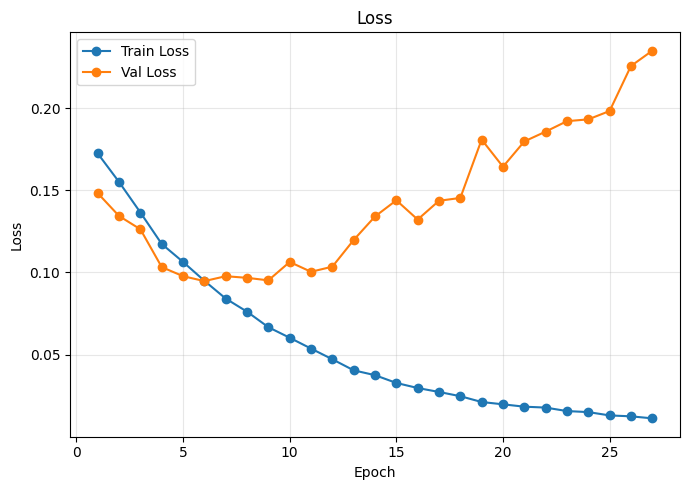

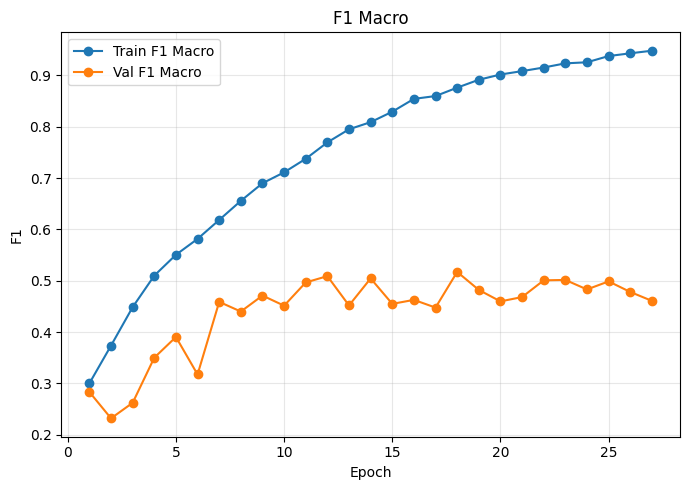

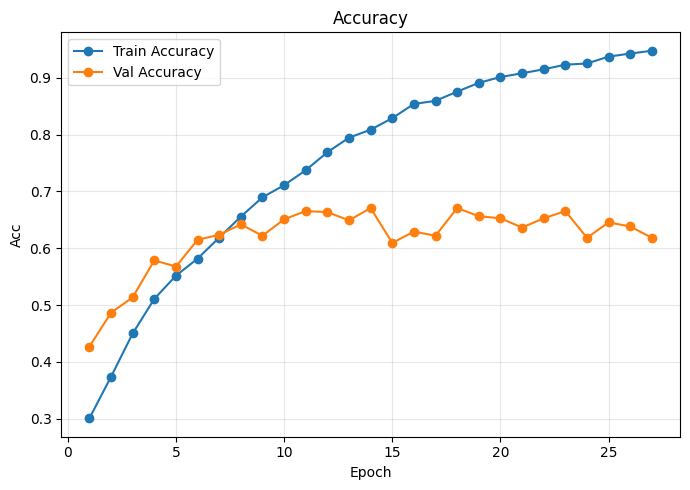

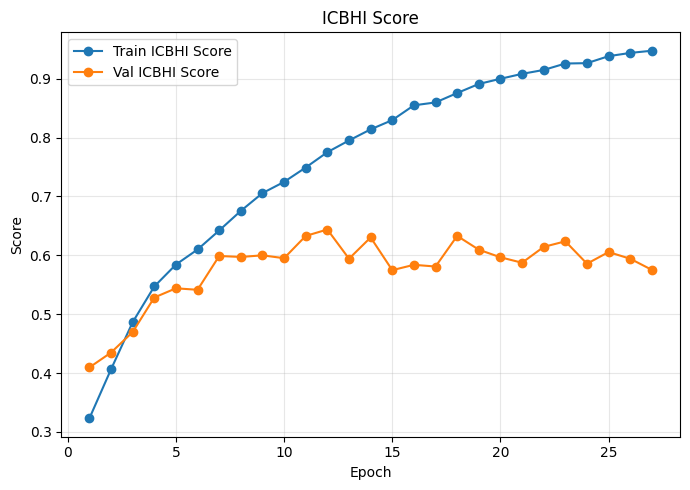

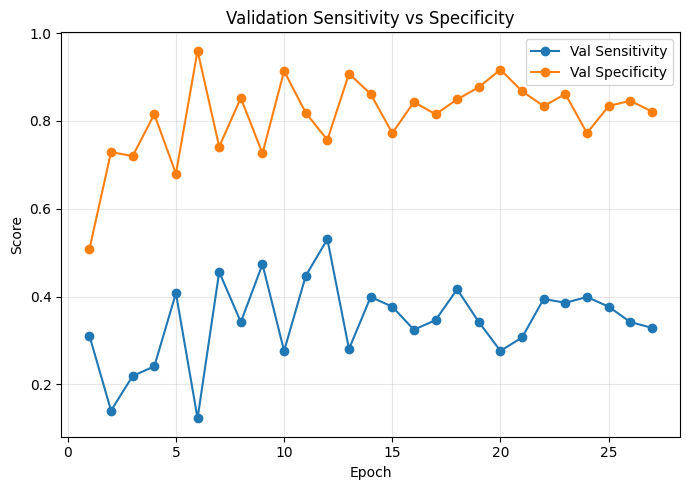


  EVALUASI 4 KELAS | ConvNeXt-Tiny | TEST
  ICBHI Sensitivity (Se) : 0.3804
  ICBHI Specificity (Sp) : 0.5498
  ICBHI Score            : 0.4651
  Harmonic Score         : 0.4497
  Accuracy               : 0.4756
  Precision Macro        : 0.3849
  Recall Macro           : 0.3657
  F1 Macro               : 0.3538
  F1 Weighted            : 0.4813
  AUC OVR Macro          : 0.7017

Classification Report:
              precision    recall  f1-score   support

      normal     0.6791    0.5498    0.6076      1628
     crackle     0.3038    0.5806    0.3989       620
      wheeze     0.4250    0.2121    0.2829       481
        both     0.1316    0.1205    0.1258       166

    accuracy                         0.4756      2895
   macro avg     0.3849    0.3657    0.3538      2895
weighted avg     0.5251    0.4756    0.4813      2895



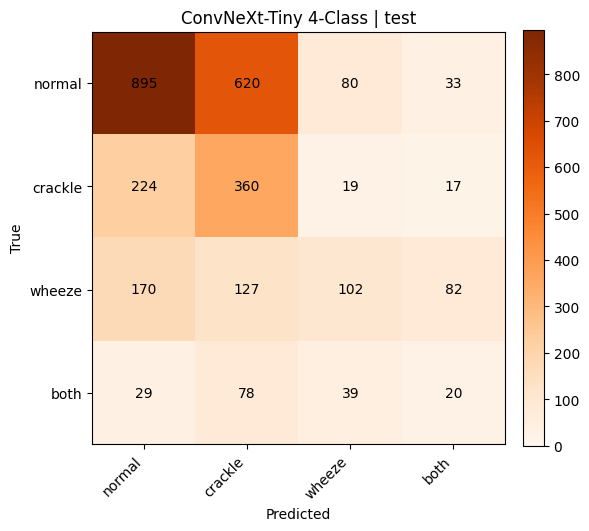

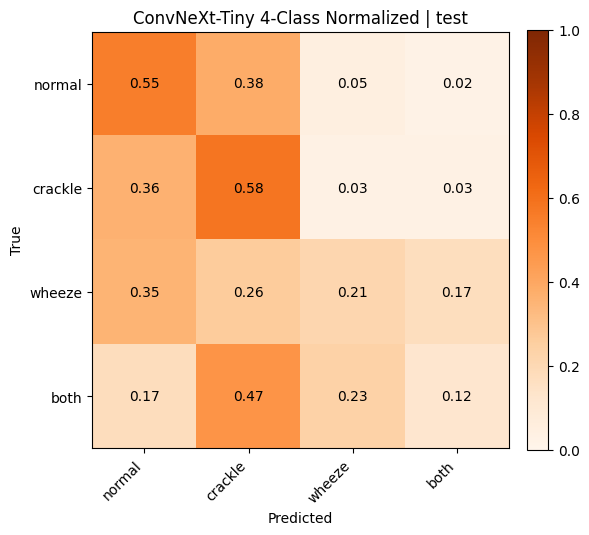


Threshold terbaik dari validation:
threshold    0.5100
Se           0.7719
Sp           0.7323
Score        0.7521
Harmonic     0.7516
Acc          0.7486

  EVALUASI BINARY | ConvNeXt-Tiny | TEST | best_se | t=0.51
  Sensitivity (Se)   : 0.7096
  Specificity (Sp)   : 0.5055
  Average Score      : 0.6075
  Harmonic Score     : 0.5904
  Accuracy           : 0.5948
  F1 Macro Binary    : 0.5945
  AUC Binary         : 0.6634

Classification Report (binary):
              precision    recall  f1-score   support

      normal     0.6910    0.5055    0.5839      1628
    abnormal     0.5276    0.7096    0.6052      1267

    accuracy                         0.5948      2895
   macro avg     0.6093    0.6075    0.5945      2895
weighted avg     0.6195    0.5948    0.5932      2895



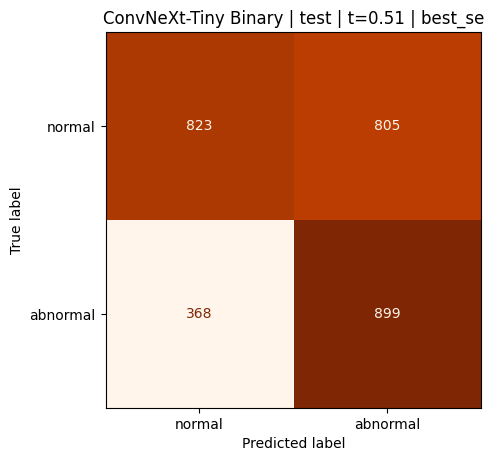

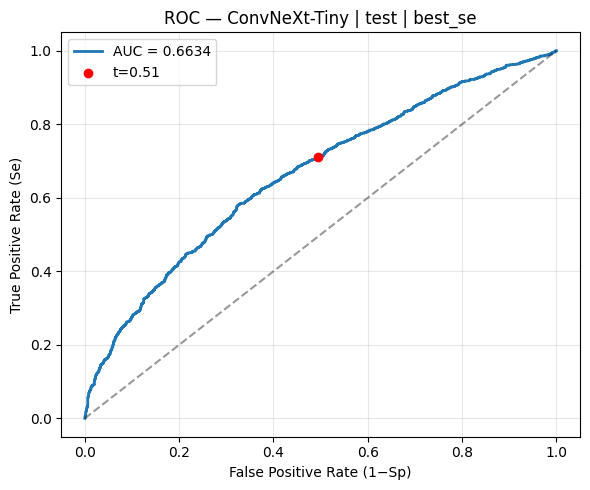


  RINGKASAN AKHIR — CONVNEXT-TINY | BEST_SE
  Threshold          : 0.51
  Binary Se / Sp / AS: 0.7096 / 0.5055 / 0.6075
  Binary Harmonic    : 0.5904
  Binary AUC         : 0.6634
  4-Class AS         : 0.4651
  4-Class AUC OVR    : 0.7017
  Result dir         : results_convnexttiny_4class/convnexttiny_4class_60_40_focal_partial_v5/eval_best_se_from_val/

  Alias siap untuk cell perbandingan:
    CONVNEXT_TEST_SE             = 0.7096
    CONVNEXT_TEST_SP             = 0.5055
    CONVNEXT_TEST_AVGSCORE       = 0.6075
    CONVNEXT_TEST_HARMONIC       = 0.5904
    CONVNEXT_TEST_AUC            = 0.6634
    CONVNEXT_TEST_THRESHOLD      = 0.51


In [ ]:
# =============================================================================
# CELL 36A — EVALUASI CONVNEXT-TINY | BEST_SE + THRESHOLD DARI VALIDATION
# =============================================================================

required_vars = [
    "model_convnext_4class",
    "val_loader_cn_4class",
    "test_loader_cn_4class",
    "DEVICE",
    "CLASS_NAMES_4CLASS",
    "MODEL_TAG_CONVNEXT_4CLASS",
    "CONVNEXT_HISTORY_PATH",
    "CONVNEXT_BEST_SE_MODEL_PATH",
    "SPLIT_SUFFIX",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"Variabel berikut belum ada. Jalankan Cell 34 dulu: {missing}")

RESULT_DIR_CN_BEST = os.path.join(
    "results_convnexttiny_4class",
    MODEL_TAG_CONVNEXT_4CLASS,
    "eval_best_se_from_val",
)
os.makedirs(RESULT_DIR_CN_BEST, exist_ok=True)

THRESHOLD_RANGE_CN = np.arange(0.10, 0.71, 0.01)

print("=" * 72)
print(f"  EVALUASI CONVNEXT-TINY | BEST_SE | {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)
print("  Threshold dipilih dari VALIDATION lalu diterapkan ke TEST")

_ = load_checkpoint_for_eval_generic(
    model_convnext_4class,
    CONVNEXT_BEST_SE_MODEL_PATH,
    DEVICE,
    label="best_se",
)

print("\n  Grafik training history...")
plot_training_history_eval(
    CONVNEXT_HISTORY_PATH,
    RESULT_DIR_CN_BEST,
    MODEL_TAG_CONVNEXT_4CLASS,
)

# Collect validation + test
y_true_4_val_cn, y_pred_4_val_cn, y_prob_4_val_cn, all_meta_val_cn = collect_outputs_generic(
    model_convnext_4class, val_loader_cn_4class, DEVICE
)
y_true_4_cn, y_pred_4_cn, y_prob_4_cn, all_meta_cn = collect_outputs_generic(
    model_convnext_4class, test_loader_cn_4class, DEVICE
)

# 4-class test
res_4_cn = evaluate_4class_generic(
    y_true_4_cn,
    y_pred_4_cn,
    y_prob_4_cn,
    all_meta_cn,
    split_name="test",
    class_names=CLASS_NAMES_4CLASS,
    result_dir=RESULT_DIR_CN_BEST,
    model_tag=MODEL_TAG_CONVNEXT_4CLASS,
    model_display_name="ConvNeXt-Tiny",
    cm_cmap="Oranges",
)

# choose threshold from validation
scan_val_cn, best_row_cn = choose_threshold_from_validation(
    y_true_4_val_cn,
    y_prob_4_val_cn,
    THRESHOLD_RANGE_CN,
)
scan_val_cn.to_csv(
    os.path.join(
        RESULT_DIR_CN_BEST,
        f"threshold_scan_val_{MODEL_TAG_CONVNEXT_4CLASS}_best_se.csv"
    ),
    index=False
)

print("\nThreshold terbaik dari validation:")
print(best_row_cn.to_string())

# apply to test
res_bin_cn = apply_binary_threshold_eval(
    y_true_4_cn,
    y_prob_4_cn,
    threshold=float(best_row_cn["threshold"]),
    split_name="test",
    result_dir=RESULT_DIR_CN_BEST,
    model_tag=MODEL_TAG_CONVNEXT_4CLASS,
    model_display_name="ConvNeXt-Tiny",
    mode_name="best_se",
    cm_cmap="Oranges",
)

print(f"\n{'='*72}")
print("  RINGKASAN AKHIR — CONVNEXT-TINY | BEST_SE")
print(f"{'='*72}")
print(f"  Threshold          : {res_bin_cn['best_threshold']:.2f}")
print(f"  Binary Se / Sp / AS: {res_bin_cn['best_se']:.4f} / {res_bin_cn['best_sp']:.4f} / {res_bin_cn['best_score']:.4f}")
print(f"  Binary Harmonic    : {res_bin_cn['best_harmonic']:.4f}")
print(f"  Binary AUC         : {res_bin_cn['auc_binary']:.4f}" if not np.isnan(res_bin_cn['auc_binary']) else "  Binary AUC         : nan")
print(f"  4-Class AS         : {res_4_cn['icbhi_score']:.4f}")
print(f"  4-Class AUC OVR    : {res_4_cn['auc_ovr_macro']:.4f}" if not np.isnan(res_4_cn['auc_ovr_macro']) else "  4-Class AUC OVR    : nan")
print(f"  Result dir         : {RESULT_DIR_CN_BEST}/")

# Alias untuk perbandingan utama
CONVNEXT_TEST_SE        = res_bin_cn["best_se"]
CONVNEXT_TEST_SP        = res_bin_cn["best_sp"]
CONVNEXT_TEST_AVGSCORE  = res_bin_cn["best_score"]
CONVNEXT_TEST_HARMONIC  = res_bin_cn["best_harmonic"]
CONVNEXT_TEST_AUC       = res_bin_cn["auc_binary"]
CONVNEXT_TEST_THRESHOLD = res_bin_cn["best_threshold"]

CONVNEXT_TEST_RECALL_NORMAL  = res_4_cn["recall_normal"]
CONVNEXT_TEST_RECALL_CRACKLE = res_4_cn["recall_crackle"]
CONVNEXT_TEST_RECALL_WHEEZE  = res_4_cn["recall_wheeze"]
CONVNEXT_TEST_RECALL_BOTH    = res_4_cn["recall_both"]

CONVNEXT_RESULT_DIR    = RESULT_DIR_CN_BEST
CONVNEXT_SUMMARY_ICBHI = res_4_cn["summary"]

print("\n  Alias siap untuk cell perbandingan:")
print(f"    CONVNEXT_TEST_SE             = {CONVNEXT_TEST_SE:.4f}")
print(f"    CONVNEXT_TEST_SP             = {CONVNEXT_TEST_SP:.4f}")
print(f"    CONVNEXT_TEST_AVGSCORE       = {CONVNEXT_TEST_AVGSCORE:.4f}")
print(f"    CONVNEXT_TEST_HARMONIC       = {CONVNEXT_TEST_HARMONIC:.4f}")
print(f"    CONVNEXT_TEST_AUC            = {CONVNEXT_TEST_AUC:.4f}" if not np.isnan(CONVNEXT_TEST_AUC) else "    CONVNEXT_TEST_AUC            = nan")
print(f"    CONVNEXT_TEST_THRESHOLD      = {CONVNEXT_TEST_THRESHOLD:.2f}")

# **Evaluasi Model ConvNeXt-s**
> Fixed Threshold - 0.50

  EVALUASI CONVNEXT-TINY | BEST_SE | FIXED THRESHOLD 0.50 | 60:40

Checkpoint dimuat (best_se): checkpoints_convnexttiny_4class/convnexttiny_4class_60_40_focal_partial_v5/sensitivity_first/best_se_convnexttiny_4class_60_40_focal_partial_v5.pth
  Epoch      : 12
  Strategy   : best_val_sensitivity_tiebreak_abnmacro_score_sp_harm
  Val Score  : 0.6438124156545209
  Val Se     : 0.5307017543859649
  Val Sp     : 0.7569230769230769

  EVALUASI 4 KELAS | ConvNeXt-Tiny | TEST_BESTSE_T050
  ICBHI Sensitivity (Se) : 0.3804
  ICBHI Specificity (Sp) : 0.5498
  ICBHI Score            : 0.4651
  Harmonic Score         : 0.4497
  Accuracy               : 0.4756
  Precision Macro        : 0.3849
  Recall Macro           : 0.3657
  F1 Macro               : 0.3538
  F1 Weighted            : 0.4813
  AUC OVR Macro          : 0.7017

Classification Report:
              precision    recall  f1-score   support

      normal     0.6791    0.5498    0.6076      1628
     crackle     0.3038    0.5806    0.3

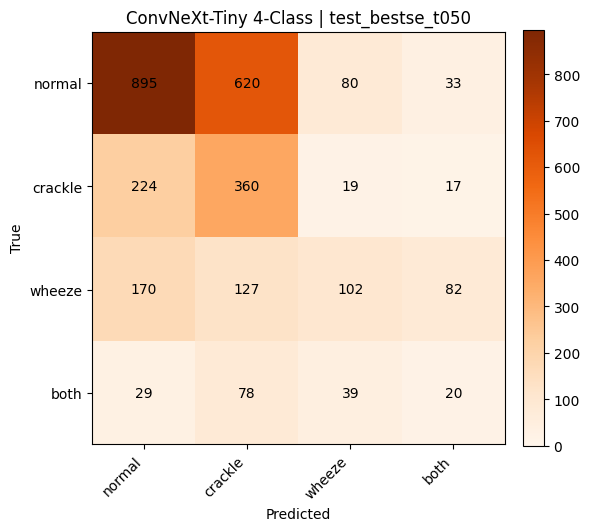

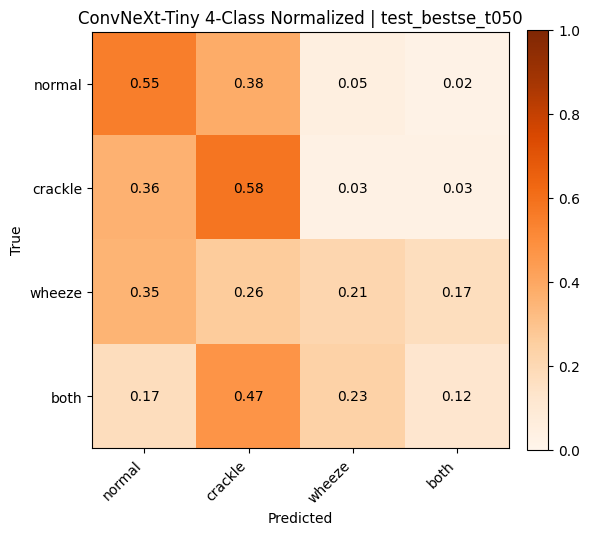


  EVALUASI BINARY | ConvNeXt-Tiny | TEST | best_se_fixed_050 | t=0.50
  Sensitivity (Se)   : 0.7214
  Specificity (Sp)   : 0.4908
  Average Score      : 0.6061
  Harmonic Score     : 0.5842
  Accuracy           : 0.5917
  F1 Macro Binary    : 0.5911
  AUC Binary         : 0.6634

Classification Report (binary):
              precision    recall  f1-score   support

      normal     0.6936    0.4908    0.5748      1628
    abnormal     0.5244    0.7214    0.6073      1267

    accuracy                         0.5917      2895
   macro avg     0.6090    0.6061    0.5911      2895
weighted avg     0.6195    0.5917    0.5890      2895



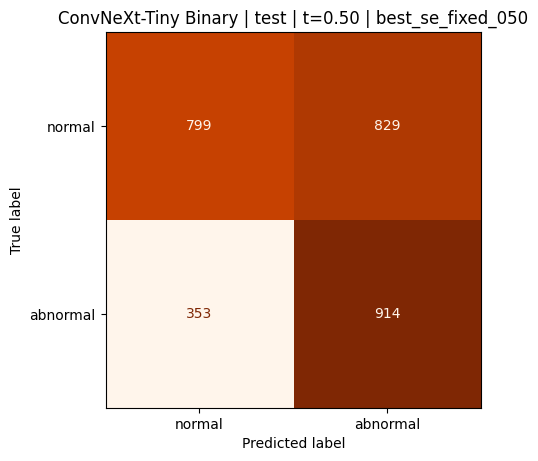

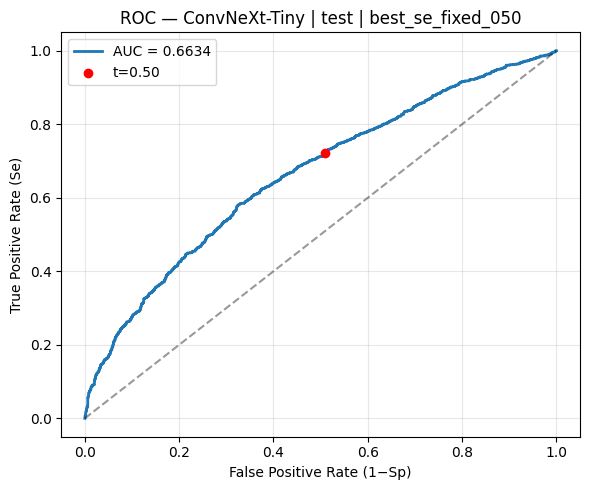


  RINGKASAN AKHIR — CONVNEXT-TINY | BEST_SE | FIXED 0.50
  Threshold          : 0.50
  Binary Se / Sp / AS: 0.7214 / 0.4908 / 0.6061
  Binary Harmonic    : 0.5842
  Binary AUC         : 0.6634
  4-Class AS         : 0.4651
  4-Class AUC OVR    : 0.7017
  Result dir         : results_convnexttiny_4class/convnexttiny_4class_60_40_focal_partial_v5/eval_best_se_threshold_050/

  Alias siap untuk cell perbandingan:
    CONVNEXT_BESTSE_T50_SE             = 0.7214
    CONVNEXT_BESTSE_T50_SP             = 0.4908
    CONVNEXT_BESTSE_T50_SCORE          = 0.6061
    CONVNEXT_BESTSE_T50_HARMONIC       = 0.5842
    CONVNEXT_BESTSE_T50_AUC            = 0.6634


In [ ]:
# =============================================================================
# CELL 36B — EVALUASI CONVNEXT-TINY | BEST_SE + FIXED THRESHOLD 0.50
# =============================================================================

required_vars = [
    "model_convnext_4class",
    "test_loader_cn_4class",
    "DEVICE",
    "CLASS_NAMES_4CLASS",
    "MODEL_TAG_CONVNEXT_4CLASS",
    "CONVNEXT_BEST_SE_MODEL_PATH",
    "SPLIT_SUFFIX",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(f"Variabel berikut belum ada. Jalankan Cell 34 dulu: {missing}")

FIXED_THRESHOLD_CN = 0.50
RESULT_DIR_CN_T50 = os.path.join(
    "results_convnexttiny_4class",
    MODEL_TAG_CONVNEXT_4CLASS,
    "eval_best_se_threshold_050",
)
os.makedirs(RESULT_DIR_CN_T50, exist_ok=True)

print("=" * 72)
print(f"  EVALUASI CONVNEXT-TINY | BEST_SE | FIXED THRESHOLD {FIXED_THRESHOLD_CN:.2f} | {SPLIT_SUFFIX.replace('_', ':')}")
print("=" * 72)

_ = load_checkpoint_for_eval_generic(
    model_convnext_4class,
    CONVNEXT_BEST_SE_MODEL_PATH,
    DEVICE,
    label="best_se",
)

# Collect test
y_true_4_cn_t50, y_pred_4_cn_t50, y_prob_4_cn_t50, all_meta_cn_t50 = collect_outputs_generic(
    model_convnext_4class, test_loader_cn_4class, DEVICE
)

# 4-class test
res_4_cn_t50 = evaluate_4class_generic(
    y_true_4_cn_t50,
    y_pred_4_cn_t50,
    y_prob_4_cn_t50,
    all_meta_cn_t50,
    split_name="test_bestse_t050",
    class_names=CLASS_NAMES_4CLASS,
    result_dir=RESULT_DIR_CN_T50,
    model_tag=MODEL_TAG_CONVNEXT_4CLASS,
    model_display_name="ConvNeXt-Tiny",
    cm_cmap="Oranges",
)

# fixed threshold on test
res_bin_cn_t50 = apply_binary_threshold_eval(
    y_true_4_cn_t50,
    y_prob_4_cn_t50,
    threshold=FIXED_THRESHOLD_CN,
    split_name="test",
    result_dir=RESULT_DIR_CN_T50,
    model_tag=MODEL_TAG_CONVNEXT_4CLASS,
    model_display_name="ConvNeXt-Tiny",
    mode_name="best_se_fixed_050",
    cm_cmap="Oranges",
)

print(f"\n{'='*72}")
print("  RINGKASAN AKHIR — CONVNEXT-TINY | BEST_SE | FIXED 0.50")
print(f"{'='*72}")
print(f"  Threshold          : {FIXED_THRESHOLD_CN:.2f}")
print(f"  Binary Se / Sp / AS: {res_bin_cn_t50['best_se']:.4f} / {res_bin_cn_t50['best_sp']:.4f} / {res_bin_cn_t50['best_score']:.4f}")
print(f"  Binary Harmonic    : {res_bin_cn_t50['best_harmonic']:.4f}")
print(f"  Binary AUC         : {res_bin_cn_t50['auc_binary']:.4f}" if not np.isnan(res_bin_cn_t50['auc_binary']) else "  Binary AUC         : nan")
print(f"  4-Class AS         : {res_4_cn_t50['icbhi_score']:.4f}")
print(f"  4-Class AUC OVR    : {res_4_cn_t50['auc_ovr_macro']:.4f}" if not np.isnan(res_4_cn_t50['auc_ovr_macro']) else "  4-Class AUC OVR    : nan")
print(f"  Result dir         : {RESULT_DIR_CN_T50}/")

# Alias khusus fixed 0.50
CONVNEXT_BESTSE_T50_SE       = res_bin_cn_t50["best_se"]
CONVNEXT_BESTSE_T50_SP       = res_bin_cn_t50["best_sp"]
CONVNEXT_BESTSE_T50_SCORE    = res_bin_cn_t50["best_score"]
CONVNEXT_BESTSE_T50_HARMONIC = res_bin_cn_t50["best_harmonic"]
CONVNEXT_BESTSE_T50_AUC      = res_bin_cn_t50["auc_binary"]

CONVNEXT_BESTSE_T50_RECALL_NORMAL  = res_4_cn_t50["recall_normal"]
CONVNEXT_BESTSE_T50_RECALL_CRACKLE = res_4_cn_t50["recall_crackle"]
CONVNEXT_BESTSE_T50_RECALL_WHEEZE  = res_4_cn_t50["recall_wheeze"]
CONVNEXT_BESTSE_T50_RECALL_BOTH    = res_4_cn_t50["recall_both"]

print("\n  Alias siap untuk cell perbandingan:")
print(f"    CONVNEXT_BESTSE_T50_SE             = {CONVNEXT_BESTSE_T50_SE:.4f}")
print(f"    CONVNEXT_BESTSE_T50_SP             = {CONVNEXT_BESTSE_T50_SP:.4f}")
print(f"    CONVNEXT_BESTSE_T50_SCORE          = {CONVNEXT_BESTSE_T50_SCORE:.4f}")
print(f"    CONVNEXT_BESTSE_T50_HARMONIC       = {CONVNEXT_BESTSE_T50_HARMONIC:.4f}")
print(f"    CONVNEXT_BESTSE_T50_AUC            = {CONVNEXT_BESTSE_T50_AUC:.4f}" if not np.isnan(CONVNEXT_BESTSE_T50_AUC) else "    CONVNEXT_BESTSE_T50_AUC            = nan")